In [145]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr

from jiflr import ROOT
from jiflr.data import select_sensors, unstack_sensor_idx
from jiflr.utils import lapse_rate_ufunc, butterworth_filter, get_sunrise_sunset

# Configure Butterworth filter for plotting
# For 5-minute data: fs = 1/300 Hz (sampling frequency)
# upper = 1/6 means cutoff at 6 samples = 30 minutes
FILTER_ORDER = 4
FILTER_LOWER = None  # Low-pass filter only
# FILTER_FS = 1 / 300  # Sampling frequency for 5-minute data (1 sample per 300 seconds)
HOUR_CUTOFF = 6
FILTER_UPPER = 1 / (HOUR_CUTOFF * 60 * 60)  # 2 hr cutoff
# For 15-min data: fs = 1/(300 * 3) Hz
FILTER_FS = 1 / (300 * 3)

In [146]:
p = Path(ROOT, "data/2025/timelapse_melt.csv")
df = pd.read_csv(p)
df["datetime"] = pd.to_datetime(df["datetime"])

site_ids = df["site_id"].unique()
concat = []
for site_id, grp in df.groupby("site_id"):
    grp["height_cm"] = grp["height_cm"] - grp["height_cm"].iloc[0]
    grp["diff_cm"] = grp["height_cm"].iloc[1:] - grp["height_cm"].shift(1)
    concat.append(grp)

df = pd.concat(concat)
df

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_40580/4057034877.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["datetime"])


,datetime,site_id,height_cm,notes,diff_cm
123,2025-06-19 21:00:00,divide,0,0 = top edge of the topmost tape band. Because...,NaN
124,2025-06-20 21:00:00,divide,3,NaN,3.0
125,2025-06-21 21:00:00,divide,10,NaN,7.0
126,2025-06-22 21:00:00,divide,16,NaN,6.0
127,2025-06-23 21:00:00,divide,20,NaN,4.0
...,...,...,...,...,...
118,2025-07-22 21:00:00,windward2,94,NaN,4.0
119,2025-07-23 21:00:00,windward2,96,NaN,2.0
120,2025-07-24 21:00:00,windward2,97,NaN,1.0
121,2025-07-25 21:00:00,windward2,99,NaN,2.0


In [147]:
# Period definitions – change dates here to update all plots
period_slices = {
    "standard": slice("2025-07-01", "2025-07-08"),
    "inverted": slice("2025-07-15", "2025-07-21"),
}
period_labels = {
    "standard": "Standard period (Jul 01 – Jul 08)",
    "inverted": "Inverted period (Jul 15 – Jul 21)",
}
period_alphas = {"standard": 0.85, "inverted": 0.35}

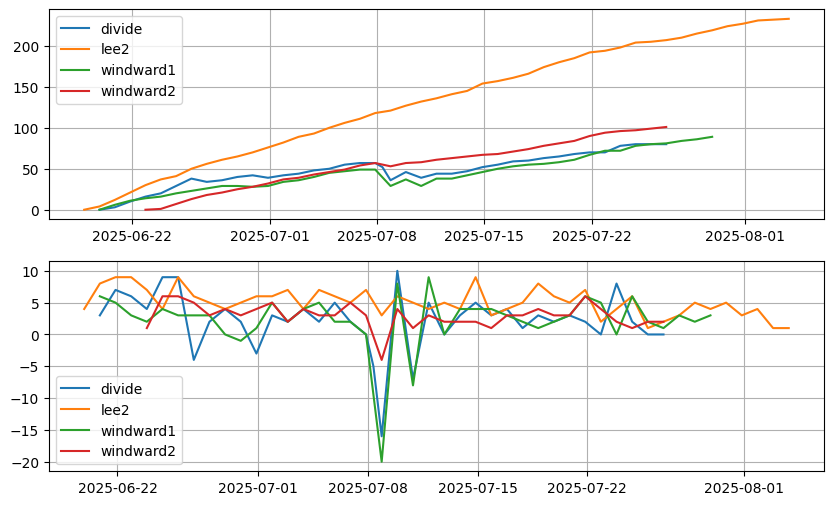

In [148]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
ax = axes[0]
for site_id, grp in df.groupby("site_id"):
    ax.plot(grp.datetime, grp.height_cm, label=site_id)
ax.legend()
ax.grid()

ax = axes[1]
for site_id, grp in df.groupby("site_id"):
    ax.plot(grp.datetime, grp.diff_cm, label=site_id)
ax.legend()
ax.grid()

In [149]:
df["diff_cm"] = np.maximum(df["diff_cm"], 0)

concat = []
for site_id, grp in df.groupby("site_id"):
    grp["melt_cm"] = grp["diff_cm"].cumsum()
    baseline = grp.loc[grp["datetime"].dt.normalize() == pd.Timestamp("2025-06-23"), "melt_cm"].iloc[0]
    grp["melt_cm"] -= baseline
    concat.append(grp)
df = pd.concat(concat)

df

,datetime,site_id,height_cm,notes,diff_cm,melt_cm
123,2025-06-19 21:00:00,divide,0,0 = top edge of the topmost tape band. Because...,NaN,NaN
124,2025-06-20 21:00:00,divide,3,NaN,3.0,-17.0
125,2025-06-21 21:00:00,divide,10,NaN,7.0,-10.0
126,2025-06-22 21:00:00,divide,16,NaN,6.0,-4.0
127,2025-06-23 21:00:00,divide,20,NaN,4.0,0.0
...,...,...,...,...,...,...
118,2025-07-22 21:00:00,windward2,94,NaN,4.0,97.0
119,2025-07-23 21:00:00,windward2,96,NaN,2.0,99.0
120,2025-07-24 21:00:00,windward2,97,NaN,1.0,100.0
121,2025-07-25 21:00:00,windward2,99,NaN,2.0,102.0


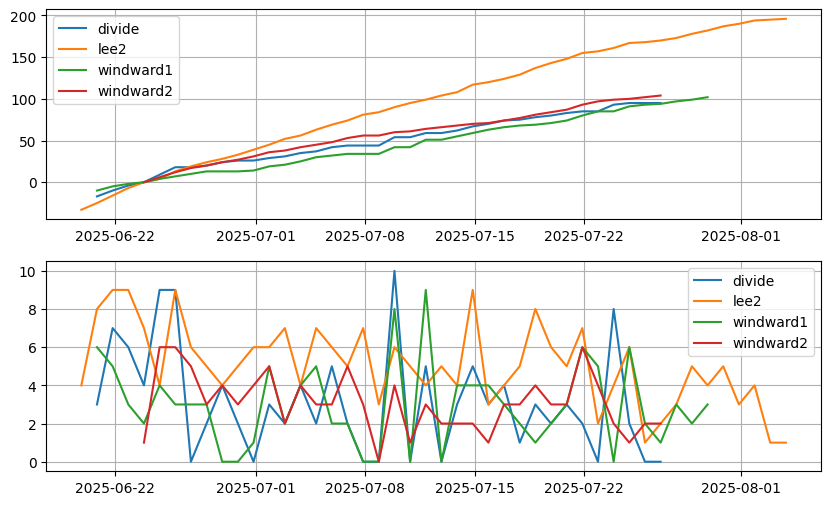

In [150]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
ax = axes[0]
for site_id, grp in df.groupby("site_id"):
    ax.plot(grp.datetime, grp.melt_cm, label=site_id)
ax.legend()
ax.grid()

ax = axes[1]
for site_id, grp in df.groupby("site_id"):
    ax.plot(grp.datetime, grp.diff_cm, label=site_id)
ax.legend()
ax.grid()

In [151]:
stab_start = pd.Timestamp(period_slices["standard"].start)
stab_end = pd.Timestamp(period_slices["standard"].stop)
inv_start = pd.Timestamp(period_slices["inverted"].start)
inv_end = pd.Timestamp(period_slices["inverted"].stop)

df_inv = df.loc[(df.datetime > inv_start) & (df.datetime < inv_end)]

df_stab = df.loc[(df.datetime > stab_start) & (df.datetime < stab_end)]
df_stab = df_stab[df_stab.diff_cm > 0]  # drop snow days

print(df_inv.groupby("site_id")["diff_cm"].mean())
print(df_stab.groupby("site_id")["diff_cm"].mean())

site_id
divide       2.666667
lee2         5.166667
windward1    2.500000
windward2    2.833333
Name: diff_cm, dtype: float64
site_id
divide       3.000000
lee2         6.000000
windward1    3.333333
windward2    3.571429
Name: diff_cm, dtype: float64


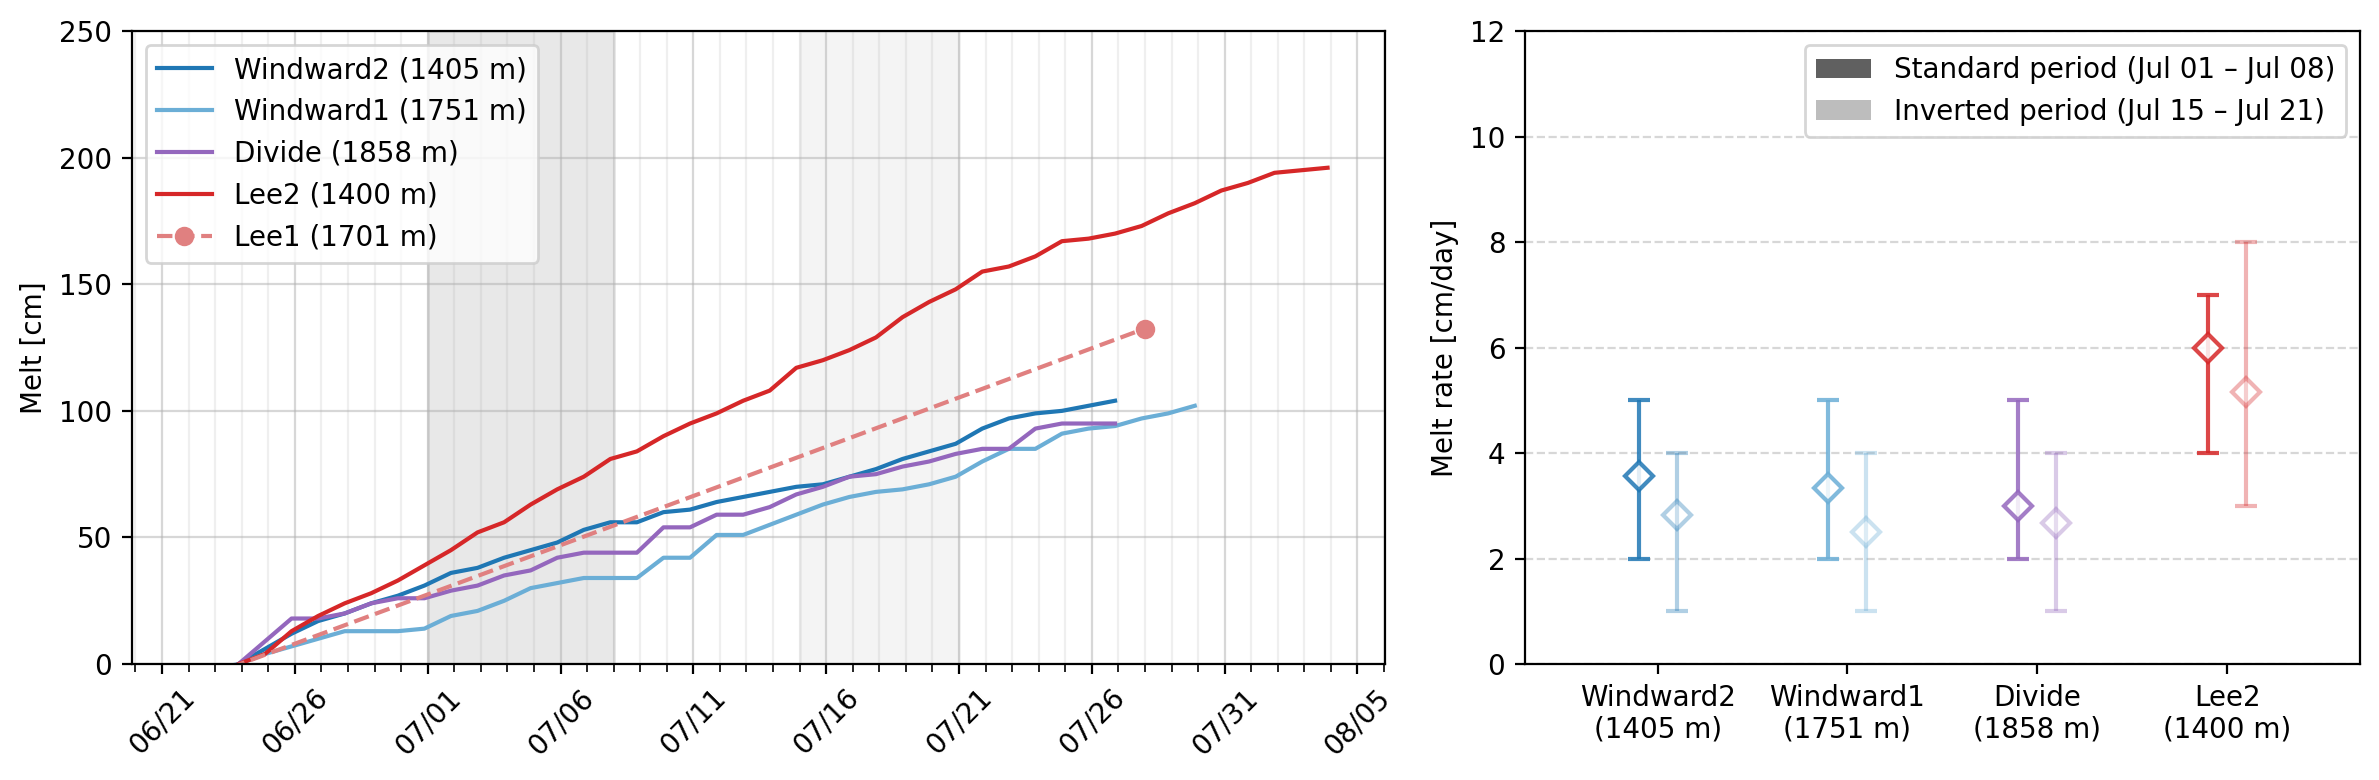

In [152]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import numpy as np

fig, (ax_line, ax_strip) = plt.subplots(
    1, 2, figsize=(12, 4), dpi=200, width_ratios=[1.5, 1]
)

site_ids = ["windward2", "windward1", "divide", "lee2"]
start_date = pd.Timestamp("2025-06-22")

site_colors = {
    "windward2": "#1f77b4",
    "windward1": "#6baed6",
    "divide": "#9467bd",
    "lee2": "#d62728",
}

site_labels = {
    "windward2": "Windward2 (1405 m)",
    "windward1": "Windward1 (1751 m)",
    "divide": "Divide (1858 m)",
    "lee2": "Lee2 (1400 m)",
}

site_labels_strip = {
    "windward2": "Windward2\n(1405 m)",
    "windward1": "Windward1\n(1751 m)",
    "divide": "Divide\n(1858 m)",
    "lee2": "Lee2\n(1400 m)",
}

# ── Line plot ────────────────────────────────────────────────────────────────
for site_id in site_ids:
    grp = df[(df["site_id"] == site_id) & (df.datetime >= start_date)]
    ax_line.plot(
        grp.datetime,
        grp.melt_cm,
        color=site_colors[site_id],
        label=site_labels[site_id],
    )

offset = 7.5
ax_line.plot([start_date, pd.Timestamp("7/28/25")], [0-offset, 140-offset], color="#e08080", marker="o", ls="--", label="Lee1 (1701 m)")

ax_line.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.12)
ax_line.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.06)

ax_line.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax_line.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax_line.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax_line.tick_params(axis="x", which="minor", length=3)
ax_line.tick_params(axis="x", which="major", rotation=45)

ax_line.set_ylim(0, 250)
ax_line.set_ylabel("Melt [cm]")
ax_line.grid(axis="y", linestyle="-", alpha=0.5)
ax_line.grid(axis="x", which="major", linestyle="-", alpha=0.5)
ax_line.grid(axis="x", which="minor", linestyle="-", alpha=0.2)
ax_line.legend(loc="upper left")

# ── Strip plot ────────────────────────────────────────────────────────────────
width = 0.25
group_spacing = 1.0  # wider gap between sites
period_offset = 0.1  # wider separation between standard/inverted within a site

for i, site_id in enumerate(site_ids):
    stab_vals = df_stab.loc[df_stab["site_id"] == site_id, "diff_cm"].dropna().values
    inv_vals = df_inv.loc[df_inv["site_id"] == site_id, "diff_cm"].dropna().values
    color = site_colors[site_id]
    center = i * group_spacing

    for vals, off, alpha in zip(
        [stab_vals, inv_vals], [-period_offset, period_offset], [period_alphas["standard"], period_alphas["inverted"]]
    ):
        if len(vals) > 0:
            mean_val = np.mean(vals)
            err_lo = mean_val - np.min(vals)
            err_hi = np.max(vals) - mean_val
            ax_strip.errorbar(
                center + off, mean_val,
                yerr=[[err_lo], [err_hi]],
                fmt="D",
                color=color,
                alpha=alpha,
                markersize=7,
                markerfacecolor="white",
                markeredgewidth=1.5,
                capsize=4,
                capthick=1.5,
                elinewidth=1.5,
                zorder=4,
            )

ax_strip.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax_strip.set_xticklabels([site_labels_strip[s] for s in site_ids], fontsize=10)
ax_strip.set_xlim(-0.7, (len(site_ids) - 1) * group_spacing + 0.7)
ax_strip.set_ylim(0, 12)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax_strip.legend(handles=legend_patches)
ax_strip.set_ylabel("Melt rate [cm/day]")
ax_strip.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [153]:
# Load intensive site sensor data
ds_intensive = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_intensive.nc")
print(ds_intensive)

<xarray.Dataset> Size: 75MB
Dimensions:            (datetime: 23885, sensor_idx: 56)
Coordinates:
  * datetime           (datetime) datetime64[ns] 191kB 2025-06-17T12:05:00 .....
  * sensor_idx         (sensor_idx) int64 448B 0 1 2 3 4 5 ... 50 51 52 53 54 55
    site_id            (sensor_idx) <U9 2kB ...
    height             (sensor_idx) <U4 896B ...
    shielding          (sensor_idx) <U10 2kB ...
    sensor_type        (sensor_idx) <U4 896B ...
    sensor_generation  (sensor_idx) <U11 2kB ...
    sensor_id          (sensor_idx) <U28 6kB ...
    elevation          (sensor_idx) float64 448B ...
    latitude           (sensor_idx) float64 448B ...
    longitude          (sensor_idx) float64 448B ...
Data variables:
    temp_c             (datetime, sensor_idx) float64 11MB ...
    wind_direction     (datetime, sensor_idx) float64 11MB ...
    pressure           (datetime, sensor_idx) float64 11MB ...
    relative_humidity  (datetime, sensor_idx) float64 11MB ...
    wind_speed_avg  

In [154]:
ds = unstack_sensor_idx(ds_intensive)
ds

<xarray.Dataset> Size: 193MB
Dimensions:            (site_id: 6, height: 4, shielding: 3, sensor_type: 2,
                        datetime: 23885)
Coordinates:
  * site_id            (site_id) object 48B 'A02' 'Divide' ... 'Windward2'
  * height             (height) object 32B '0.5m' '1.5m' '1m' '2m'
  * shielding          (shielding) object 24B 'shielded' 'unshield' 'unshielded'
  * sensor_type        (sensor_type) object 16B 'hobo' 'pace'
  * datetime           (datetime) datetime64[ns] 191kB 2025-06-17T12:05:00 .....
Data variables:
    temp_c             (datetime, site_id, height, shielding, sensor_type) float64 28MB ...
    wind_direction     (datetime, site_id, height, shielding, sensor_type) float64 28MB ...
    pressure           (datetime, site_id, height, shielding, sensor_type) float64 28MB ...
    relative_humidity  (datetime, site_id, height, shielding, sensor_type) float64 28MB ...
    wind_speed_avg     (datetime, site_id, height, shielding, sensor_type) float64 28MB ...
    wind_speed_peak    (datetime, site_id, height, shielding, sensor_type) float64 28MB ...
    intensity_lux      (datetime, site_id, height, shielding, sensor_type) float64 28MB ...
Attributes: (12/25)
    sensor_type:                  pace logger
    serial_number:                EM54054
    site_label:                   Windward-1
    logging_start:                Jun 19, 2025 5:40:41 PM
    logging_stop:                 Aug 4, 2025 12:15:51 PM
    log_interval:                 0 hr, 5 min, 0 sec
    ...                           ...
    sensor_type_info:             pace=unshielded meteorological station, pen...
    data_conflict_resolution:     sensor_type coordinate separates pace vs pe...
    created_by:                   combine_pace_pendant_data.py
    resampling_method:            mean
    time_resolution:              5 minutes
    processed_timestamp:          2026-03-11T09:07:32.951928

In [155]:
ds_filtered = ds.dropna("site_id", how="all")
ds_filtered = xr.apply_ufunc(
    butterworth_filter,
    ds_filtered,
    kwargs=dict(
        fs=FILTER_FS, order=FILTER_ORDER, lower=FILTER_LOWER, upper=FILTER_UPPER
    ),
    input_core_dims=[["datetime"]],
    output_core_dims=[["datetime"]],
    vectorize=True,
)
ds_filtered["datetime"] = ds.datetime

/Users/drotto/src/jiflr/src/jiflr/utils.py:561: UserWarning: All data values are NaN, returning input unchanged
  warnings.warn("All data values are NaN, returning input unchanged")


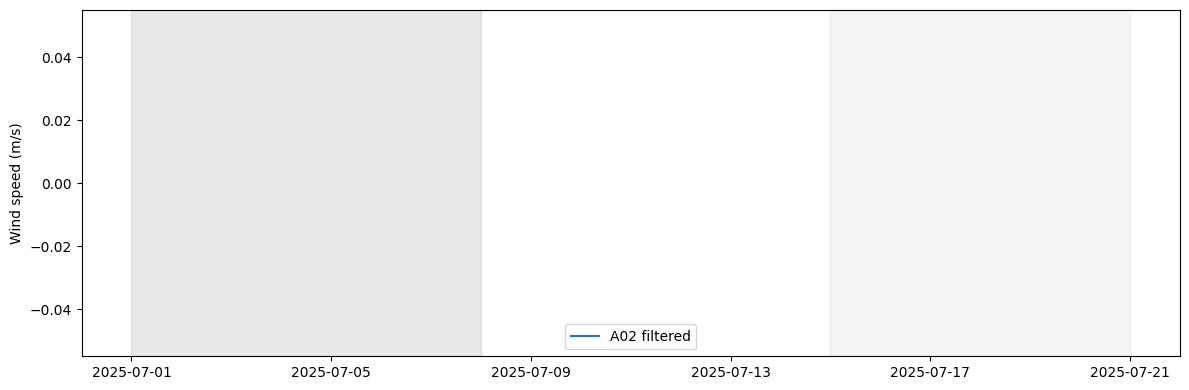

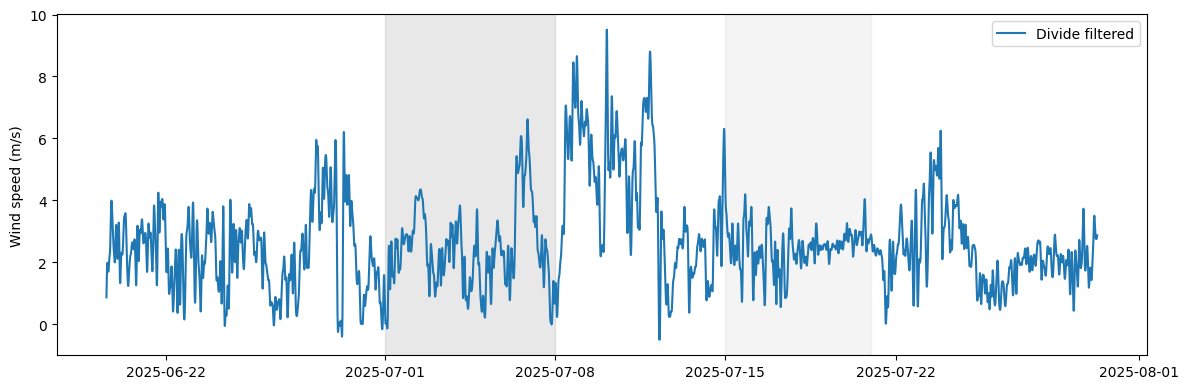

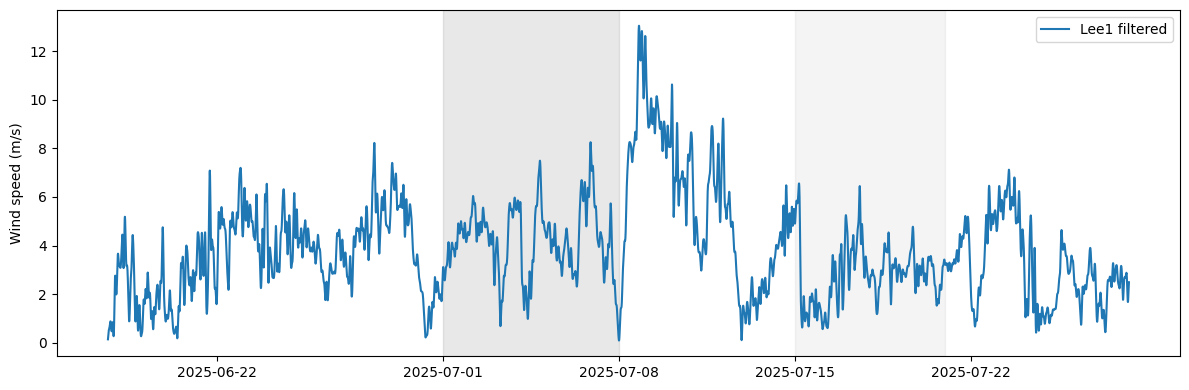

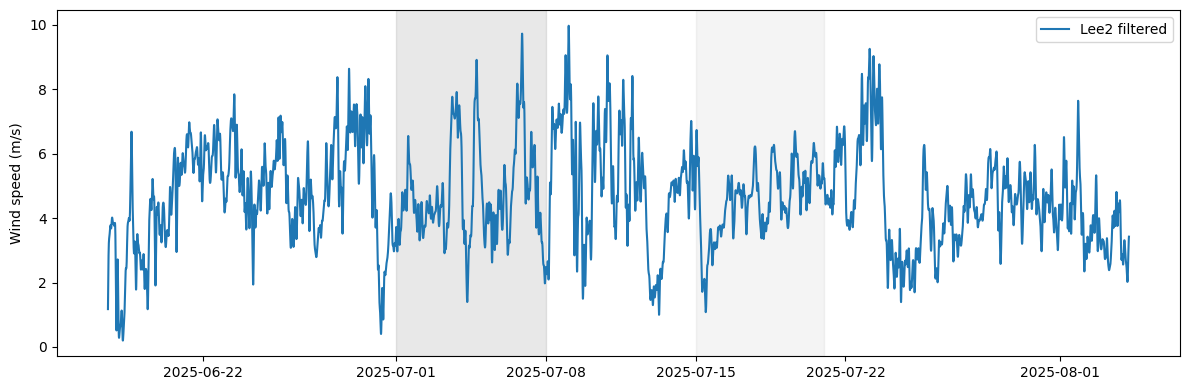

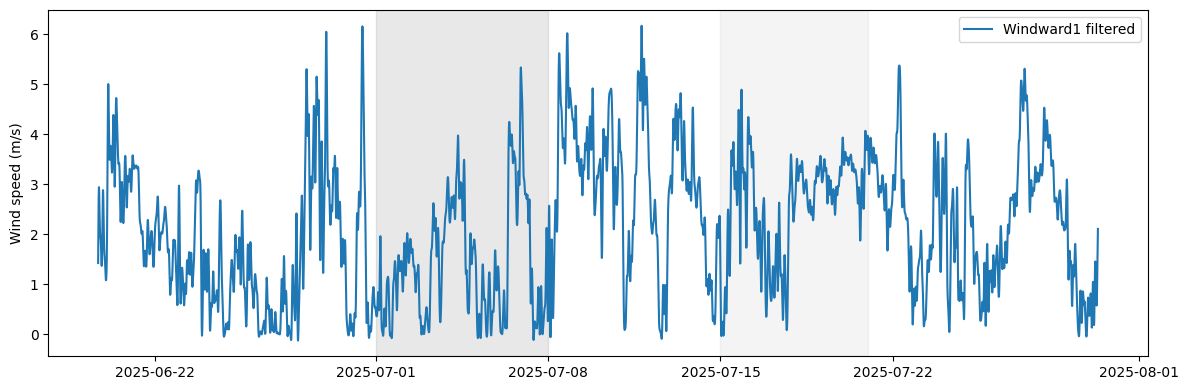

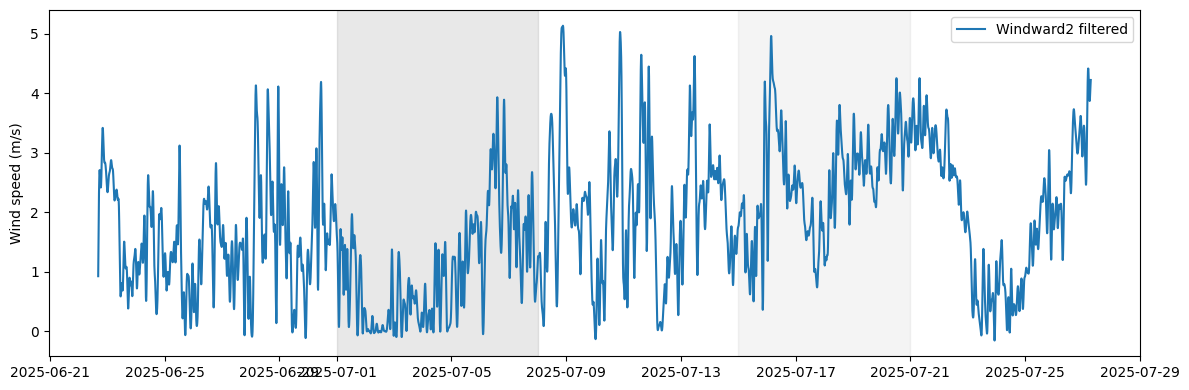

In [156]:
for site_id in ds_filtered.site_id.values:
    fig, ax = plt.subplots(figsize=(12, 4))
    filt = ds_filtered["wind_speed_avg"].sel(
        site_id=site_id, height="2m", shielding="unshielded", sensor_type="pace"
    )

    ax.plot(filt.datetime, filt, label=f"{site_id} filtered")

    ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.12)
    ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.06)
    ax.legend()
    ax.set_ylabel("Wind speed (m/s)")
    plt.tight_layout()

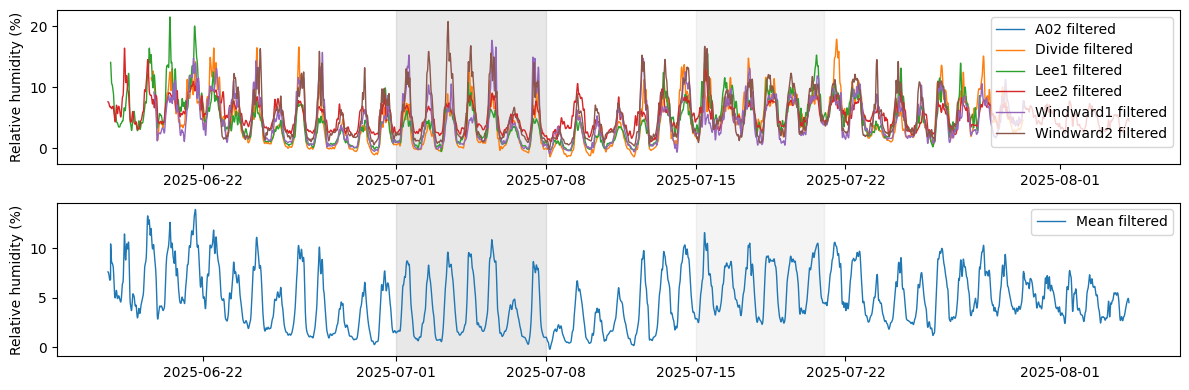

In [157]:
fig, axes = plt.subplots(2,1,figsize=(12, 4))
for site_id in ds_filtered.site_id.values:
    filt = ds_filtered["temp_c"].sel(
        site_id=site_id, height="2m", shielding="unshielded", sensor_type="pace"
    )
    axes[0].plot(filt.datetime, filt, label=f"{site_id} filtered", lw=1)

filt_mean = ds_filtered["temp_c"].sel(
         height="2m", shielding="unshielded", sensor_type="pace"
    ).mean(dim="site_id")
axes[1].plot(filt_mean.datetime, filt_mean, label=f"Mean filtered", lw=1)

for ax in axes:
    ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.12)
    ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.06)
    ax.legend()
    ax.set_ylabel("Relative humidity (%)")
plt.tight_layout()

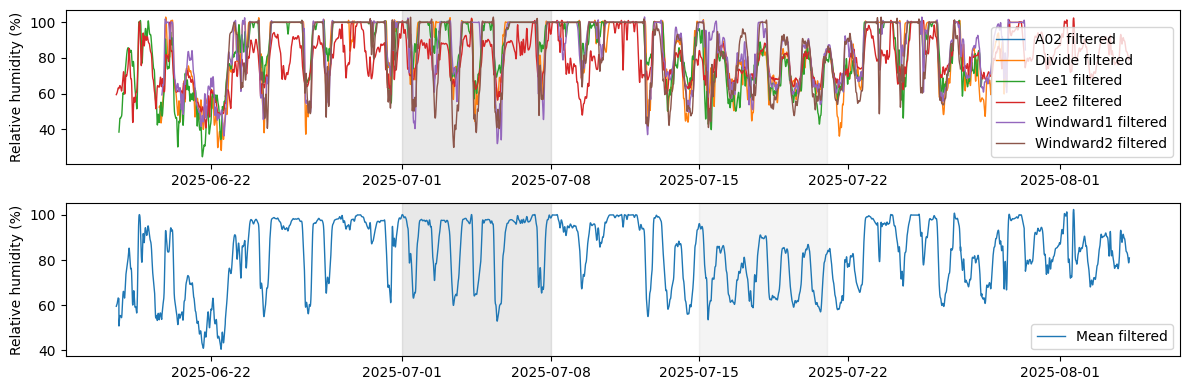

In [158]:
fig, axes = plt.subplots(2,1,figsize=(12, 4))
for site_id in ds_filtered.site_id.values:
    filt = ds_filtered["relative_humidity"].sel(
        site_id=site_id, height="2m", shielding="unshielded", sensor_type="pace"
    )
    axes[0].plot(filt.datetime, filt, label=f"{site_id} filtered", lw=1)

filt_mean = ds_filtered["relative_humidity"].sel(
         height="2m", shielding="unshielded", sensor_type="pace"
    ).mean(dim="site_id")
axes[1].plot(filt_mean.datetime, filt_mean, label=f"Mean filtered", lw=1)

for ax in axes:
    ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.12)
    ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.06)
    ax.legend()
    ax.set_ylabel("Relative humidity (%)")
plt.tight_layout()

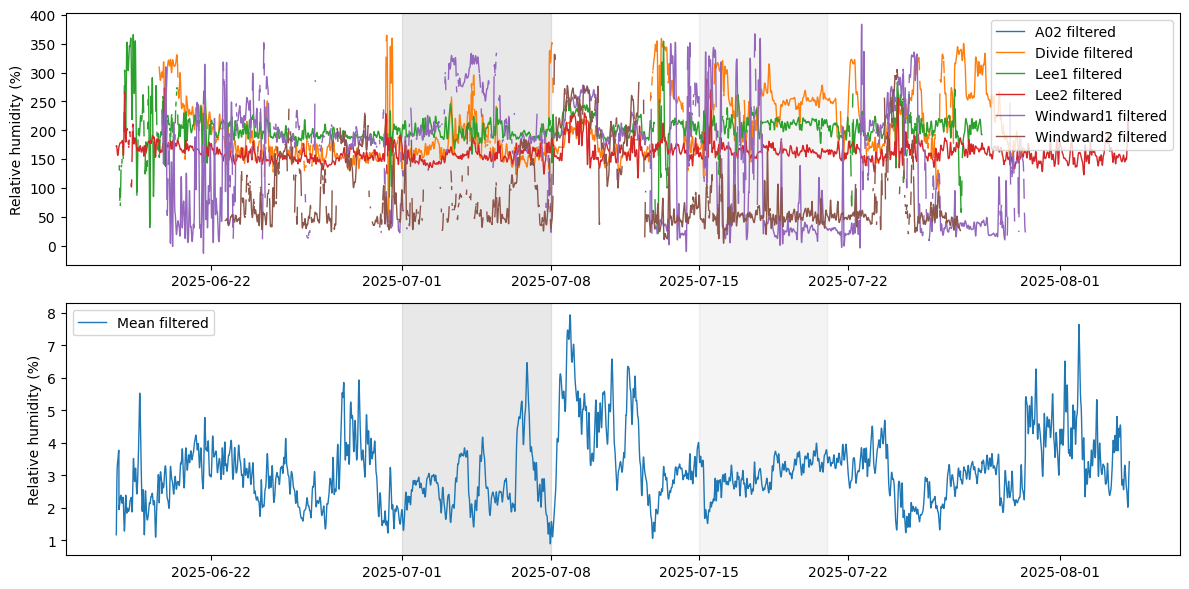

In [159]:
fig, axes = plt.subplots(2,1,figsize=(12, 6))
for site_id in ds_filtered.site_id.values:
    filt = ds_filtered["wind_direction"].sel(
        site_id=site_id, height="2m", shielding="unshielded", sensor_type="pace"
    )
    axes[0].plot(filt.datetime, filt, label=f"{site_id} filtered", lw=1)

filt_mean = ds_filtered["wind_speed_avg"].sel(
         height="2m", shielding="unshielded", sensor_type="pace"
    ).mean(dim="site_id")
axes[1].plot(filt_mean.datetime, filt_mean, label=f"Mean filtered", lw=1)

for ax in axes:
    ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.12)
    ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.06)
    ax.legend()
    ax.set_ylabel("Relative humidity (%)")
plt.tight_layout()

Windward2 stable: 1.1591894364760045
Windward2 inverted: 1.0364976307503897

Windward1 stable: 1.4697718455623692
Windward1 inverted: 1.0590778916688284

Divide stable: 1.773635134139571
Divide inverted: 0.8187288348671543

Lee1 stable: 2.1655518654836654
Lee1 inverted: 1.296778931878785

Lee2 stable: 1.7143024948748662
Lee2 inverted: 1.182800703611081



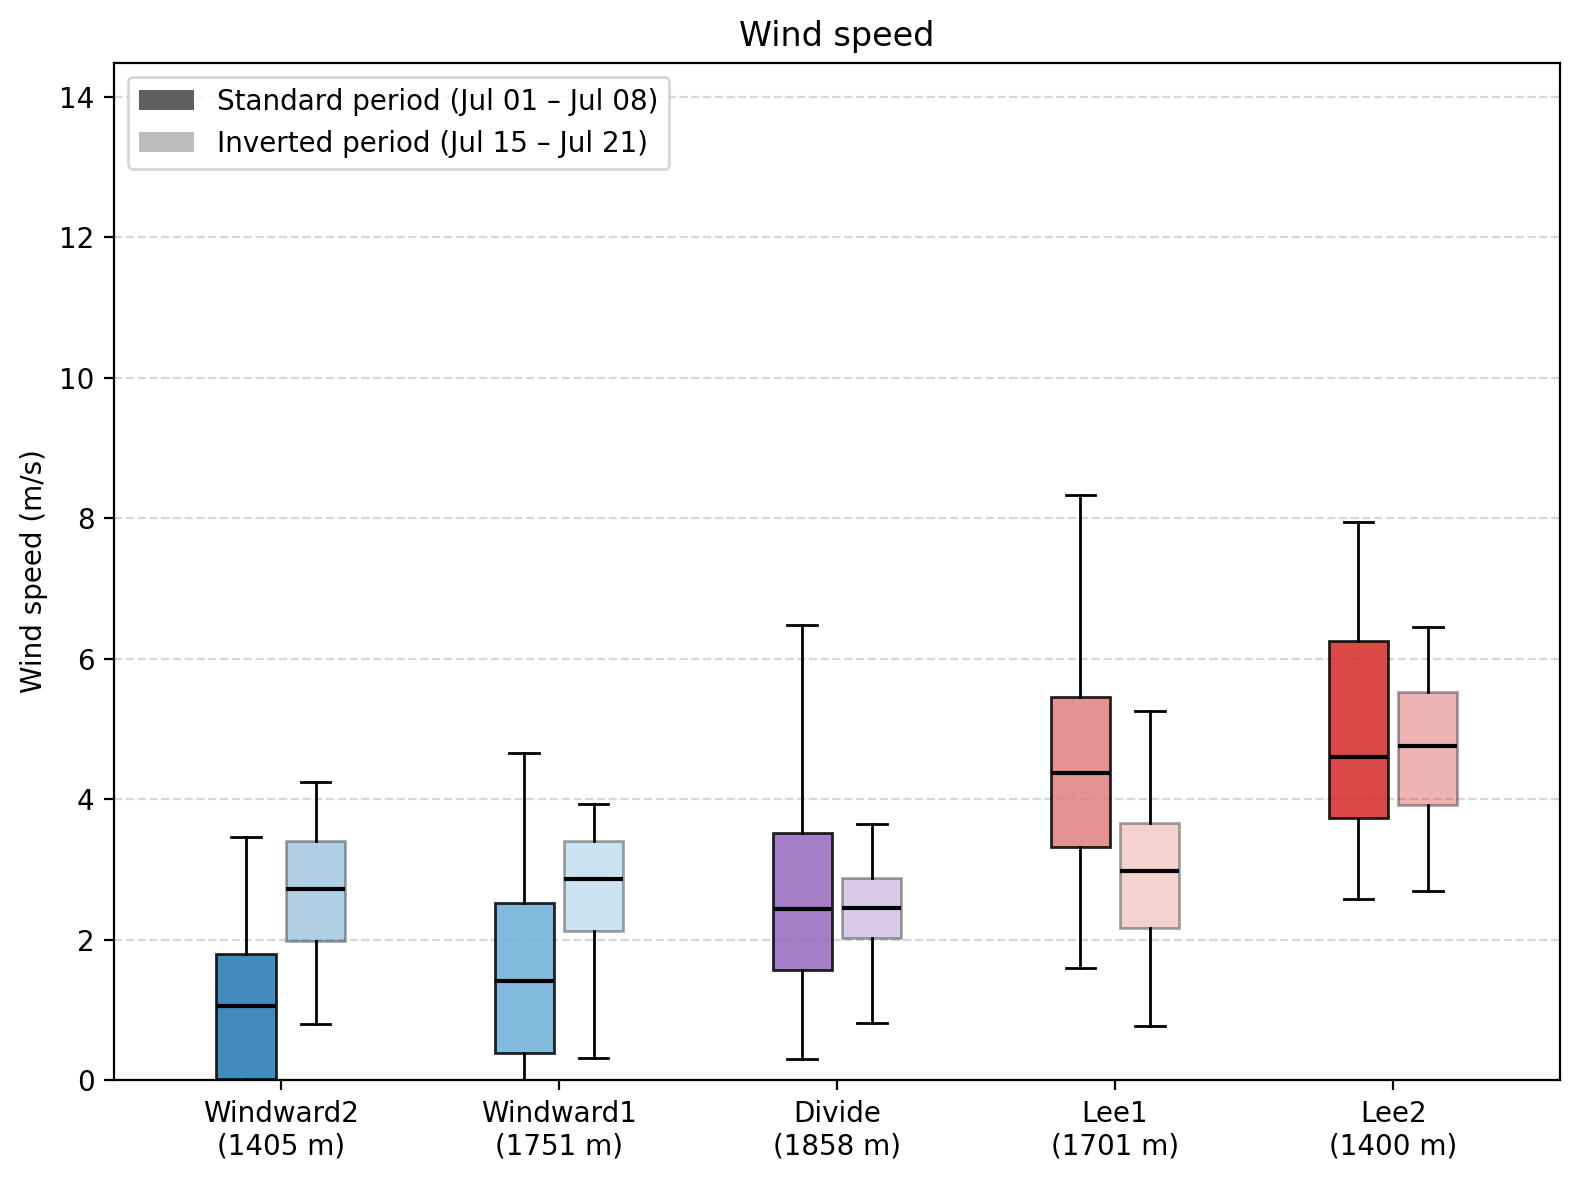

In [160]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide": "#9467bd",
    "Lee2": "#d62728",
    "Lee1": "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide": "Divide\n(1858 m)",
    "Lee2": "Lee2\n(1400 m)",
    "Lee1": "Lee1\n(1701 m)",
}

da_temp = ds["wind_speed_avg"].sel(shielding="unshielded", sensor_type="pace")
da_diff = da_temp.sel(height="2m")

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = da_diff.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals = da_diff.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals = inv_vals[~np.isnan(inv_vals)]
    
    print(f"{site_id} stable: {stab_vals.std()}")
    print(f"{site_id} inverted: {inv_vals.std()}\n")

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(5, 95),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
        )

ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.set_ylim(bottom=0)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax.legend(handles=legend_patches)
ax.set_ylabel("Wind speed (m/s)")
ax.set_title("Wind speed")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()



In [161]:
from scipy.stats import circmean, circstd

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

da_wind_avg  = ds["wind_speed_avg"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_wind_max  = ds["wind_speed_peak"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_temp_2m   = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_temp_05m  = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height="0.5m")
da_wdir      = ds["wind_direction"]

for site_id in site_ids:
    print(f"=== {site_id} ===")

    # Wind speed avg
    print(f"  Wind speed avg (m/s):")
    for period_name, period_slice in period_slices.items():
        vals = da_wind_avg.sel(site_id=site_id, datetime=period_slice).values
        print(f"    {period_name}: mean={np.nanmean(vals):.4f}, std={np.nanstd(vals):.4f}")

    # Wind speed max
    print(f"  Wind speed max (m/s):")
    for period_name, period_slice in period_slices.items():
        vals = da_wind_max.sel(site_id=site_id, datetime=period_slice).values
        print(f"    {period_name}: mean={np.nanmean(vals):.4f}, std={np.nanstd(vals):.4f}")

    # Temp 2m
    print(f"  Temp 2m (°C):")
    for period_name, period_slice in period_slices.items():
        vals = da_temp_2m.sel(site_id=site_id, datetime=period_slice).values
        print(f"    {period_name}: mean={np.nanmean(vals):.4f}, std={np.nanstd(vals):.4f}")

    # Temp 0.5m
    print(f"  Temp 0.5m (°C):")
    for period_name, period_slice in period_slices.items():
        vals = da_temp_05m.sel(site_id=site_id, datetime=period_slice).values
        print(f"    {period_name}: mean={np.nanmean(vals):.4f}, std={np.nanstd(vals):.4f}")

    # Wind direction (circular)
    print(f"  Wind direction (°):")
    for period_name, period_slice in period_slices.items():
        vals = da_wdir.sel(site_id=site_id, datetime=period_slice).values
        vals = vals[~np.isnan(vals)]
        print(f"    {period_name}: mean={circmean(vals, high=360):.4f}, std={circstd(vals, high=360):.4f}")

    print()


=== Windward2 ===
  Wind speed avg (m/s):
    standard: mean=1.1838, std=1.1592
    inverted: mean=2.6553, std=1.0365
  Wind speed max (m/s):
    standard: mean=1.7823, std=1.5981
    inverted: mean=3.4965, std=1.1878
  Temp 2m (°C):
    standard: mean=5.1611, std=4.6118
    inverted: mean=6.5974, std=3.5596
  Temp 0.5m (°C):
    standard: mean=3.5074, std=3.0768
    inverted: mean=5.0030, std=2.6759
  Wind direction (°):
    standard: mean=83.2957, std=70.6090
    inverted: mean=46.8218, std=18.4720

=== Windward1 ===
  Wind speed avg (m/s):
    standard: mean=1.6794, std=1.4698
    inverted: mean=2.6397, std=1.0591
  Wind speed max (m/s):
    standard: mean=2.5015, std=1.9617
    inverted: mean=3.3189, std=1.1030
  Temp 2m (°C):
    standard: mean=3.6109, std=4.0719
    inverted: mean=5.5838, std=2.9636
  Temp 0.5m (°C):
    standard: mean=2.3241, std=2.6358
    inverted: mean=3.7900, std=2.2088
  Wind direction (°):
    standard: mean=225.3543, std=62.0650
    inverted: mean=16.5572

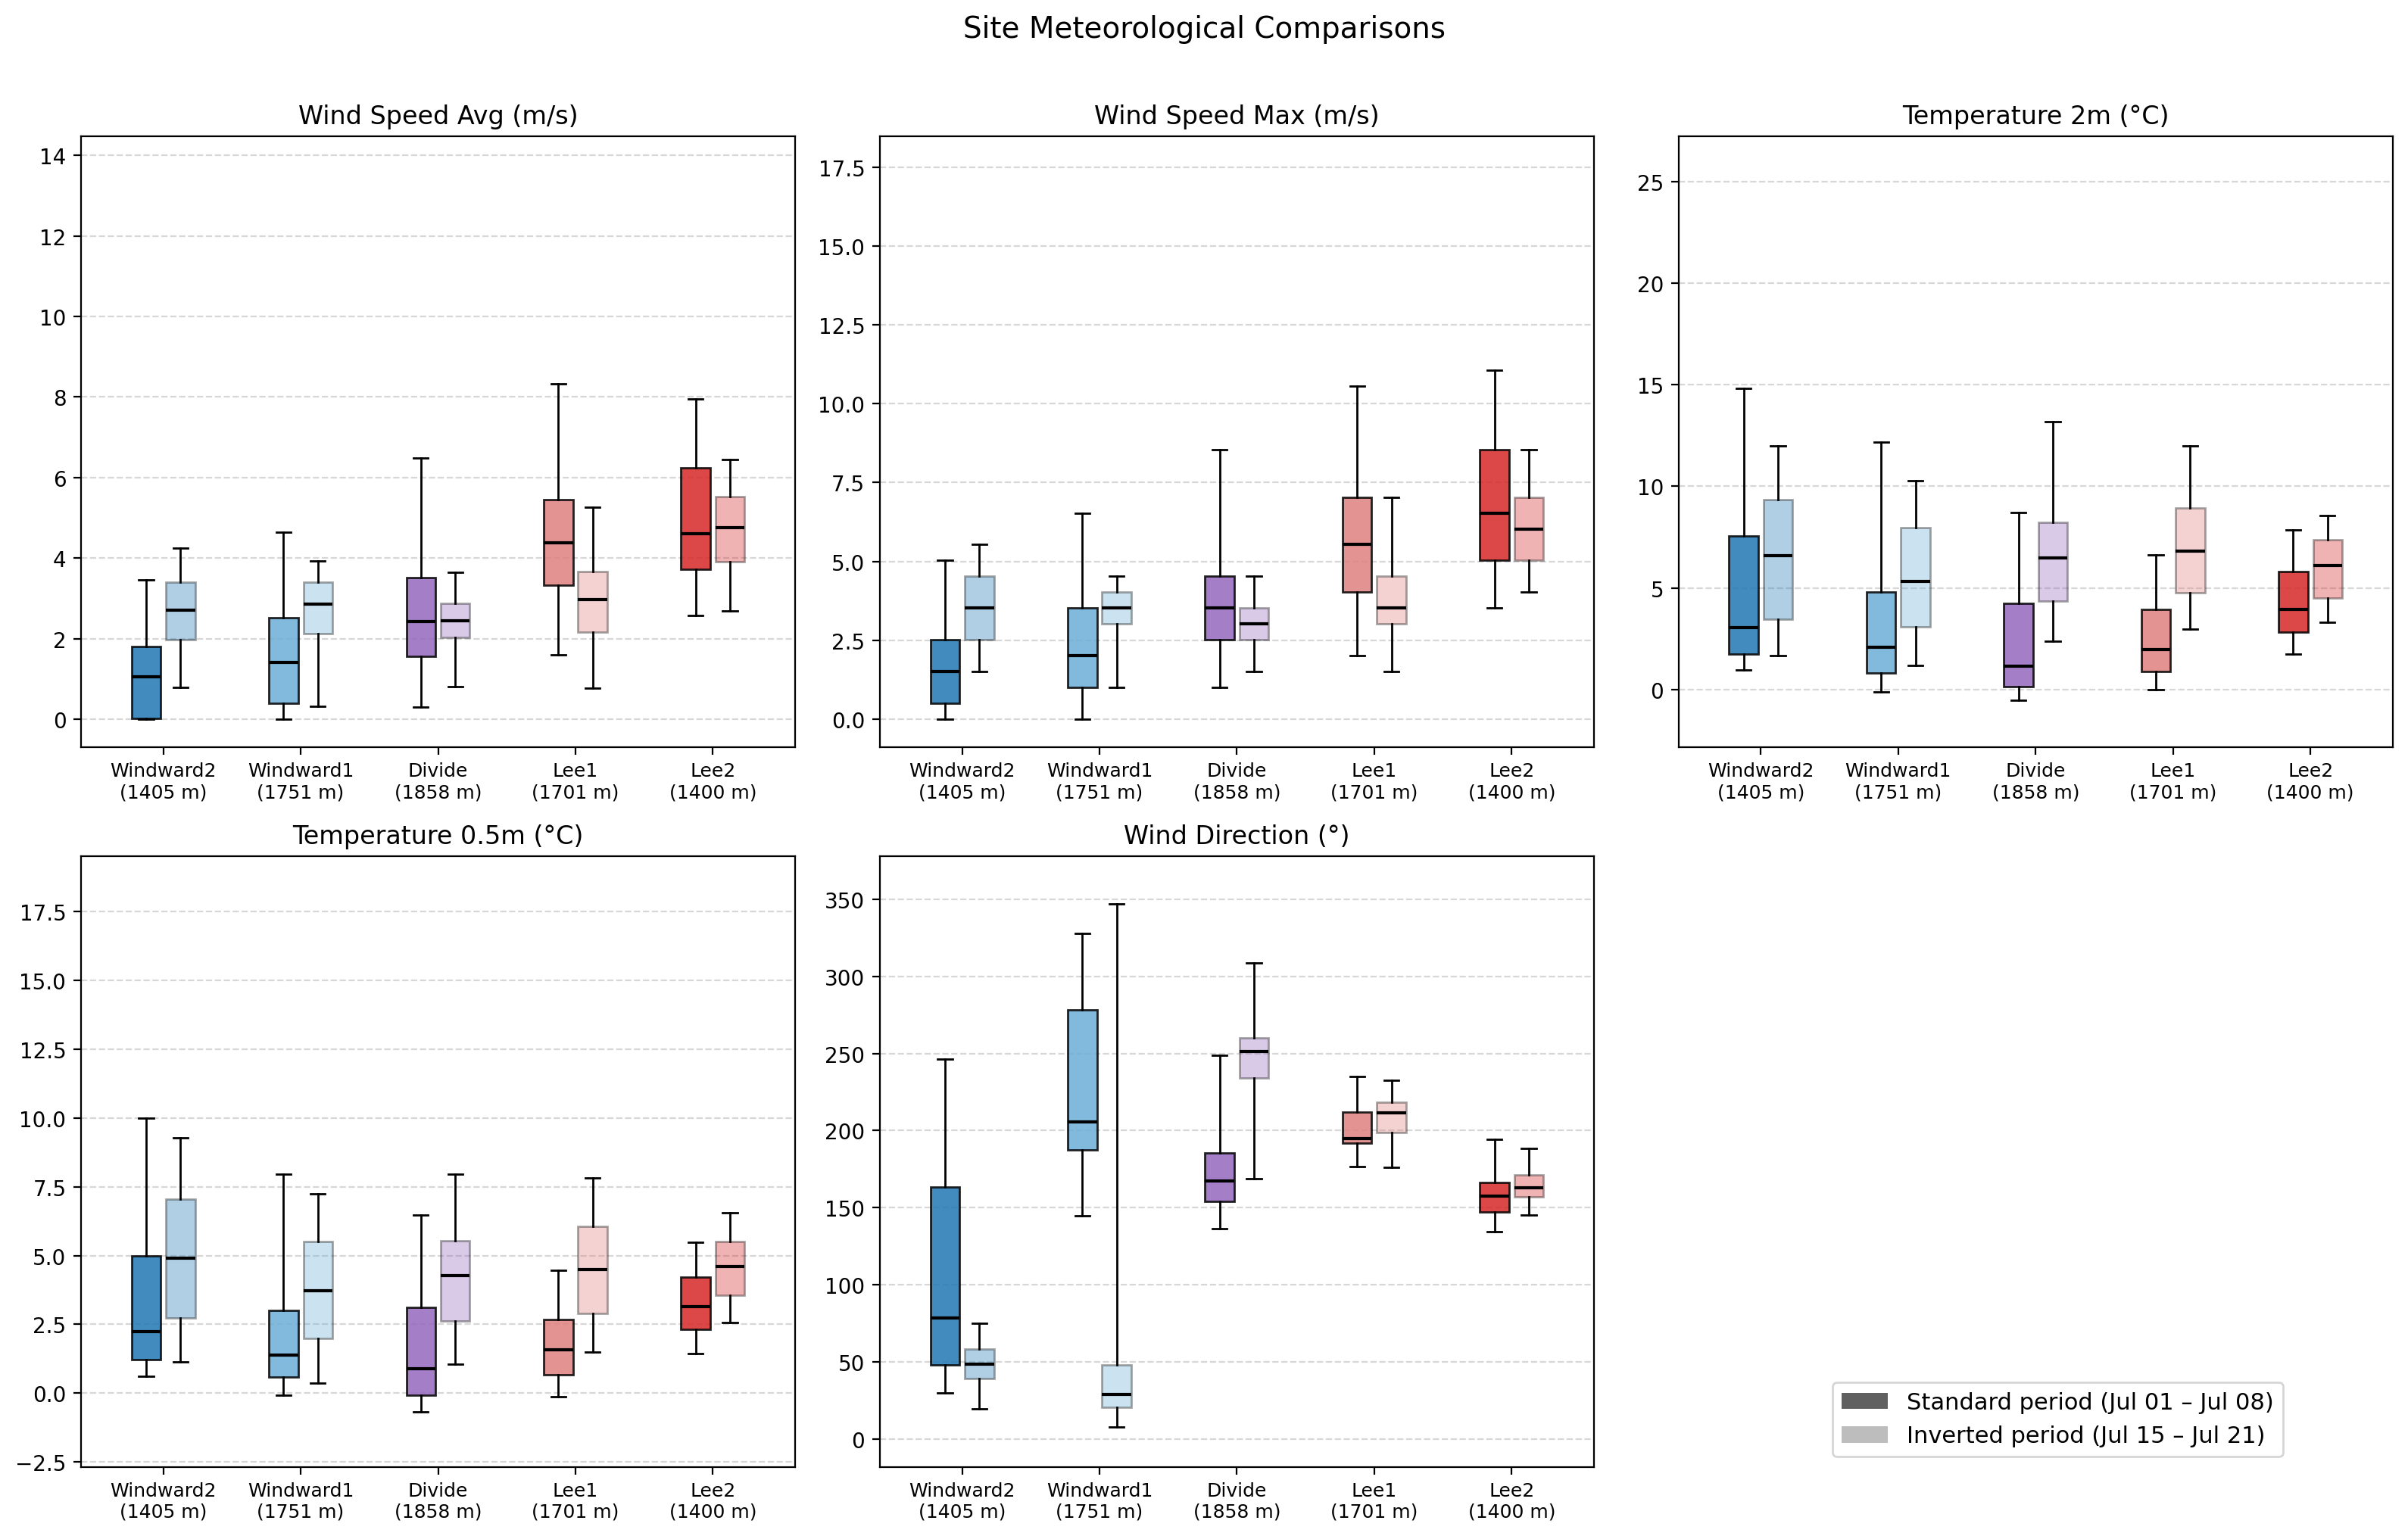

In [162]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import circmean, circstd

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=200)
axes = axes.flatten()

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee2":      "#d62728",
    "Lee1":      "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide":    "Divide\n(1858 m)",
    "Lee2":      "Lee2\n(1400 m)",
    "Lee1":      "Lee1\n(1701 m)",
}

da_wind_avg = ds["wind_speed_avg"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_wind_max = ds["wind_speed_peak"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_temp_2m  = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_temp_05m = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height="0.5m")
da_wdir     = ds["wind_direction"]

variables = [
    (da_wind_avg, "Wind Speed Avg (m/s)",  0),
    (da_wind_max, "Wind Speed Max (m/s)",  1),
    (da_temp_2m,  "Temperature 2m (°C)",   2),
    (da_temp_05m, "Temperature 0.5m (°C)", 3),
    (da_wdir,     "Wind Direction (°)",    4),
]

width = 0.25
group_spacing = 1.0

for da, title, ax_idx in variables:
    ax = axes[ax_idx]
    for i, site_id in enumerate(site_ids):
        color = site_colors[site_id]
        center = i * group_spacing

        for period_name, period_slice, offset, alpha in zip(
            period_slices.keys(),
            period_slices.values(),
            [-width / 2, width / 2],
            [period_alphas["standard"], period_alphas["inverted"]],
        ):
            vals = da.sel(site_id=site_id, datetime=period_slice).values
            vals = vals[~np.isnan(vals)]

            ax.boxplot(
                [vals],
                positions=[center + offset],
                widths=width * 0.85,
                patch_artist=True,
                manage_ticks=False,
                whis=(5, 95),
                boxprops=dict(facecolor=color, alpha=alpha),
                medianprops=dict(color="black", linewidth=1.5, zorder=5),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
            )

    ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
    ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=9)
    ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Hide the unused 6th subplot
axes[5].set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"],  label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
fig.legend(handles=legend_patches, loc="lower right", bbox_to_anchor=(0.95, 0.05), fontsize=11)

plt.suptitle("Site Meteorological Comparisons", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

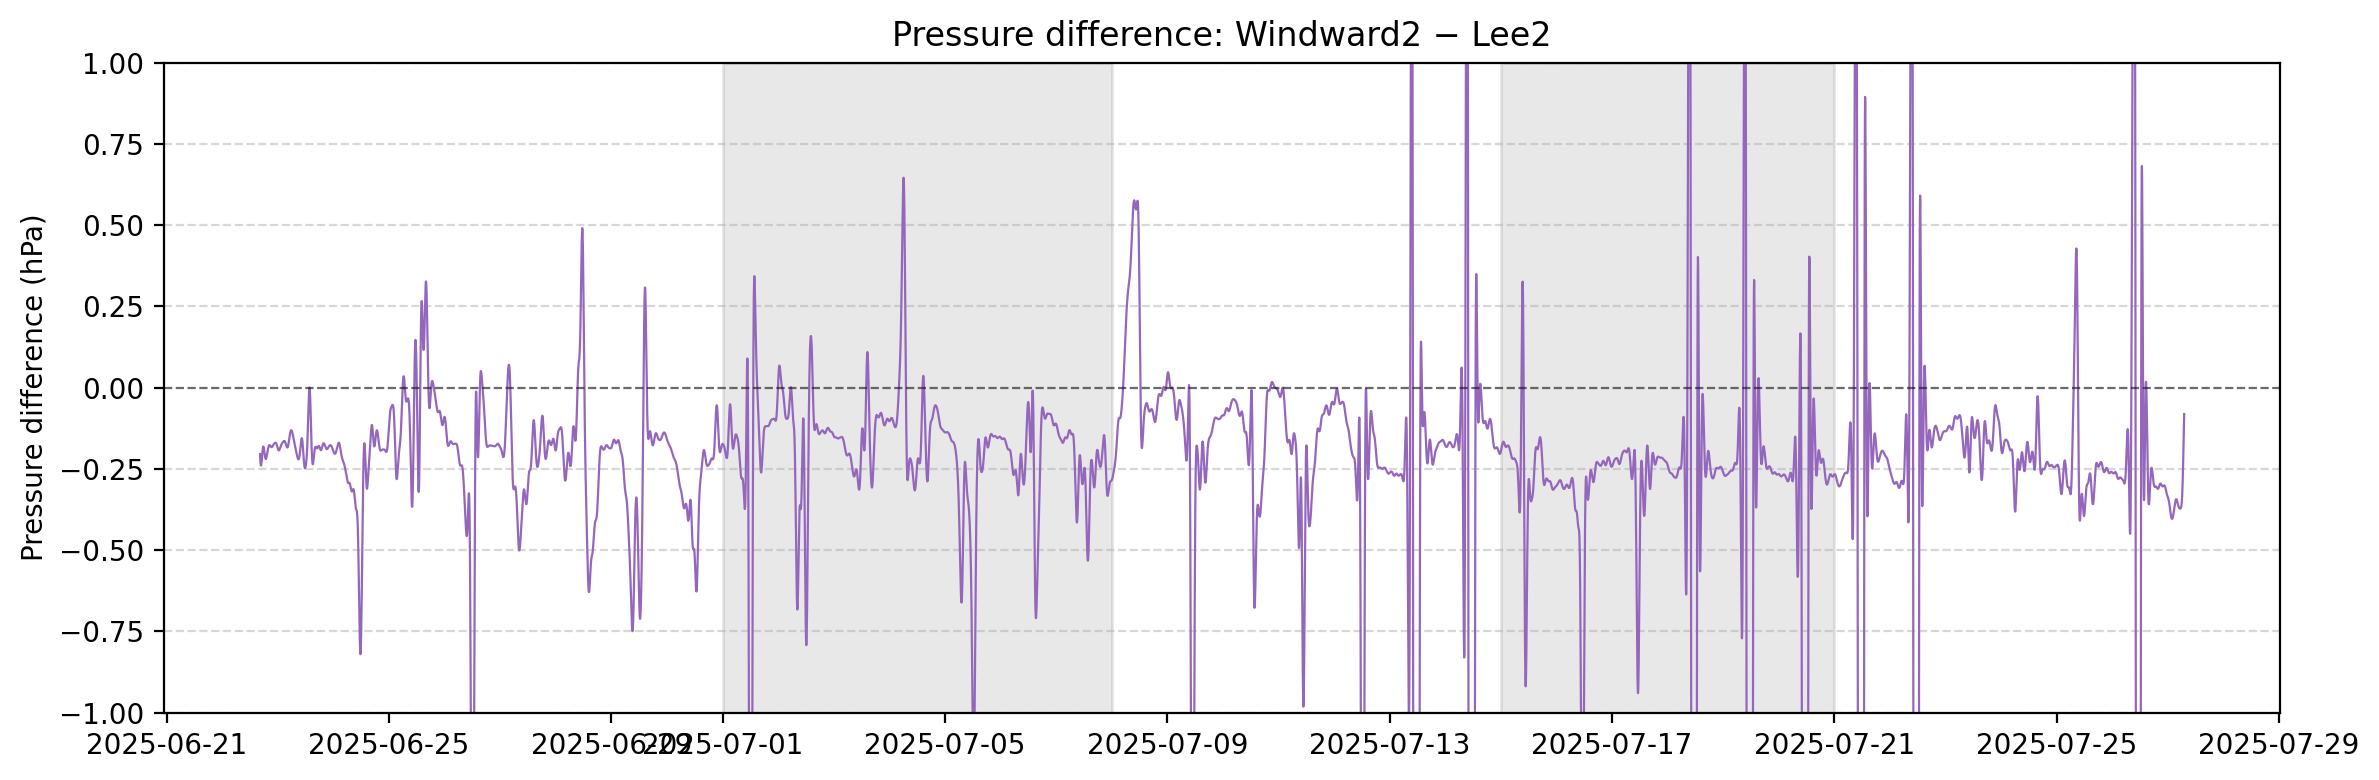

In [163]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 4), dpi=200)

da_pressure = ds_filtered["pressure"].sel(height="1m", shielding="unshielded", sensor_type="pace")

windward2 = da_pressure.sel(site_id="Windward2")
lee2      = da_pressure.sel(site_id="Lee2")

diff = windward2 - lee2

ax.plot(diff.datetime, diff.values, color="#9467bd", linewidth=0.8)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.12)
ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.12)

ax.set_ylabel("Pressure difference (hPa)")
ax.set_title("Pressure difference: Windward2 − Lee2")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

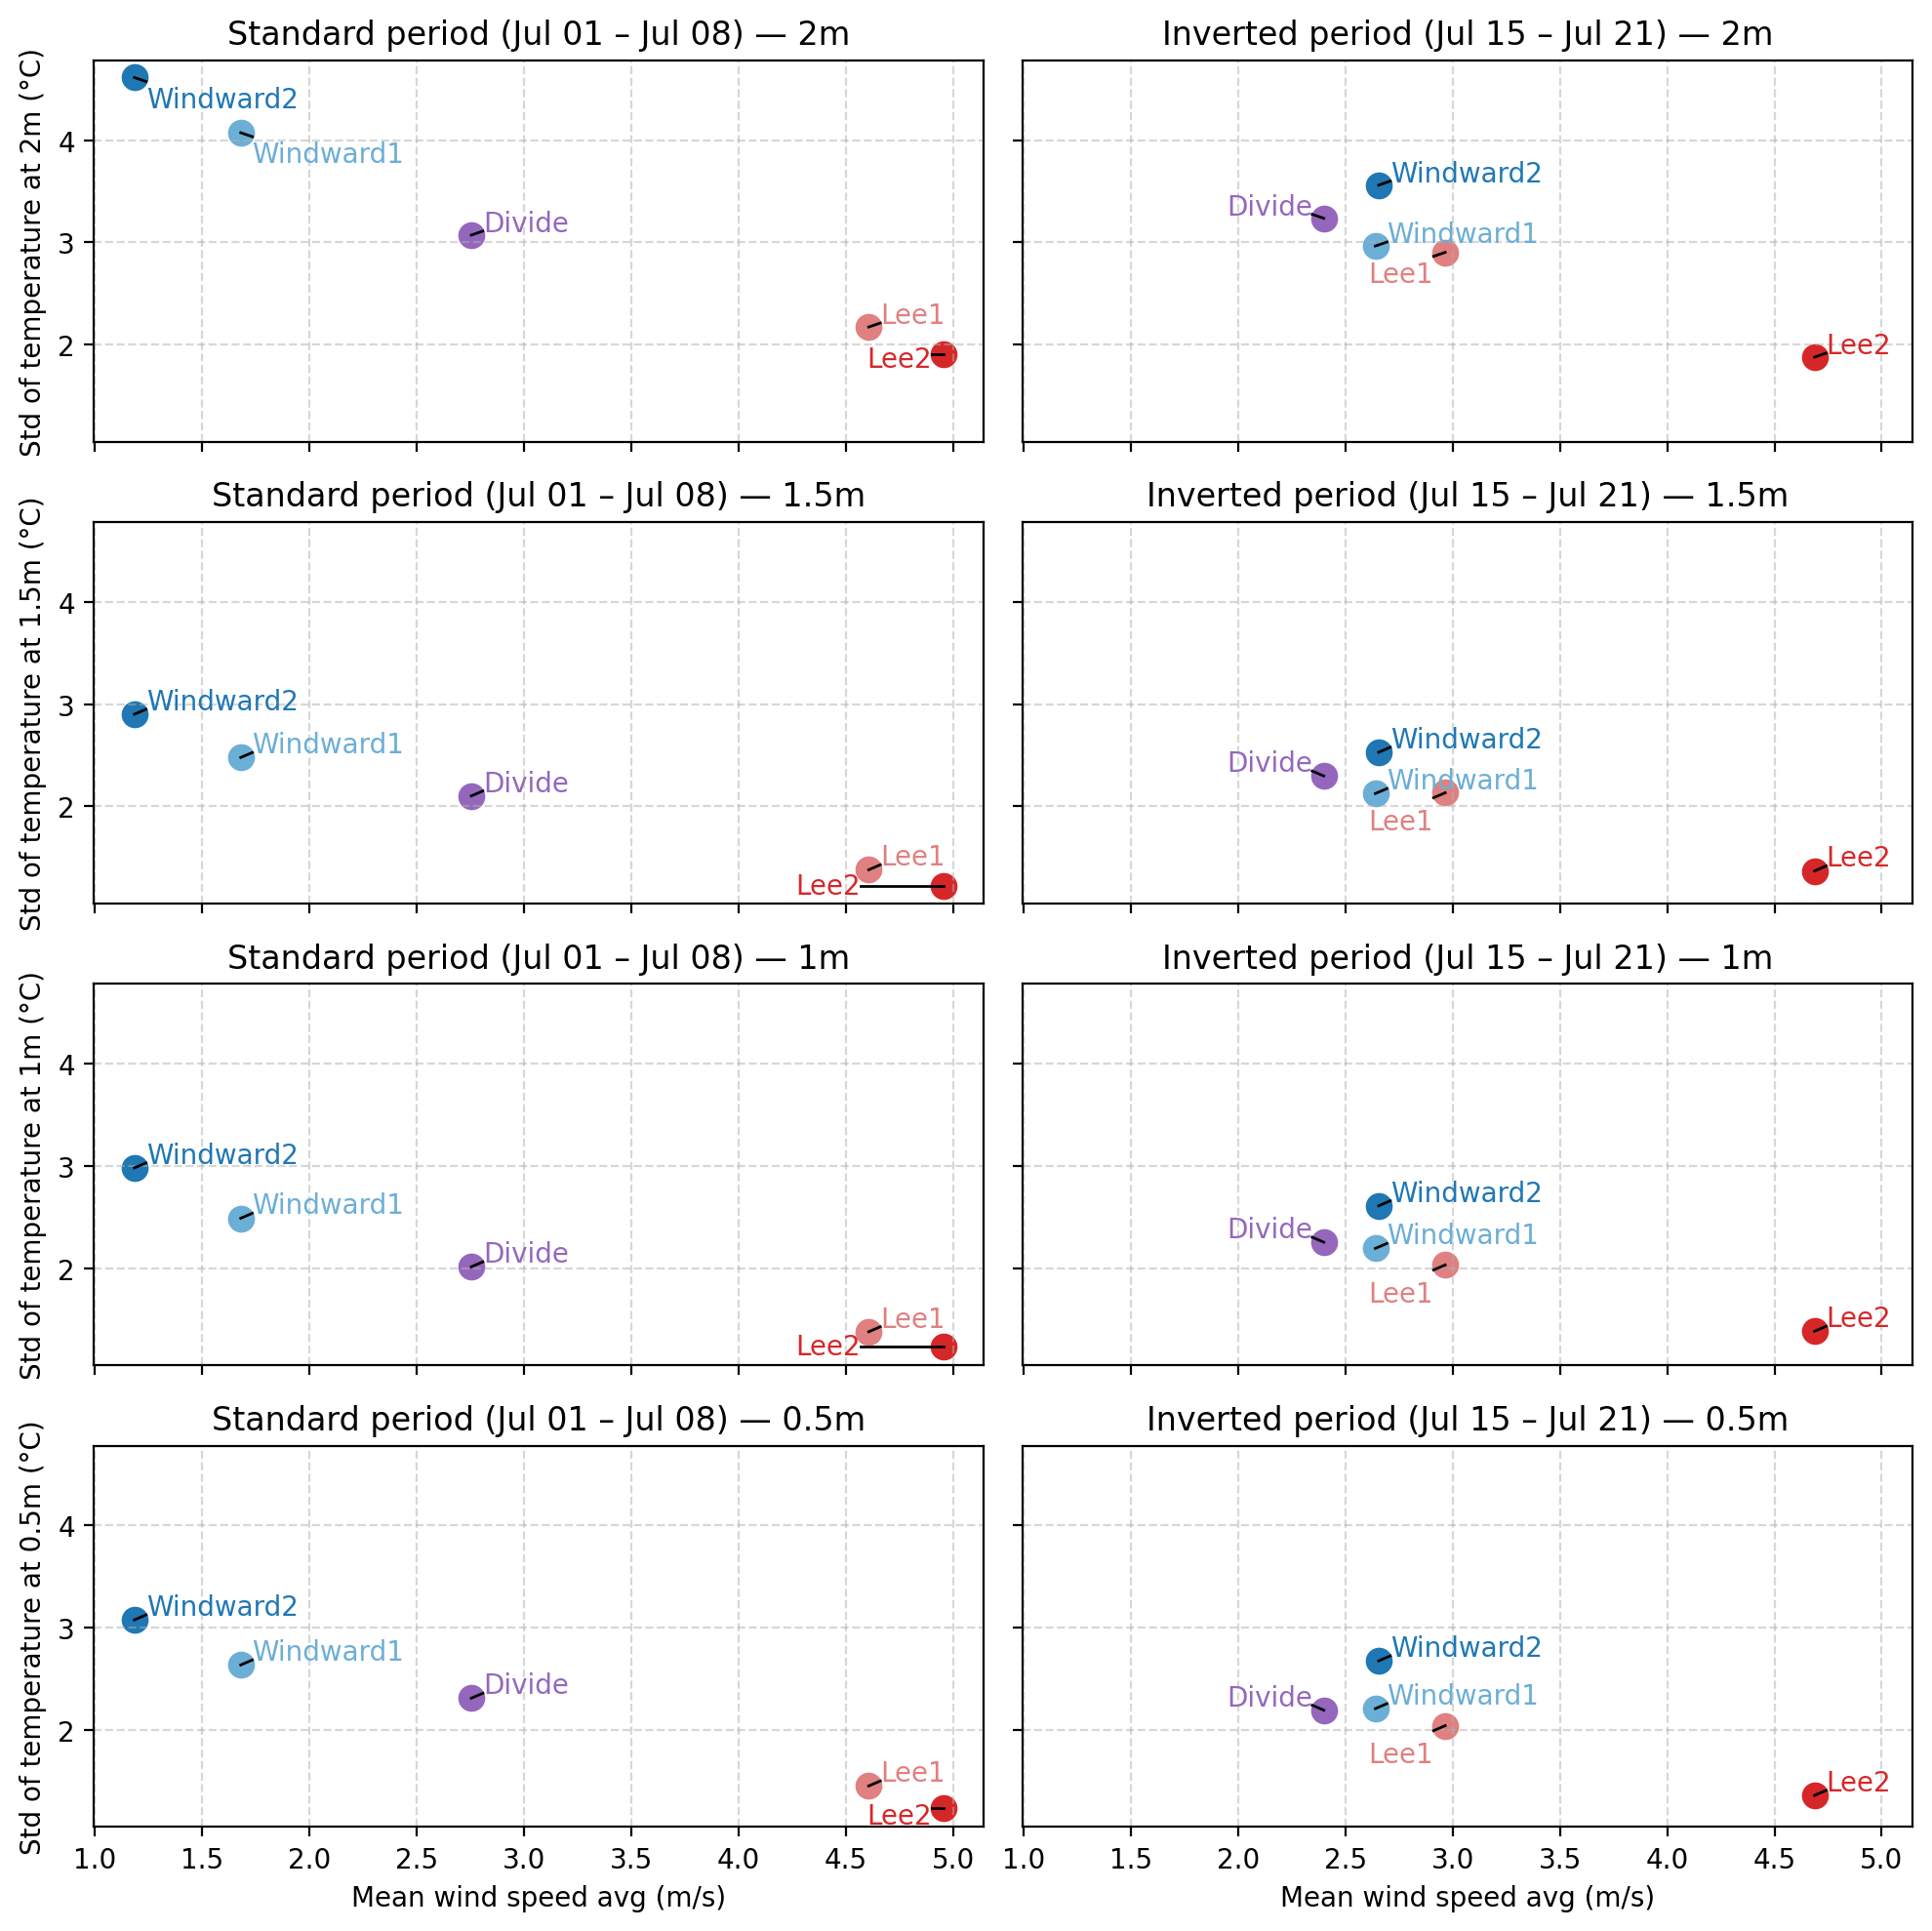

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import textalloc as ta

fig, axes = plt.subplots(4, 2, figsize=(10, 10), dpi=200, sharex=True, sharey=True)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee2":      "#d62728",
    "Lee1":      "#e08080",
}

da_wind_avg = ds["wind_speed_avg"].sel(shielding="unshielded", sensor_type="pace", height="2m")

heights = ["2m", "1.5m", "1m", "0.5m"]
da_temps = {h: ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height=h) for h in heights}

for row, height in enumerate(heights):
    for col, (period_name, period_slice) in enumerate(period_slices.items()):
        ax = axes[row, col]
        xs, ys, texts, colors = [], [], [], []

        for site_id in site_ids:
            wind_vals = da_wind_avg.sel(site_id=site_id, datetime=period_slice).values
            temp_vals = da_temps[height].sel(site_id=site_id, datetime=period_slice).values

            x = np.nanmean(wind_vals)
            y = np.nanstd(temp_vals)

            ax.scatter(x, y, color=site_colors[site_id], s=80)

            xs.append(x)
            ys.append(y)
            texts.append(site_id)
            colors.append(site_colors[site_id])

        ta.allocate(
            ax,
            x=xs, y=ys,
            text_list=texts,
            textcolor=colors,
            linecolor="black",
            avoid_crossing_label_lines=True,
            avoid_label_lines_overlap=True,
        )

        if row == 3:
            ax.set_xlabel("Mean wind speed avg (m/s)")
        if col == 0:
            ax.set_ylabel(f"Std of temperature at {height} (°C)")
        ax.set_title(f"{period_labels[period_name]} — {height}")
        ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

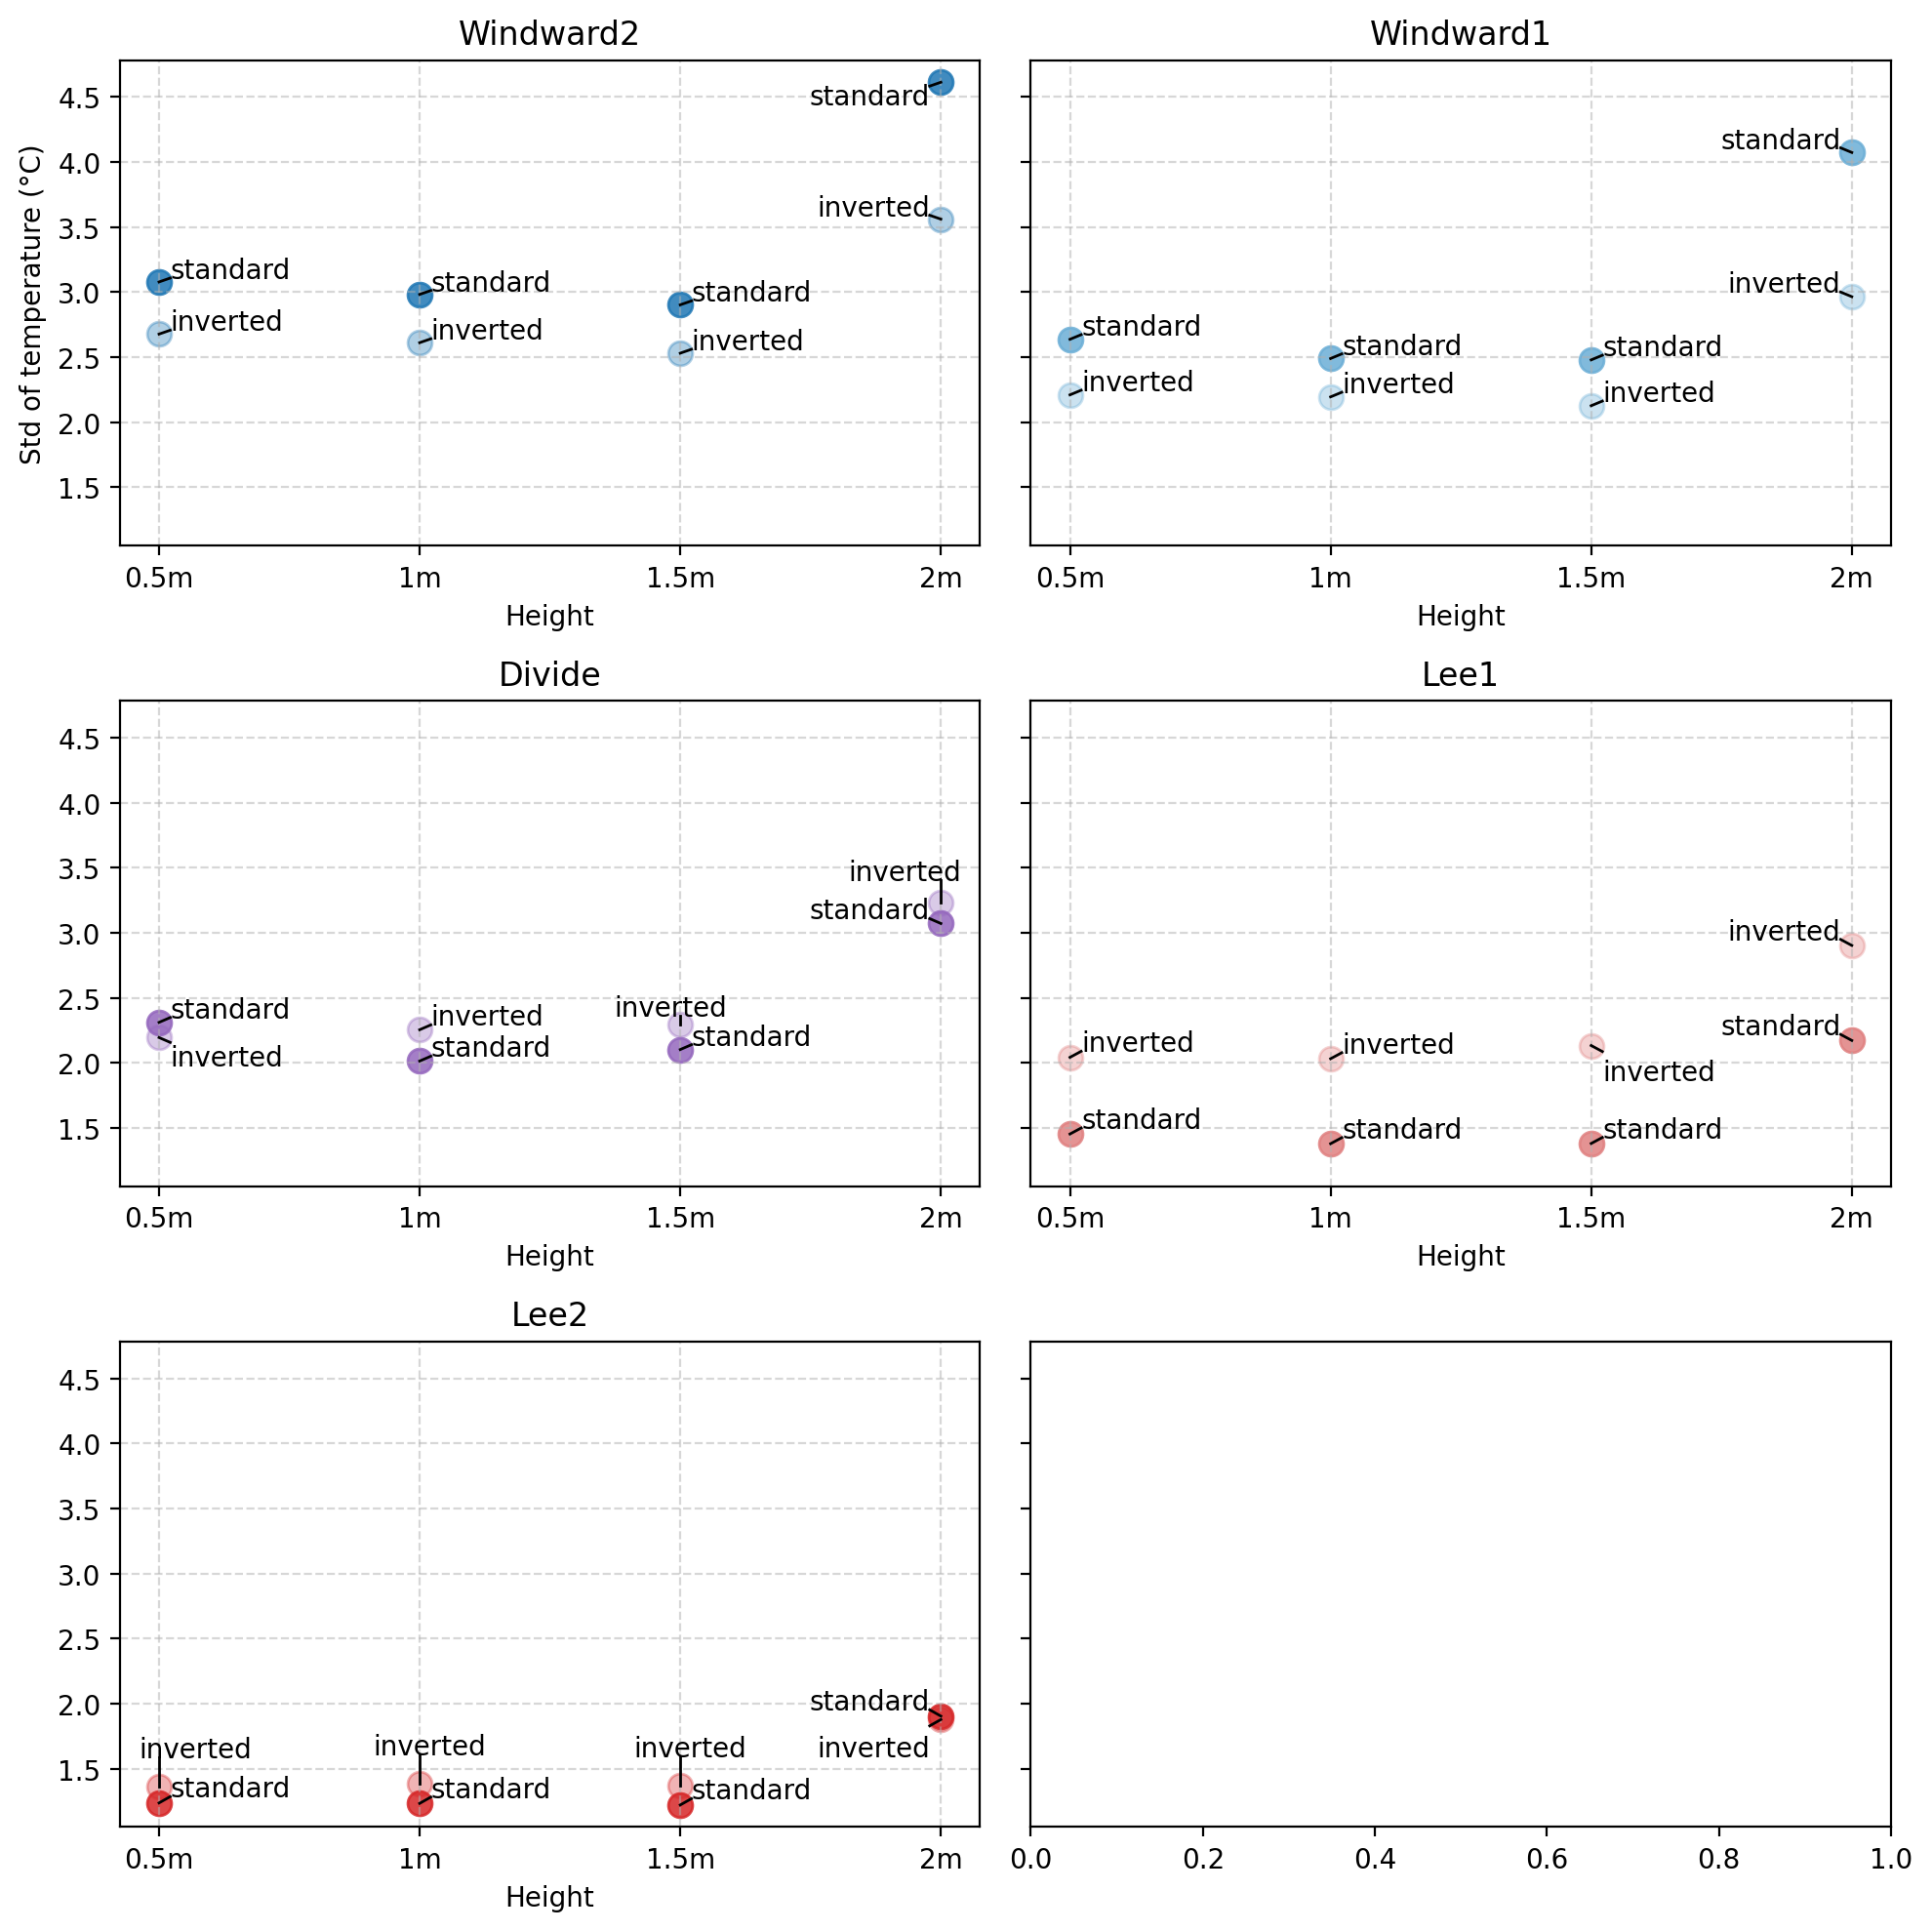

In [165]:
import matplotlib.pyplot as plt
import numpy as np
import textalloc as ta

fig, axes = plt.subplots(3, 2, figsize=(10, 10), dpi=200, sharey=True)
axes = axes.ravel()

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee2":      "#d62728",
    "Lee1":      "#e08080",
}

heights = ["0.5m", "1m", "1.5m", "2m"]
da_temps = {h: ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height=h) for h in heights}

height_x = {h: i for i, h in enumerate(heights)}

for ax, site_id in zip(axes, site_ids):
    xs, ys, texts, colors = [], [], [], []

    for period_name, period_slice in period_slices.items():
        for height in heights:
            temp_vals = da_temps[height].sel(site_id=site_id, datetime=period_slice).values

            x = height_x[height]
            y = np.nanstd(temp_vals)

            ax.scatter(x, y, color=site_colors[site_id], alpha=period_alphas[period_name], s=80)

            xs.append(x)
            ys.append(y)
            texts.append(period_name)
            colors.append("black")

    ta.allocate(
        ax,
        x=xs, y=ys,
        text_list=texts,
        textcolor=colors,
        linecolor="black",
        avoid_crossing_label_lines=True,
        avoid_label_lines_overlap=True,
    )

    ax.set_xticks(list(height_x.values()))
    ax.set_xticklabels(heights)
    ax.set_xlabel("Height")
    ax.set_title(site_id)
    ax.grid(linestyle="--", alpha=0.5)

axes[0].set_ylabel("Std of temperature (°C)")

plt.tight_layout()
plt.show()

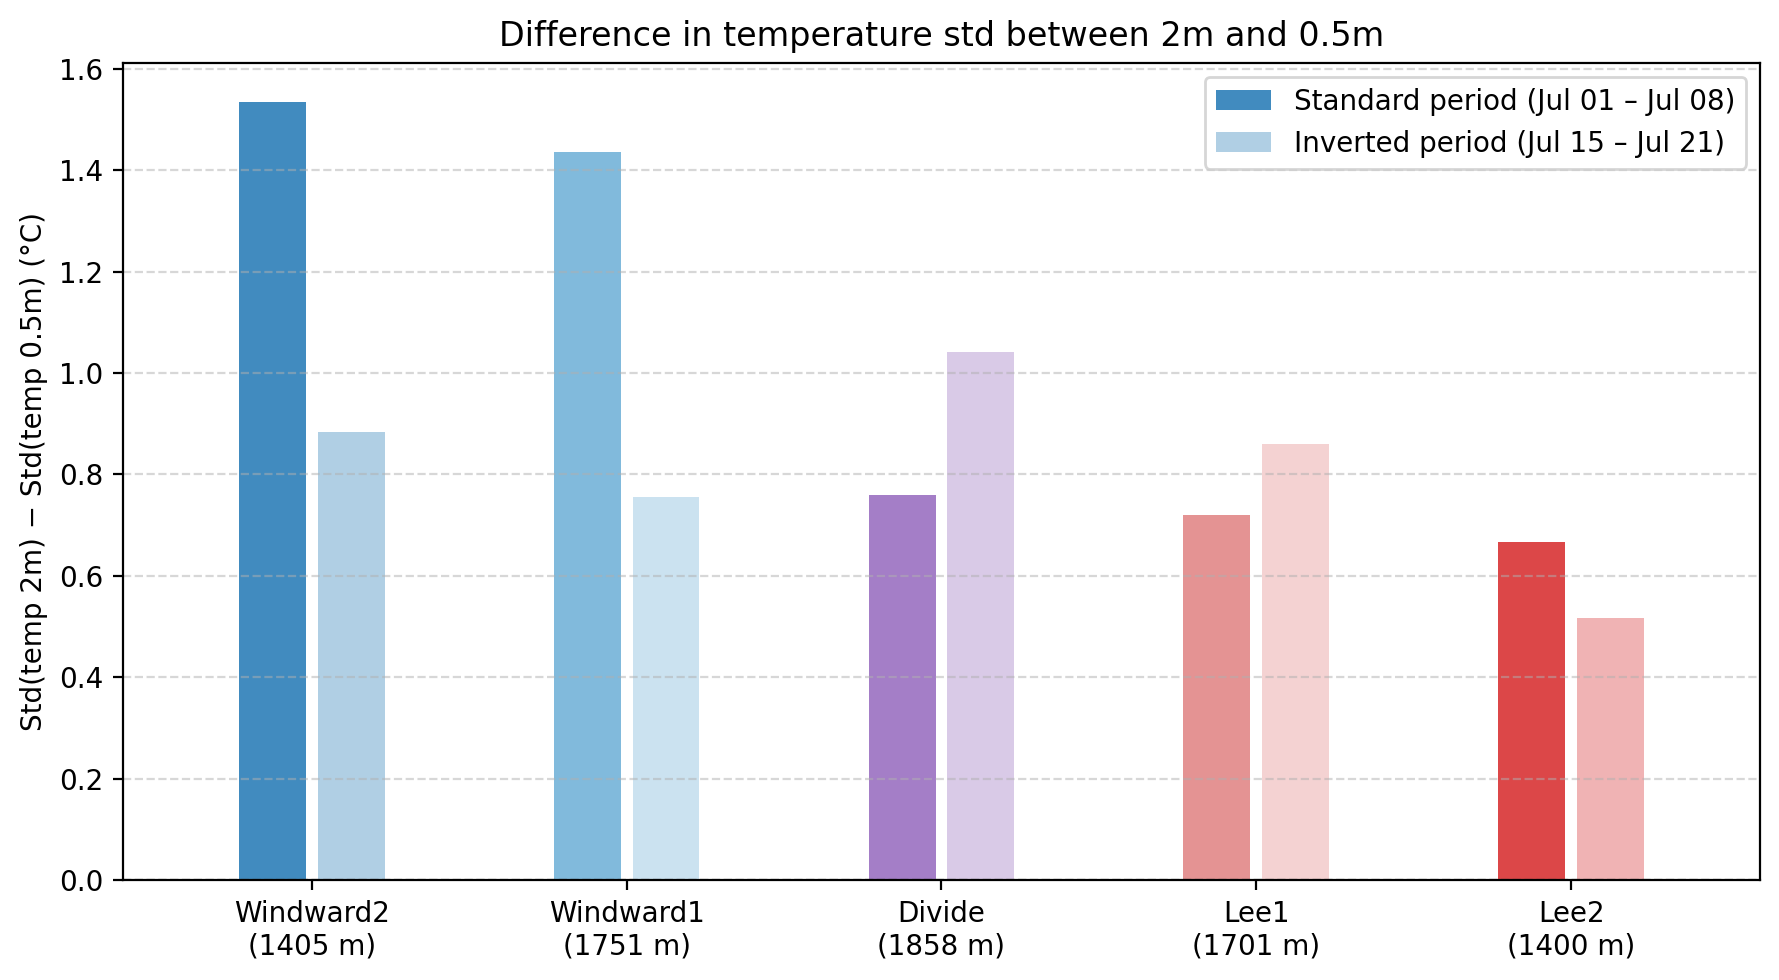

In [166]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5), dpi=200)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee2":      "#d62728",
    "Lee1":      "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide":    "Divide\n(1858 m)",
    "Lee2":      "Lee2\n(1400 m)",
    "Lee1":      "Lee1\n(1701 m)",
}

da_temp_2m  = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_temp_05m = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace", height="0.5m")

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    center = i * group_spacing

    for (period_name, period_slice), offset in zip(period_slices.items(), [-width / 2, width / 2]):
        vals_2m  = da_temp_2m.sel(site_id=site_id, datetime=period_slice).values
        vals_05m = da_temp_05m.sel(site_id=site_id, datetime=period_slice).values

        diff = np.nanstd(vals_2m) - np.nanstd(vals_05m)

        ax.bar(
            center + offset,
            diff,
            width=width * 0.85,
            color=site_colors[site_id],
            alpha=period_alphas[period_name],
            label=period_labels[period_name] if i == 0 else None,
        )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.set_ylabel("Std(temp 2m) − Std(temp 0.5m) (°C)")
ax.set_title("Difference in temperature std between 2m and 0.5m")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

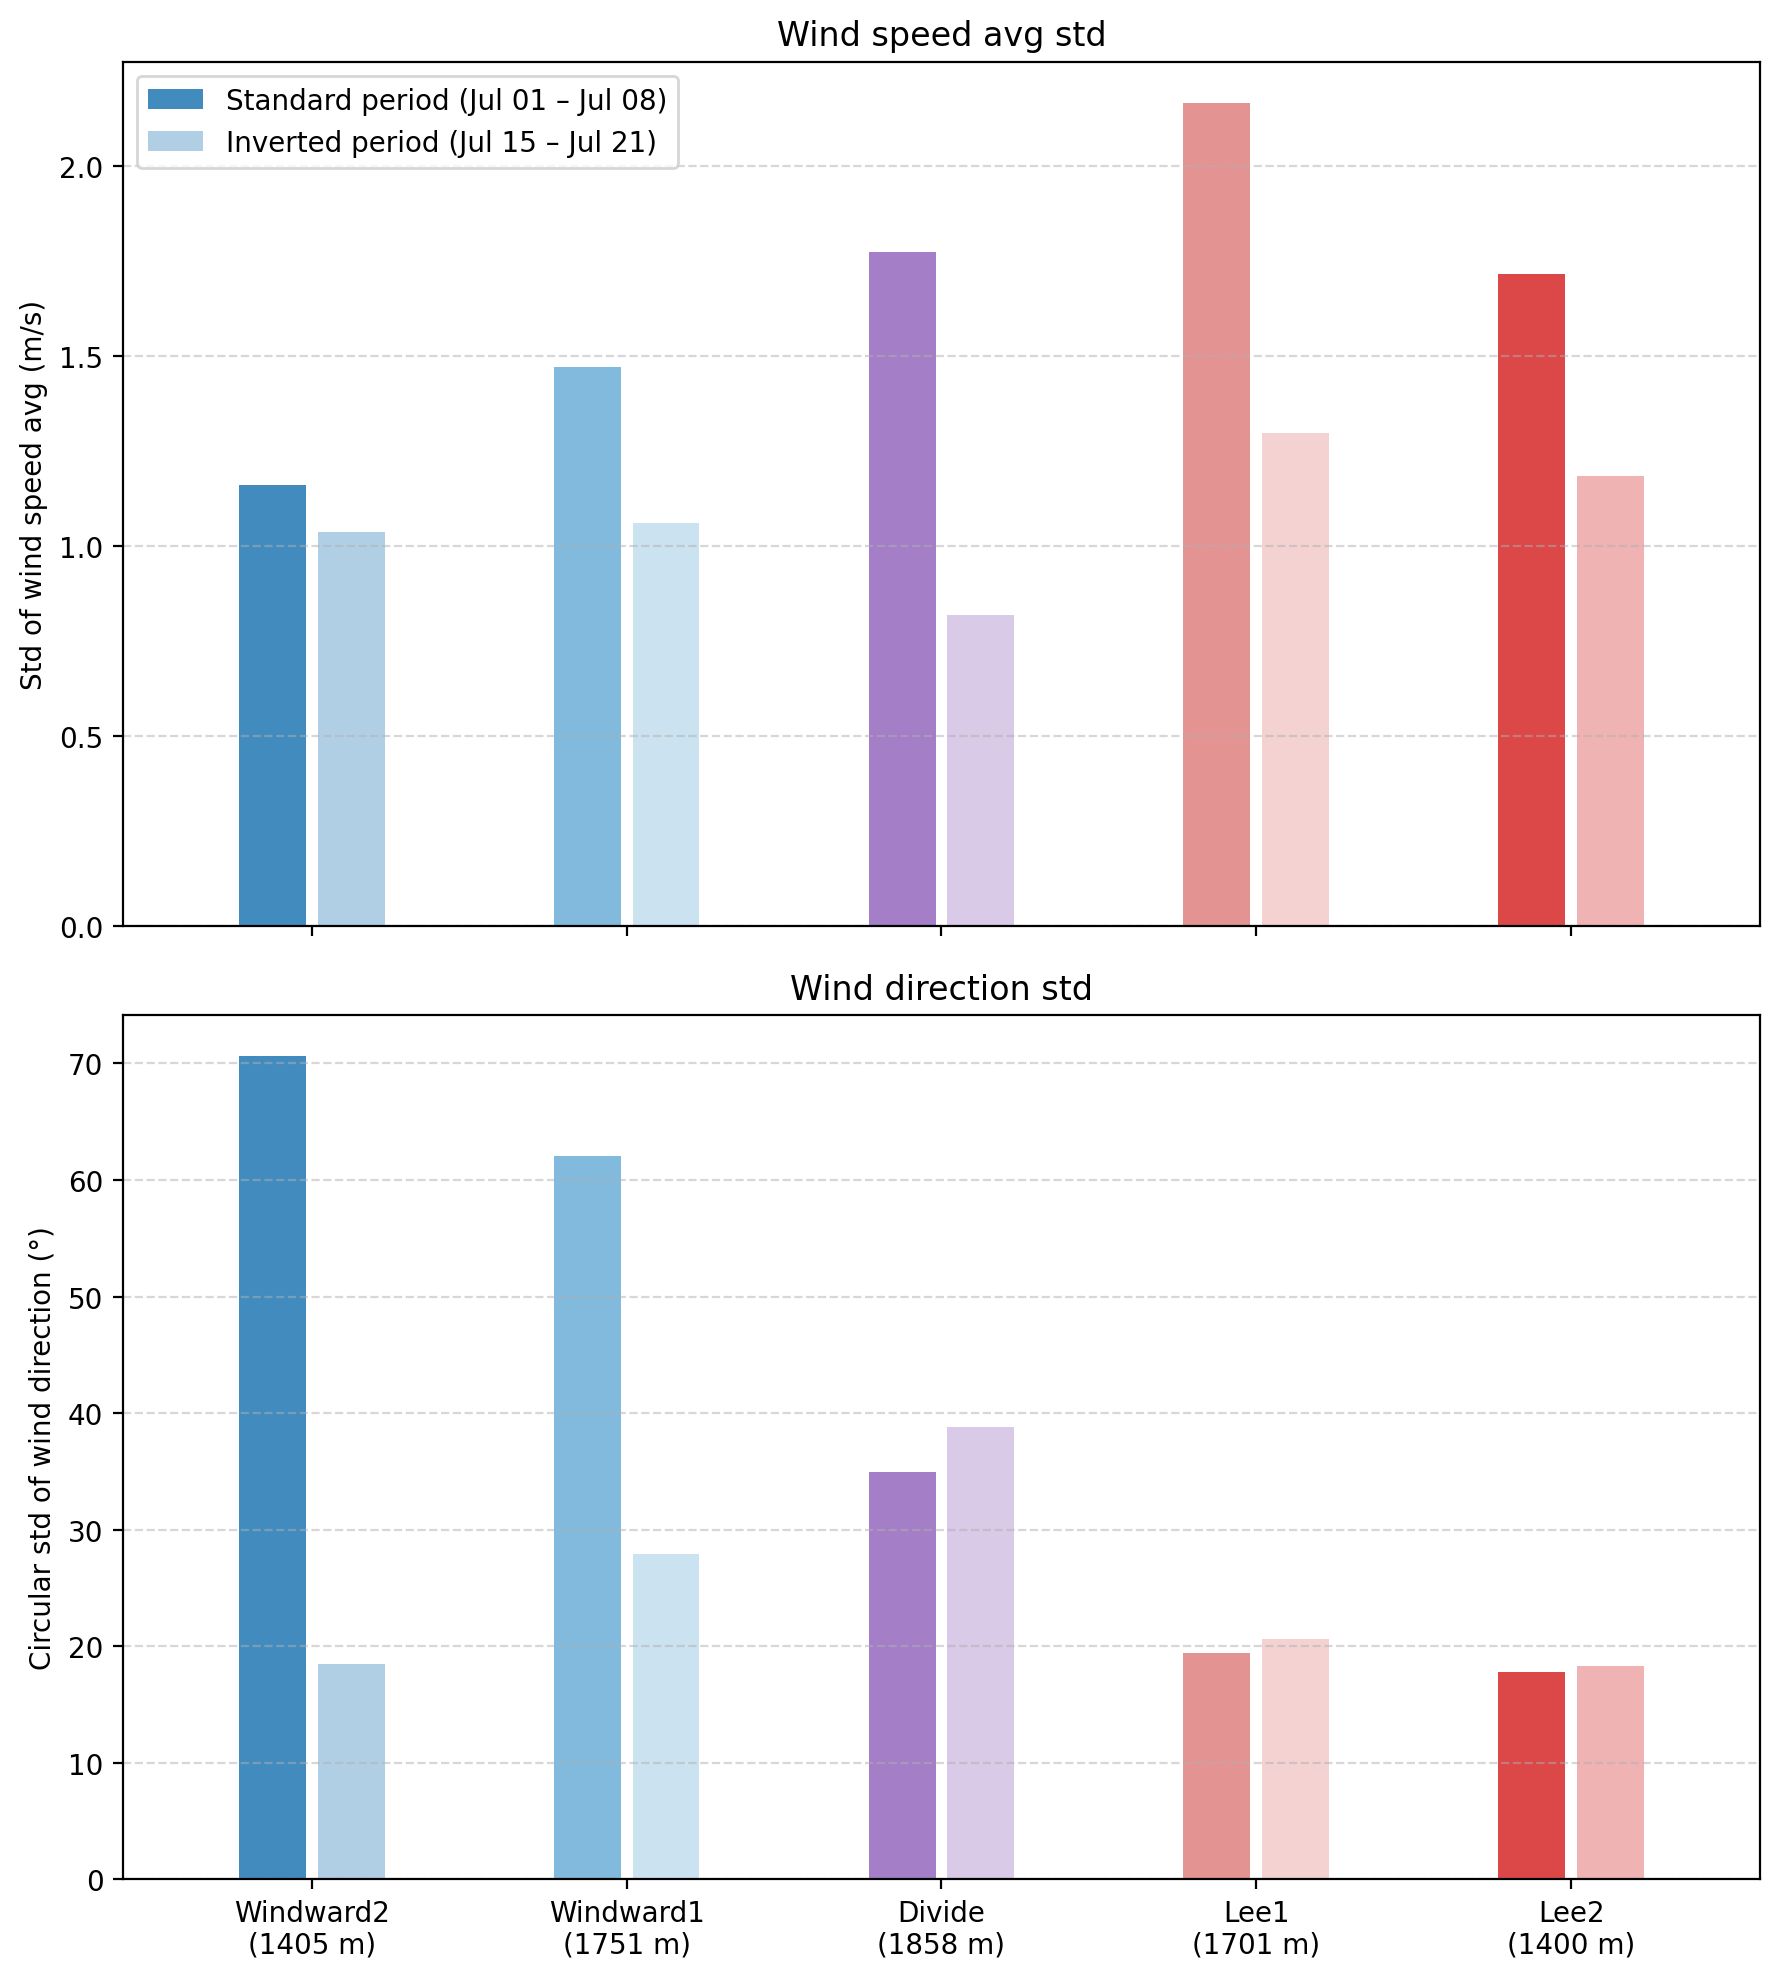

In [167]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import circstd

fig, axes = plt.subplots(2, 1, figsize=(9, 10), dpi=200, sharex=True)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee2":      "#d62728",
    "Lee1":      "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide":    "Divide\n(1858 m)",
    "Lee2":      "Lee2\n(1400 m)",
    "Lee1":      "Lee1\n(1701 m)",
}

da_wind_avg = ds["wind_speed_avg"].sel(shielding="unshielded", sensor_type="pace", height="2m")
da_wdir     = ds["wind_direction"]

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    center = i * group_spacing

    for (period_name, period_slice), offset in zip(period_slices.items(), [-width / 2, width / 2]):

        # Wind speed avg std
        vals = da_wind_avg.sel(site_id=site_id, datetime=period_slice).values
        axes[0].bar(
            center + offset,
            np.nanstd(vals),
            width=width * 0.85,
            color=site_colors[site_id],
            alpha=period_alphas[period_name],
            label=period_labels[period_name] if i == 0 else None,
        )

        # Wind direction circular std
        vals = da_wdir.sel(site_id=site_id, datetime=period_slice).values
        vals = vals[~np.isnan(vals)]
        axes[1].bar(
            center + offset,
            circstd(vals, high=360),
            width=width * 0.85,
            color=site_colors[site_id],
            alpha=period_alphas[period_name],
        )

axes[0].set_ylabel("Std of wind speed avg (m/s)")
axes[0].set_title("Wind speed avg std")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].set_ylabel("Circular std of wind direction (°)")
axes[1].set_title("Wind direction std")
axes[1].set_xticks([i * group_spacing for i in range(len(site_ids))])
axes[1].set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
axes[1].set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

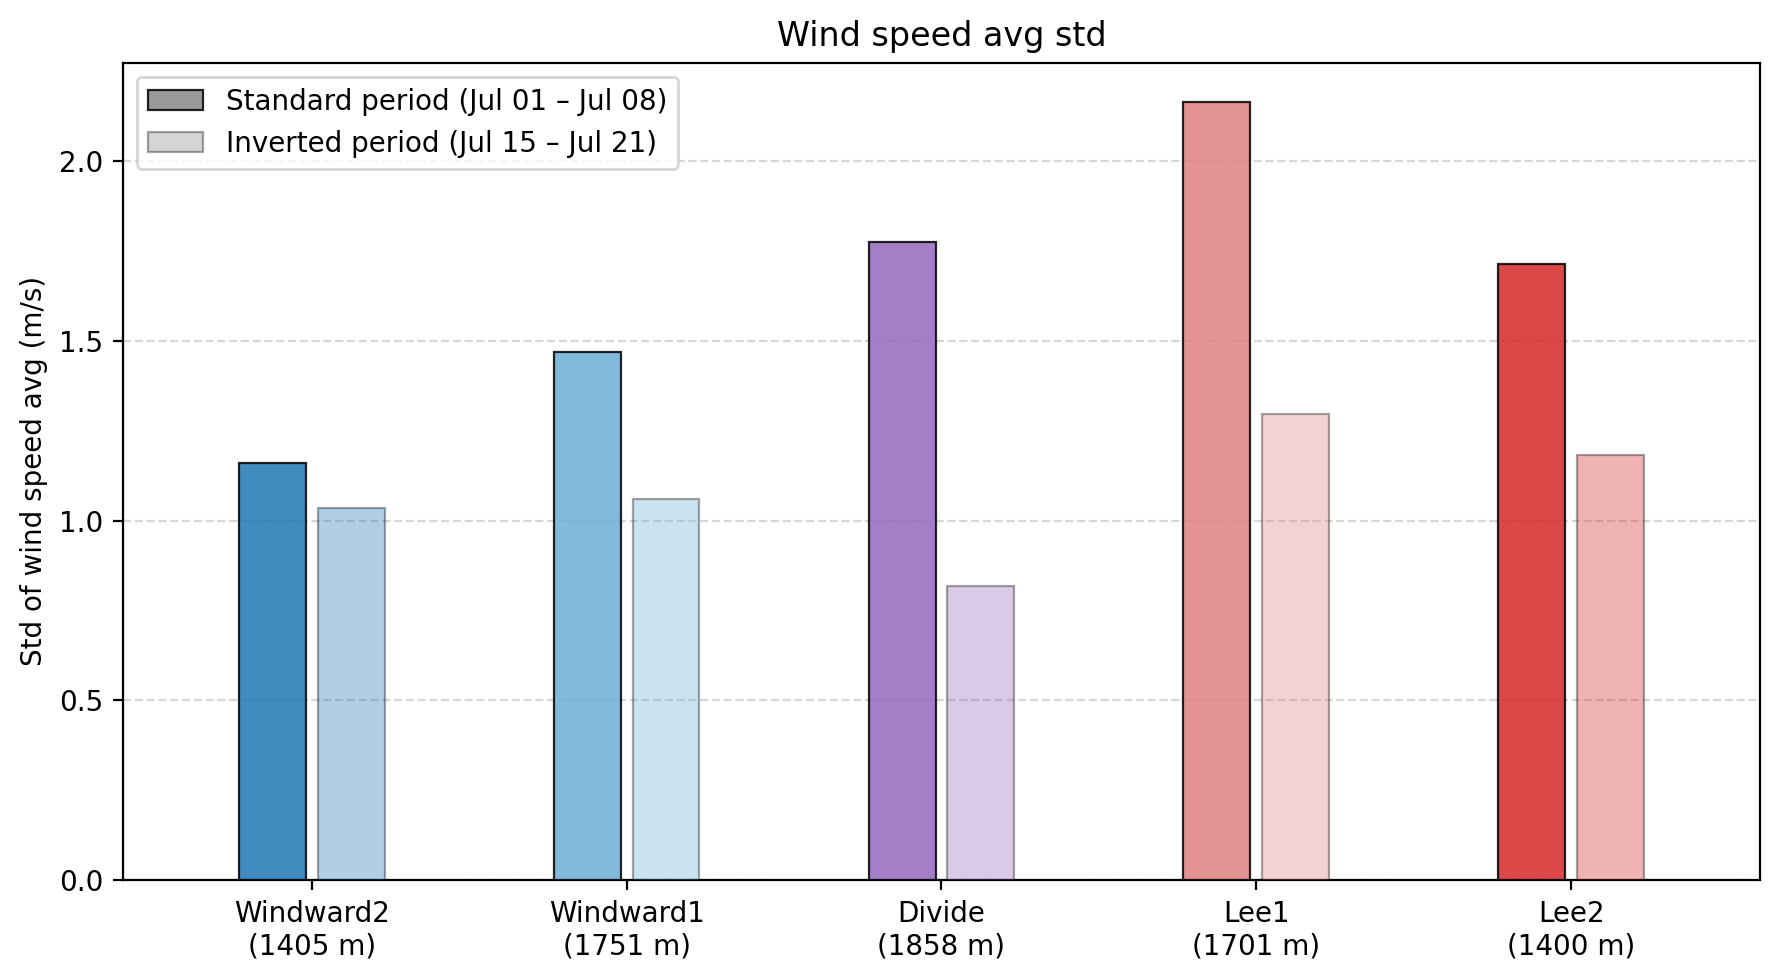

In [168]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5), dpi=200)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee2":      "#d62728",
    "Lee1":      "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide":    "Divide\n(1858 m)",
    "Lee2":      "Lee2\n(1400 m)",
    "Lee1":      "Lee1\n(1701 m)",
}

da_wind_avg = ds["wind_speed_avg"].sel(shielding="unshielded", sensor_type="pace", height="2m")

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    center = i * group_spacing

    for (period_name, period_slice), offset in zip(period_slices.items(), [-width / 2, width / 2]):
        vals = da_wind_avg.sel(site_id=site_id, datetime=period_slice).values
        ax.bar(
            center + offset,
            np.nanstd(vals),
            width=width * 0.85,
            color=site_colors[site_id],
            alpha=period_alphas[period_name],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

legend_patches = [
    mpatches.Patch(facecolor="#888888", alpha=period_alphas[p], edgecolor="black", linewidth=0.8, label=period_labels[p])
    for p in period_slices
]
ax.legend(handles=legend_patches)

ax.set_ylabel("Std of wind speed avg (m/s)")
ax.set_title("Wind speed avg std")
ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

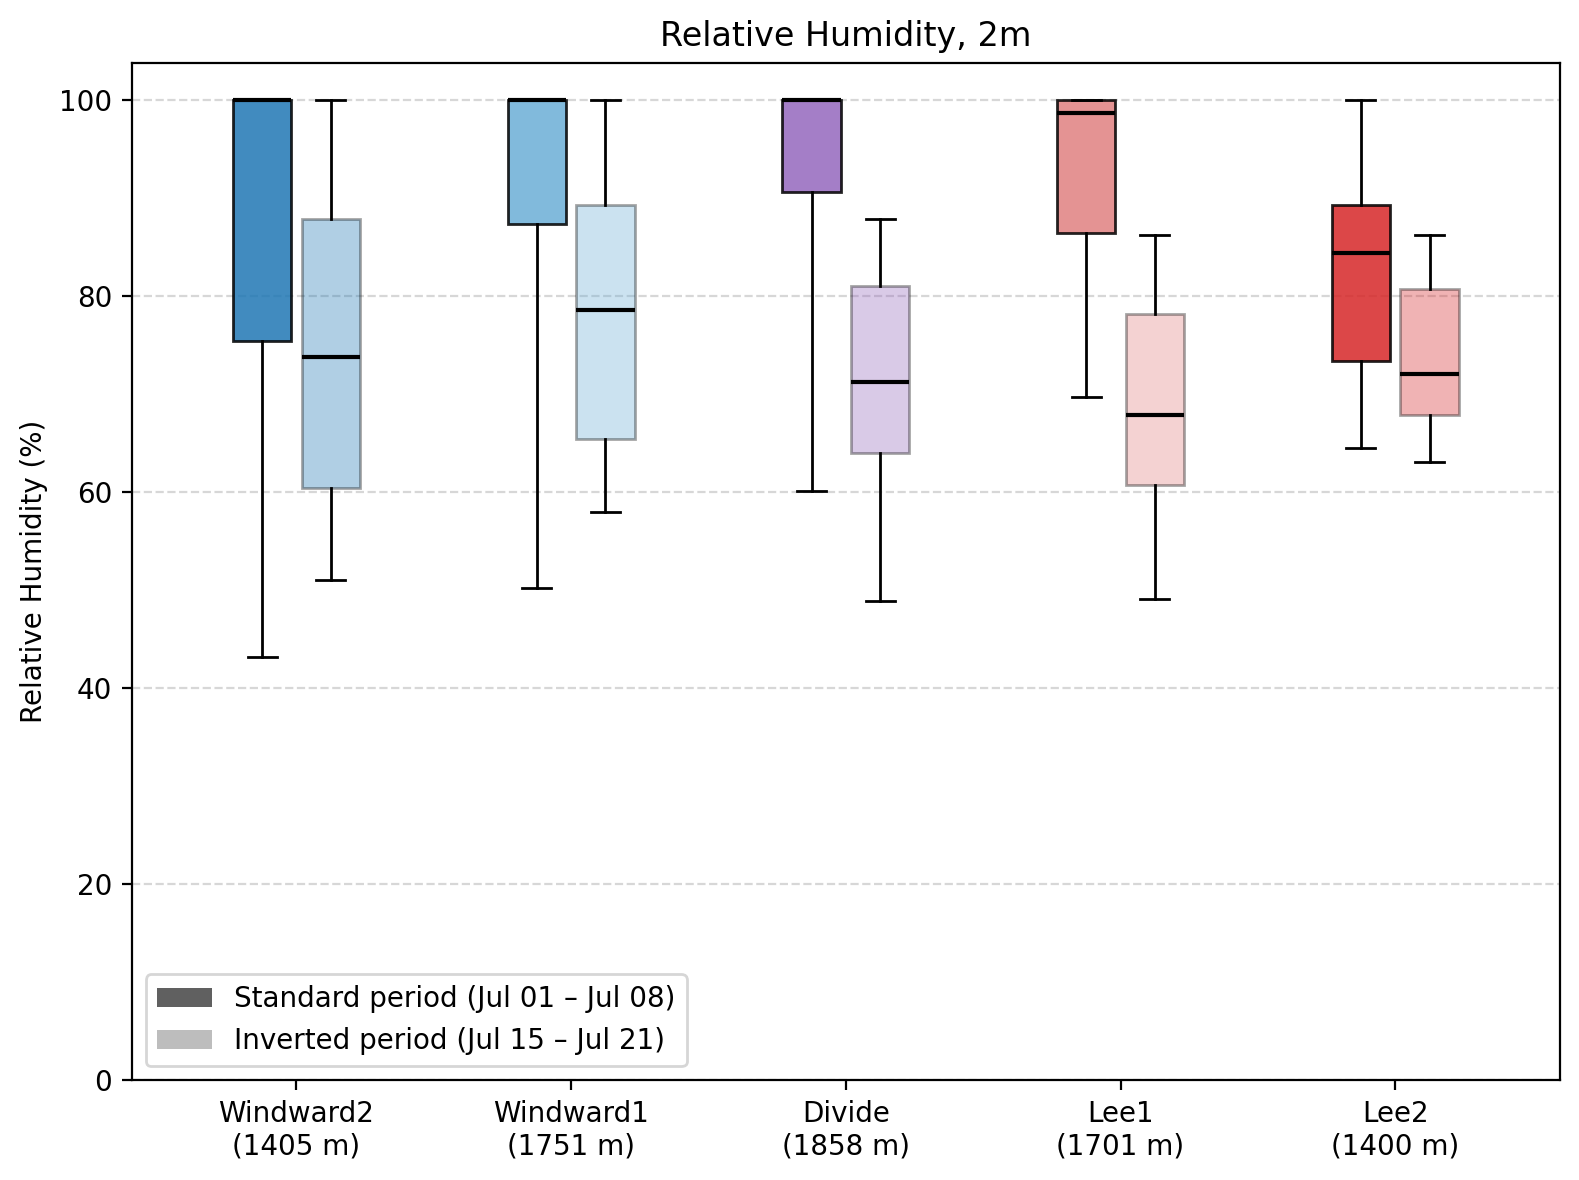

In [169]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide": "#9467bd",
    "Lee2": "#d62728",
    "Lee1": "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide": "Divide\n(1858 m)",
    "Lee2": "Lee2\n(1400 m)",
    "Lee1": "Lee1\n(1701 m)",
}

da_temp = ds["relative_humidity"].sel(shielding="unshielded", sensor_type="pace")
da_diff = da_temp.sel(height="2m")

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = da_diff.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals = da_diff.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(5, 95),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
        )

ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.set_ylim(bottom=0)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax.legend(handles=legend_patches)
ax.set_ylabel("Relative Humidity (%)")
ax.set_title("Relative Humidity, 2m")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

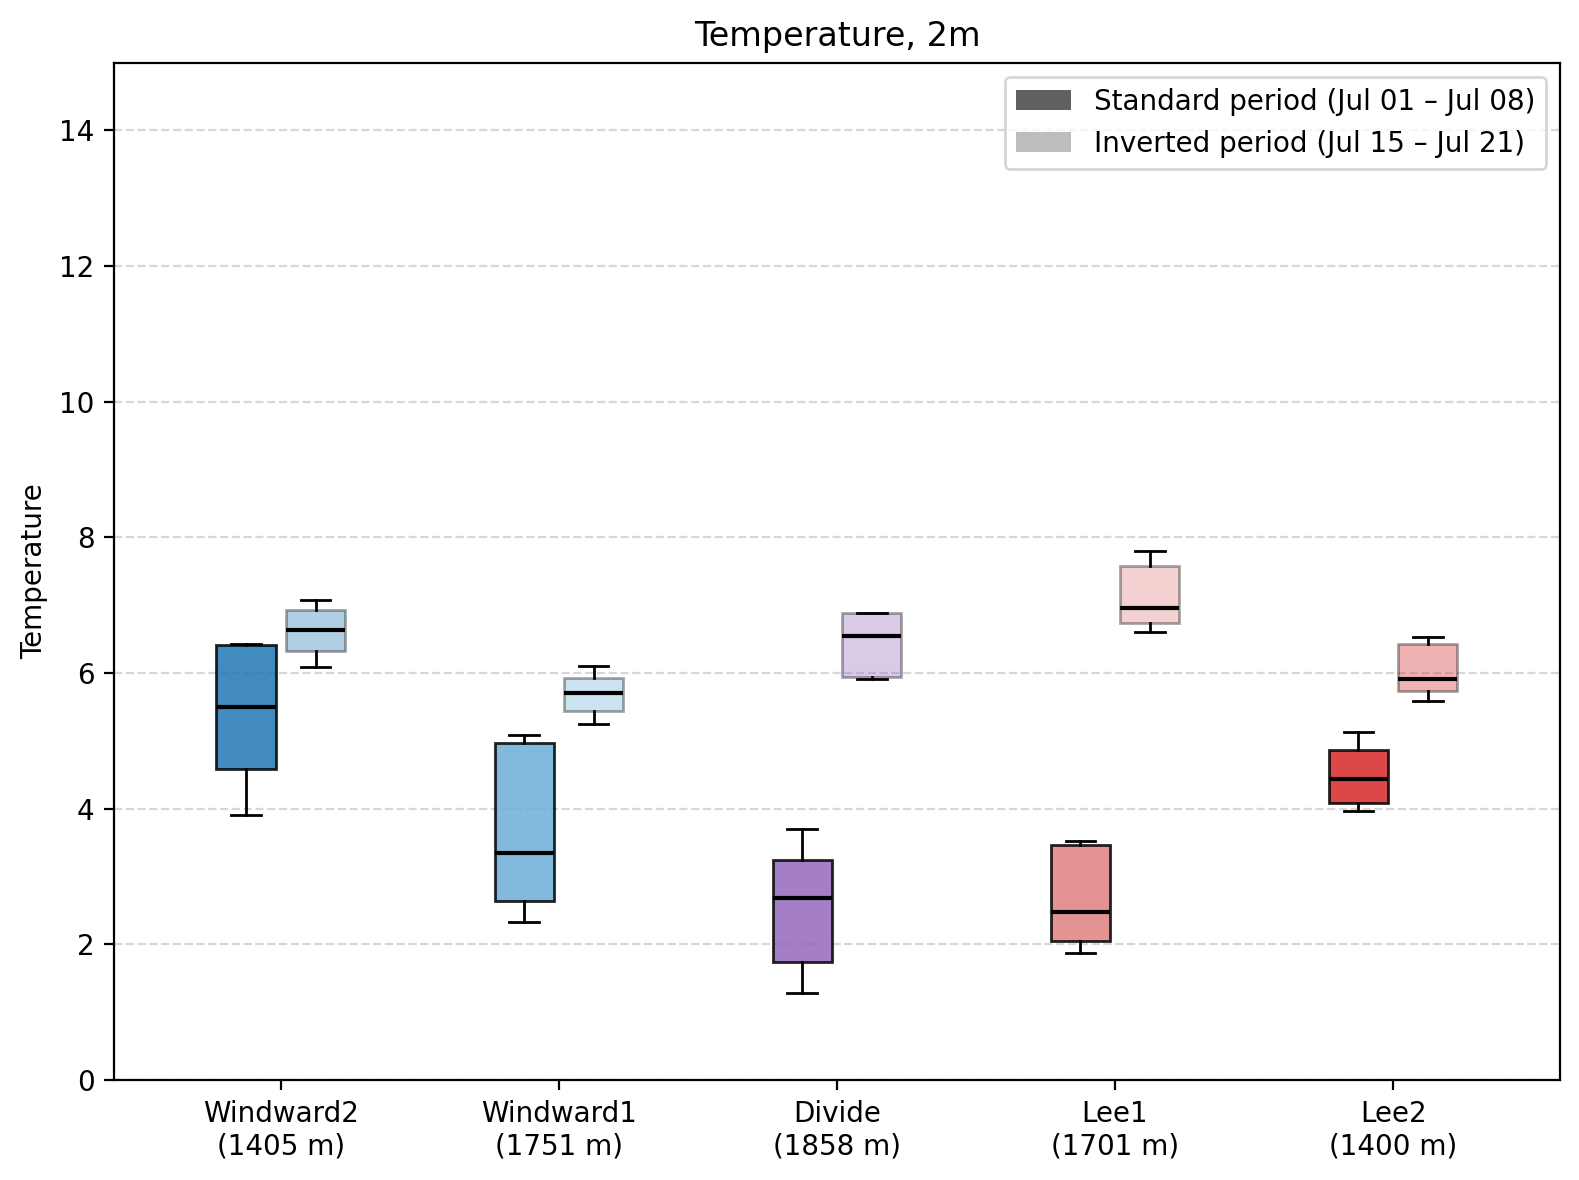

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide": "#9467bd",
    "Lee2": "#d62728",
    "Lee1": "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide": "Divide\n(1858 m)",
    "Lee2": "Lee2\n(1400 m)",
    "Lee1": "Lee1\n(1701 m)",
}

da_temp = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace")
da_diff = da_temp.sel(height="2m").resample({"datetime": "1D"}).mean()

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = da_diff.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals = da_diff.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(5, 95),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
        )

ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.set_ylim(0, 15)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax.legend(handles=legend_patches, loc="upper right")
ax.set_ylabel("Temperature")
ax.set_title("Temperature, 2m")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

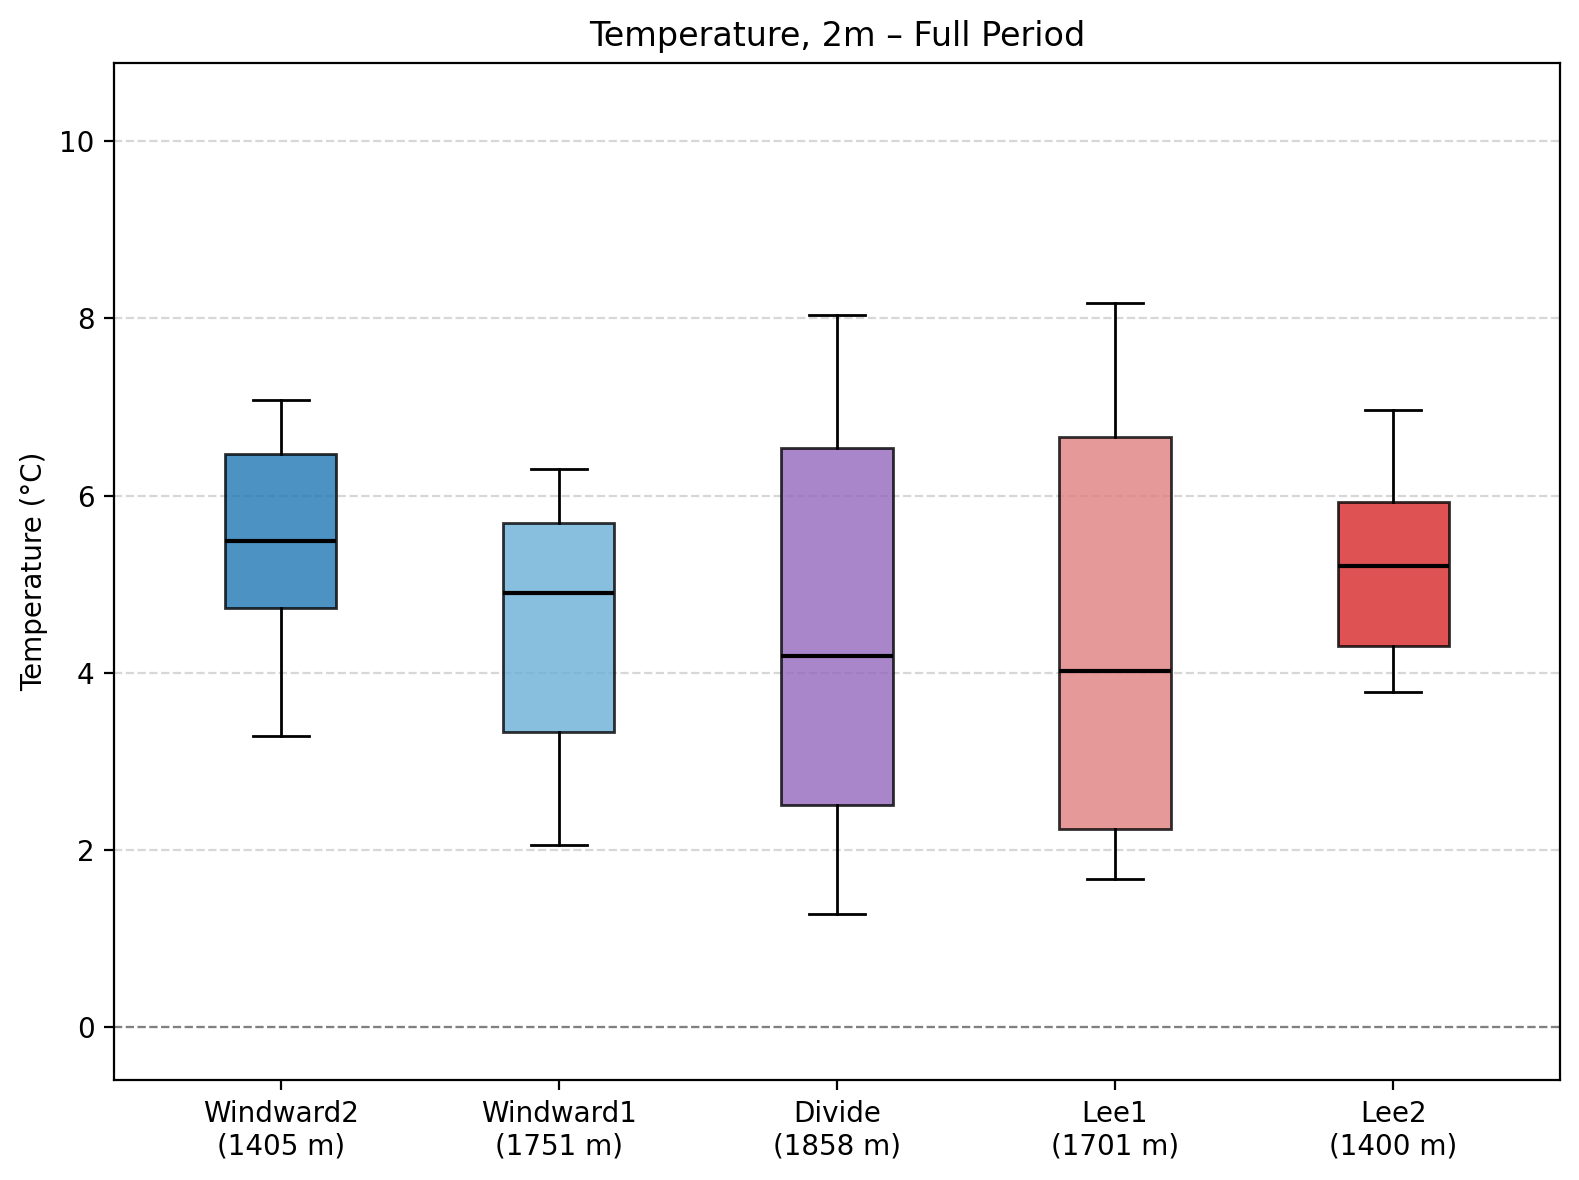

In [271]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee2":      "#d62728",
    "Lee1":      "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide":    "Divide\n(1858 m)",
    "Lee2":      "Lee2\n(1400 m)",
    "Lee1":      "Lee1\n(1701 m)",
}

da_temp  = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace")
da_daily = da_temp.sel(height="2m").resample({"datetime": "1D"}).mean()

width         = 0.4
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color  = site_colors[site_id]
    center = i * group_spacing

    vals = da_daily.sel(site_id=site_id).values
    vals = vals[~np.isnan(vals)]

    ax.boxplot(
        [vals],
        positions=[center],
        widths=width,
        patch_artist=True,
        manage_ticks=False,
        whis=(5, 95),
        boxprops=dict(facecolor=color, alpha=0.8),
        medianprops=dict(color="black", linewidth=1.5, zorder=5),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
    )

ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature, 2m – Full Period")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

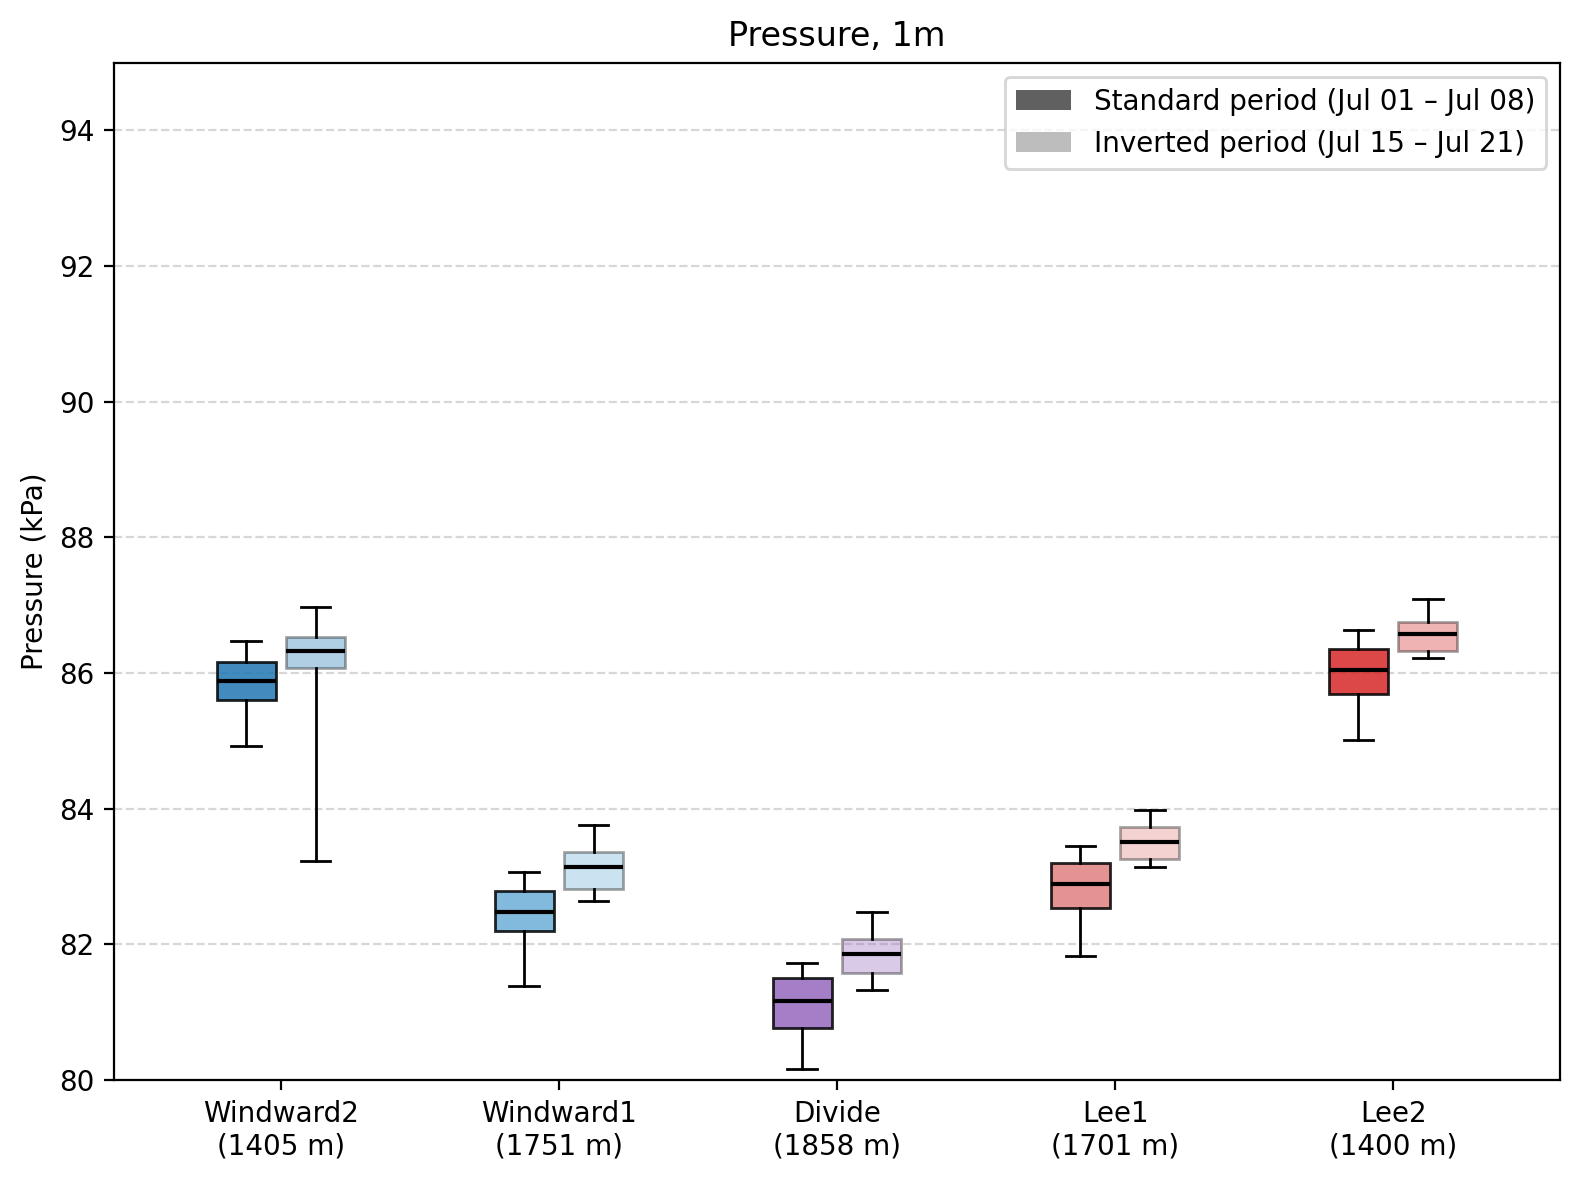

In [170]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide": "#9467bd",
    "Lee2": "#d62728",
    "Lee1": "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide": "Divide\n(1858 m)",
    "Lee2": "Lee2\n(1400 m)",
    "Lee1": "Lee1\n(1701 m)",
}

da_temp = ds["pressure"].sel(shielding="unshielded", sensor_type="pace")
da_diff = da_temp.sel(height="1m")

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = da_diff.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals = da_diff.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(5, 95),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
        )

ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.set_ylim(80, 95)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax.legend(handles=legend_patches)
ax.set_ylabel("Pressure (kPa)")
ax.set_title("Pressure, 1m")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

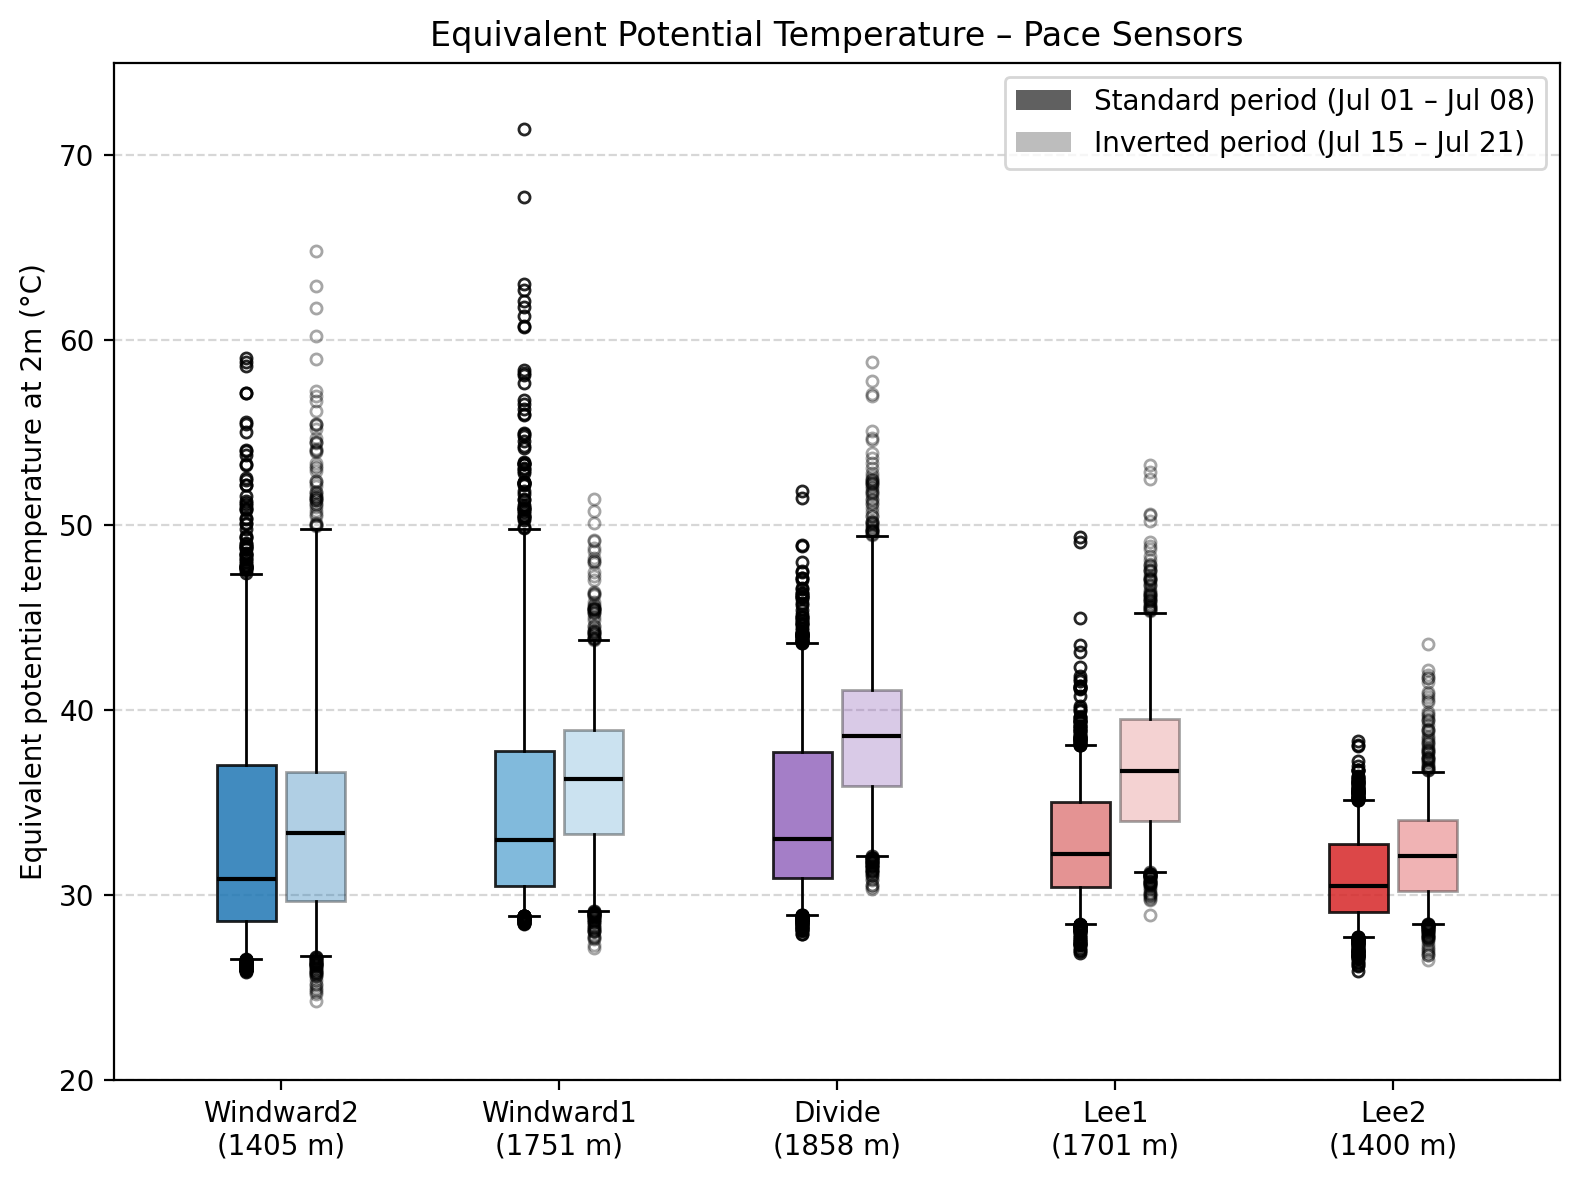

In [171]:
import metpy.calc as mpcalc
from metpy.units import units

def sel_with_units(da, unit_str, **sel_kwargs):
    da = da.sel(**sel_kwargs).copy()
    da.attrs["units"] = unit_str
    return da.metpy.quantify()

temp_2m     = sel_with_units(ds["temp_c"],            "degC",    height="2m", shielding="unshielded", sensor_type="pace")
rh_2m       = sel_with_units(ds["relative_humidity"], "percent", height="2m", shielding="unshielded", sensor_type="pace")
pressure_1m = sel_with_units(ds["pressure"],          "kPa",     height="1m", shielding="unshielded", sensor_type="pace")

dewpoint_2m = mpcalc.dewpoint_from_relative_humidity(temp_2m, rh_2m)
theta_e = mpcalc.equivalent_potential_temperature(pressure_1m, temp_2m, dewpoint_2m).metpy.convert_units("degC")

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = theta_e.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals  = theta_e.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals  = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(2.5, 97.5),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=alpha),
        )

ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax.set_ylim(20, 75)  # θe in °C; adjust to match your data range

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax.legend(handles=legend_patches)
ax.set_ylabel("Equivalent potential temperature at 2m (°C)")
ax.set_title("Equivalent Potential Temperature – Pace Sensors")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

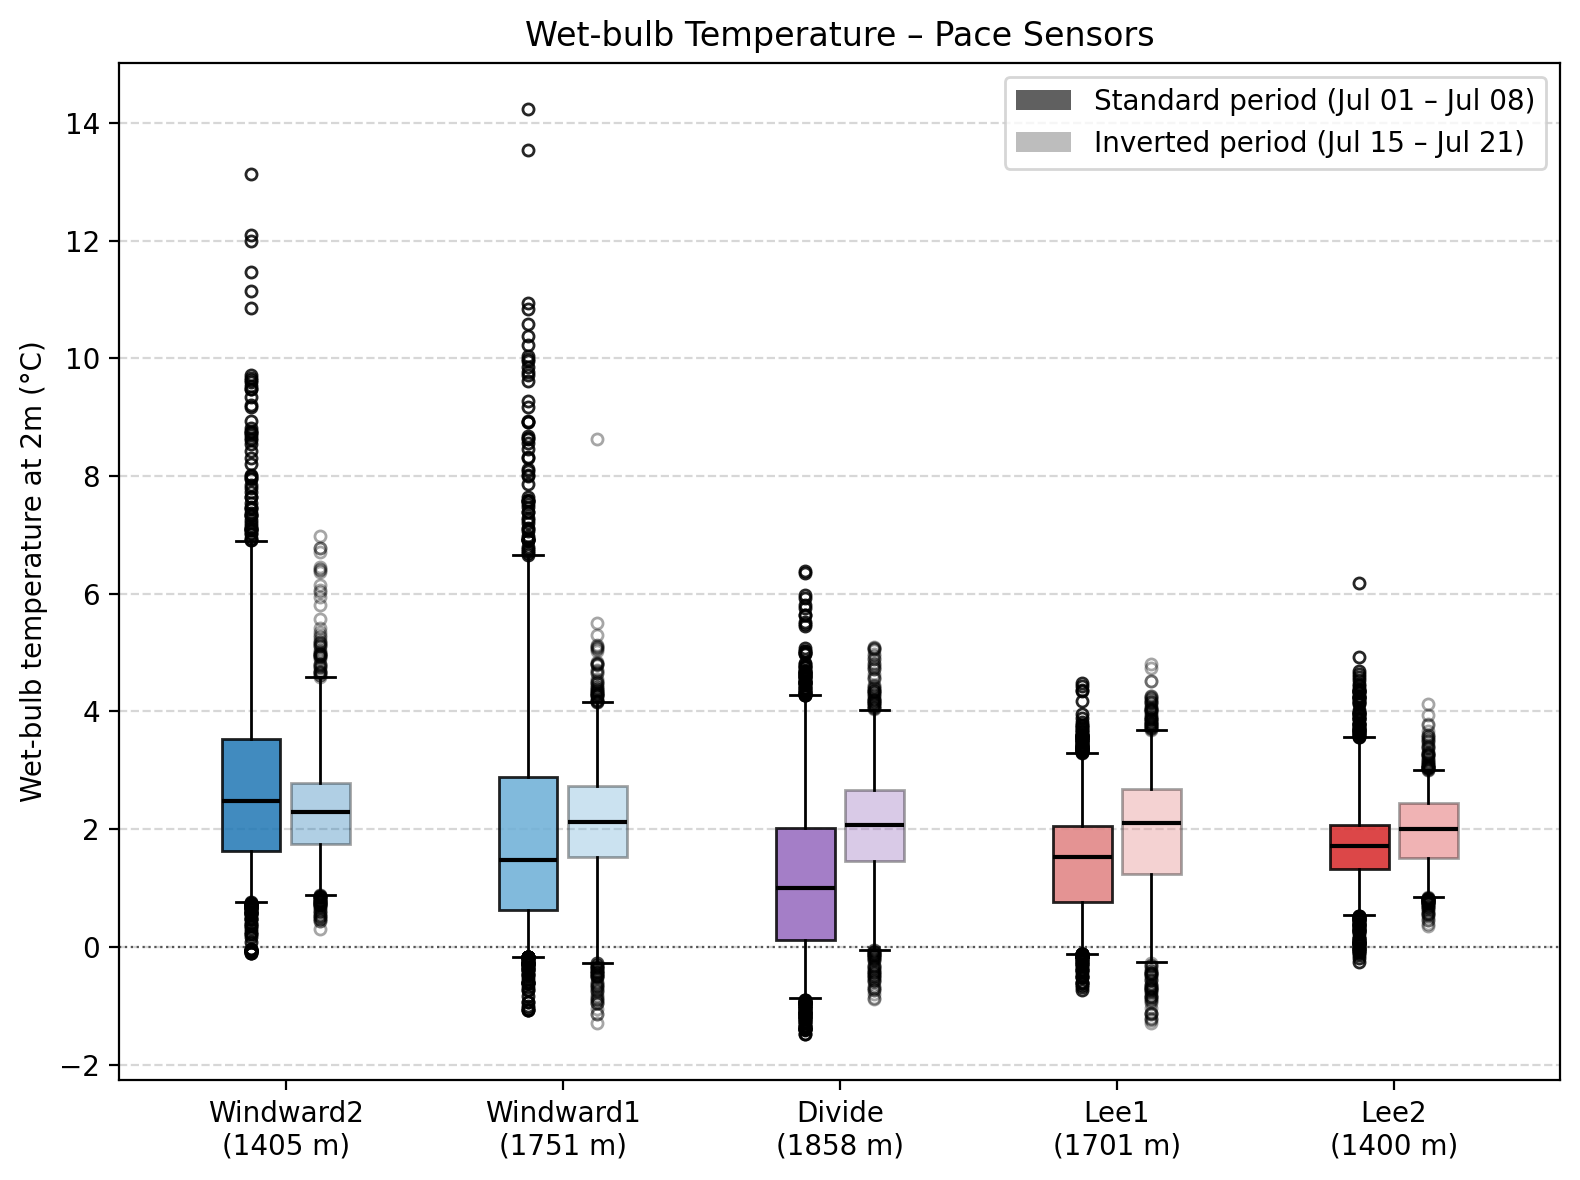

In [172]:
import metpy.calc as mpcalc
from metpy.units import units

def sel_with_units(da, unit_str, **sel_kwargs):
    da = da.sel(**sel_kwargs).copy()
    da.attrs["units"] = unit_str
    return da.metpy.quantify()

temp_2m     = sel_with_units(ds["temp_c"],            "degC",    height="2m", shielding="unshielded", sensor_type="pace")
rh_2m       = sel_with_units(ds["relative_humidity"], "percent", height="2m", shielding="unshielded", sensor_type="pace")
pressure_1m = sel_with_units(ds["pressure"],          "hPa",     height="1m", shielding="unshielded", sensor_type="pace")

dewpoint = mpcalc.dewpoint_from_relative_humidity(temp_2m, rh_2m)
tw = mpcalc.wet_bulb_temperature(pressure_1m, temp_2m, dewpoint).metpy.convert_units("degC")

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = tw.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals  = tw.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals  = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(2.5, 97.5),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=alpha),
        )

ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax.legend(handles=legend_patches)
ax.set_ylabel("Wet-bulb temperature at 2m (°C)")
ax.set_title("Wet-bulb Temperature – Pace Sensors")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

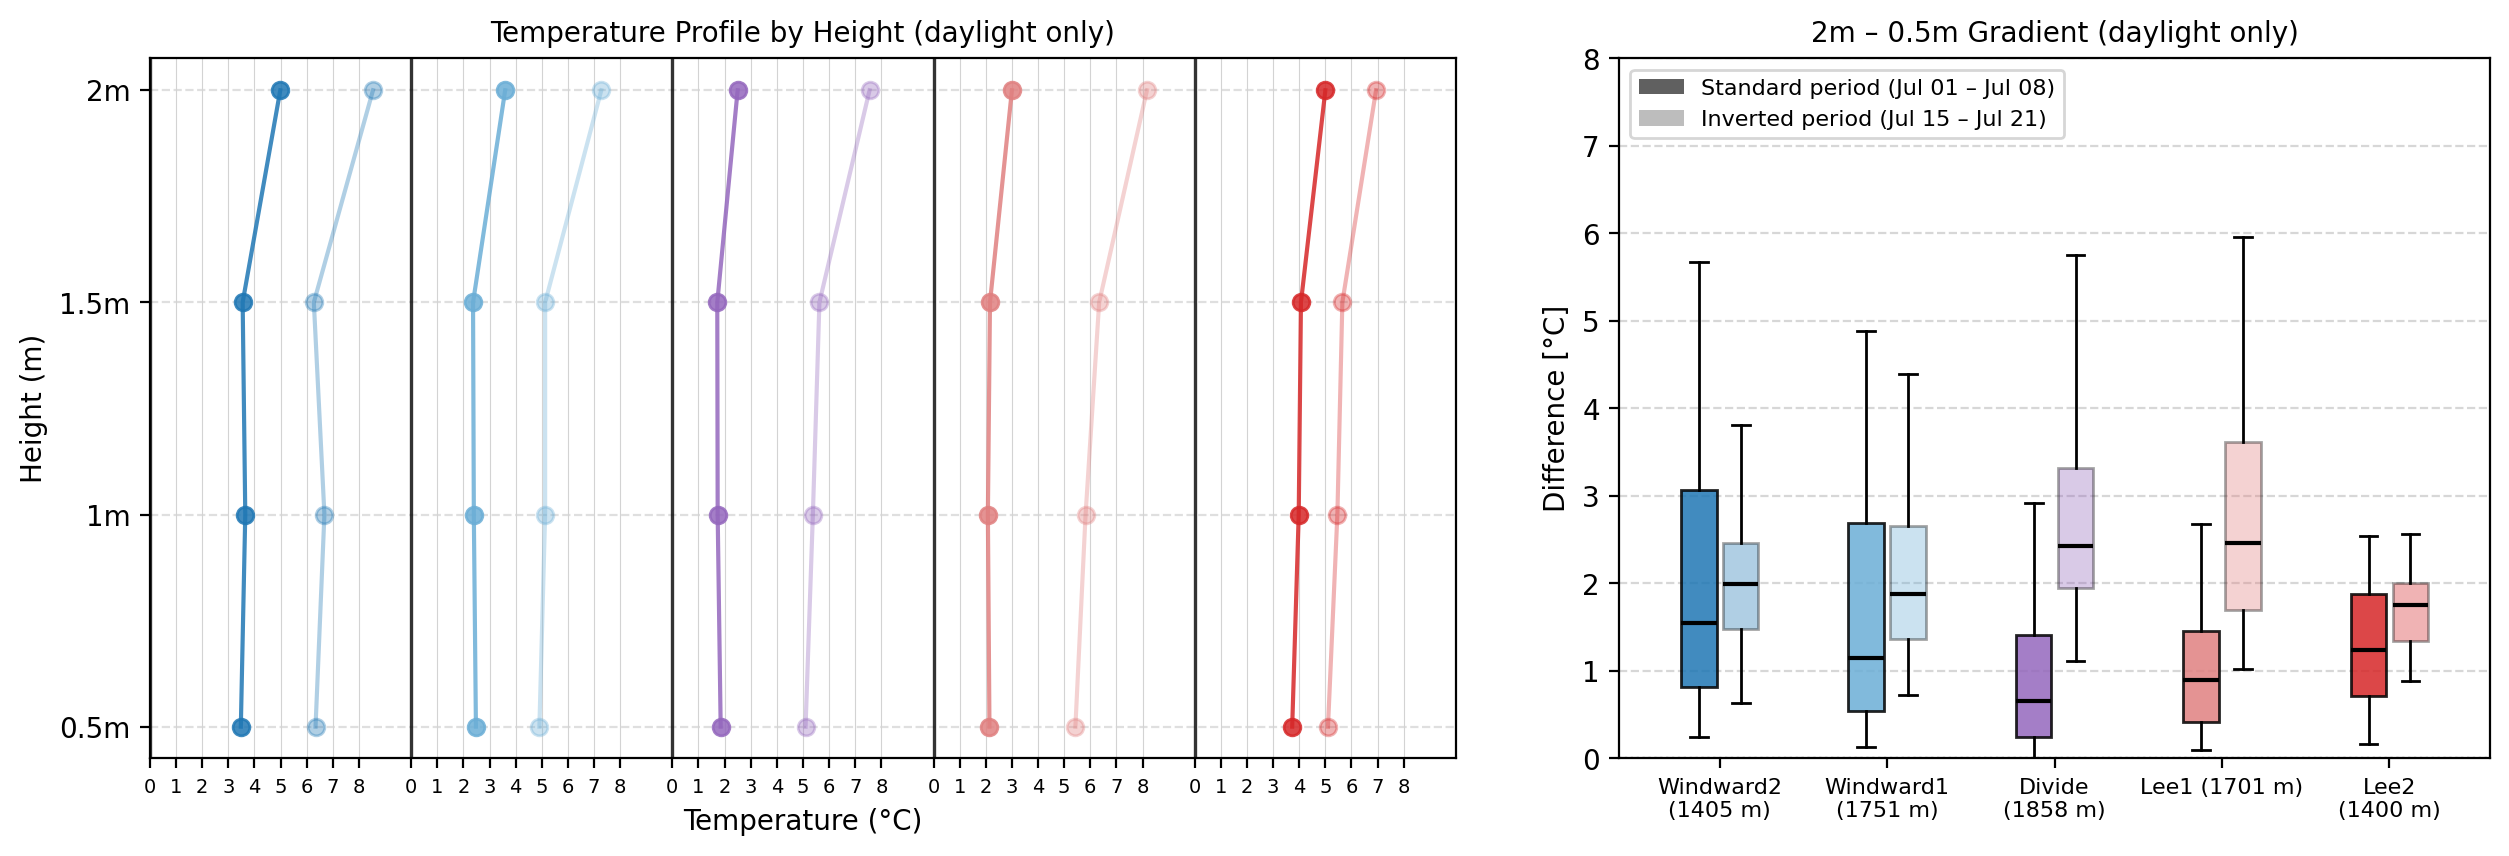

In [173]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from datetime import timezone, timedelta
import xarray as xr
from jiflr.utils import get_sunrise_sunset, lapse_rate_ufunc

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]
heights = ["0.5m", "1m", "1.5m", "2m"]
height_vals = [0.5, 1.0, 1.5, 2.0]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide": "#9467bd",
    "Lee2": "#d62728",
    "Lee1": "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide": "Divide\n(1858 m)",
    "Lee2": "Lee2\n(1400 m)",
    "Lee1": "Lee1 (1701 m)",
}

# ── Daylight mask ─────────────────────────────────────────────────────────────
da_temp = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace")

utc_offset = da_temp["datetime"].attrs["utc_offset_hours"]
tz = timezone(timedelta(hours=utc_offset))
dt_index = da_temp["datetime"].to_index().tz_localize(tz)

sun_df = get_sunrise_sunset(dt_index)
daylight_offset = pd.Timedelta(minutes=30)
is_daylight = (dt_index >= sun_df["sunrise"] + daylight_offset) & (dt_index <= sun_df["sunset"] - daylight_offset)
daylight_mask = xr.DataArray(
    is_daylight, coords={"datetime": da_temp.datetime}, dims=["datetime"]
)
da_temp = da_temp.where(daylight_mask)

# ── Derived diff (after masking) ──────────────────────────────────────────────
da_diff = da_temp.sel(height="2m") - da_temp.sel(height="0.5m")

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5), dpi=200)
gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[1.5, 1],
    wspace=0.15,
    left=0.07, right=0.97, top=0.88, bottom=0.18,
)

ax_line = fig.add_subplot(gs[0, 0])
ax_box = fig.add_subplot(gs[0, 1])

# ── Line plot (temperature profiles) ─────────────────────────────────────────
panel_width = 10
temp_ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8]
offsets = {site_id: i * panel_width for i, site_id in enumerate(site_ids)}

for site_id in site_ids:
    color = site_colors[site_id]
    offset = offsets[site_id]

    ax_line.axvline(offset, color="black", linewidth=1.2, linestyle="-", alpha=0.8, zorder=2)
    for delta in temp_ticks[1:]:
        ax_line.axvline(offset + delta, color="lightgray", linewidth=0.4)

    for period, period_slice in period_slices.items():
        alpha = period_alphas[period]
        medians = []
        for height in heights:
            try:
                vals = da_temp.sel(
                    site_id=site_id, height=height, datetime=period_slice
                ).values
                vals = vals[~np.isnan(vals)]
            except KeyError:
                vals = np.array([])
            medians.append(np.median(vals) if len(vals) > 0 else np.nan)

        ax_line.plot(
            [m + offset for m in medians],
            height_vals,
            color=color,
            alpha=alpha,
            marker="o",
            linewidth=1.5,
        )

all_tick_positions = [offsets[s] + t for s in site_ids for t in temp_ticks]
all_tick_labels = [str(t) for s in site_ids for t in temp_ticks]
ax_line.set_xticks(all_tick_positions)
ax_line.set_xticklabels(all_tick_labels, fontsize=7)
ax_line.set_xlim(0, offsets[site_ids[-1]] + panel_width)
ax_line.set_yticks(height_vals)
ax_line.set_yticklabels(heights)
ax_line.set_ylabel("Height (m)")
ax_line.set_xlabel("Temperature (°C)")
ax_line.set_title("Temperature Profile by Height (daylight only)", fontsize=10)
ax_line.grid(axis="y", linestyle="--", alpha=0.4)

# ── Boxplot (2m – 0.5m gradient) ─────────────────────────────────────────────
width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = da_diff.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals = da_diff.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax_box.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(5, 95),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
        )

ax_box.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.6)
ax_box.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax_box.set_xticklabels([site_labels[s] for s in site_ids], fontsize=8)
ax_box.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax_box.set_ylim(0, 8)
ax_box.set_ylabel("Difference [°C]")
ax_box.set_title("2m – 0.5m Gradient (daylight only)", fontsize=10)
ax_box.grid(axis="y", linestyle="--", alpha=0.5)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax_box.legend(handles=legend_patches, fontsize=8, loc="best")

plt.show()

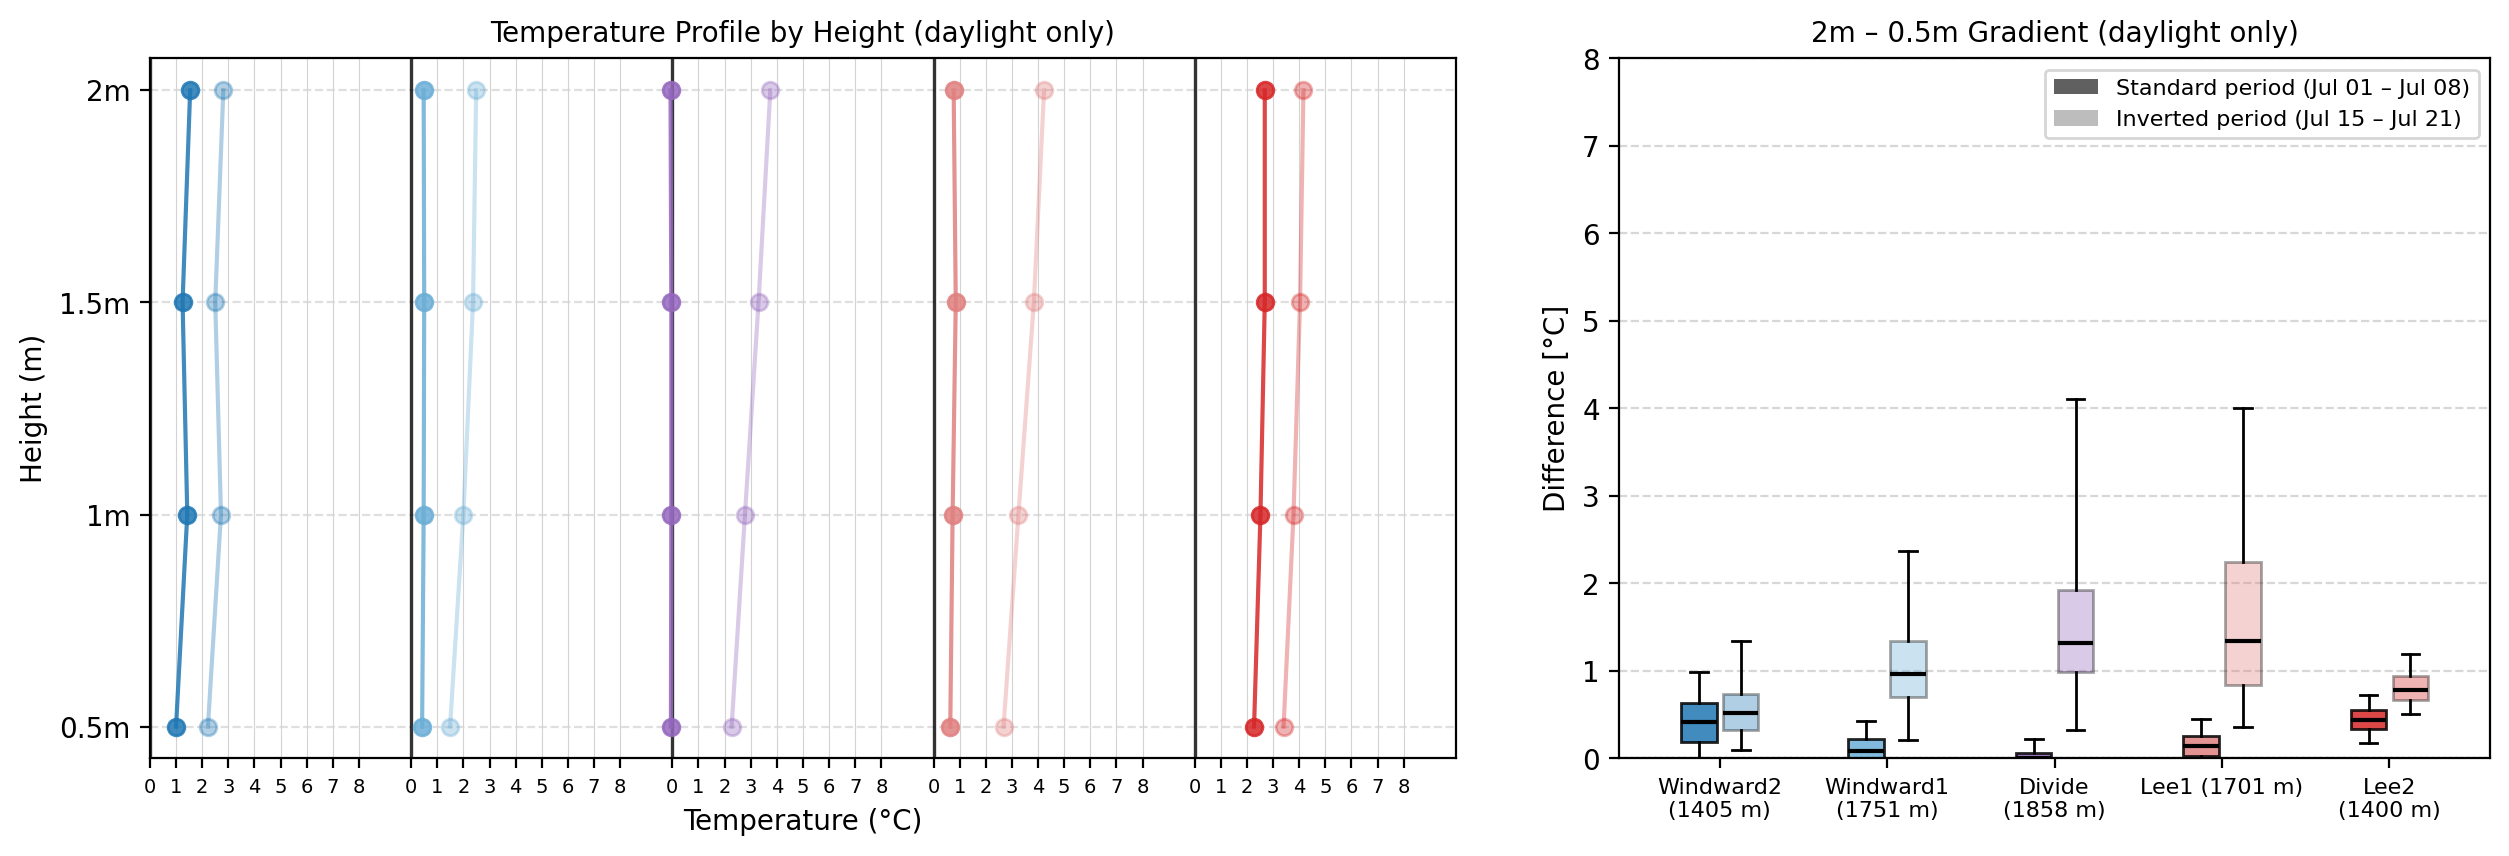

In [174]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from datetime import timezone, timedelta
import xarray as xr
from jiflr.utils import get_sunrise_sunset, lapse_rate_ufunc

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]
heights = ["0.5m", "1m", "1.5m", "2m"]
height_vals = [0.5, 1.0, 1.5, 2.0]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide": "#9467bd",
    "Lee2": "#d62728",
    "Lee1": "#e08080",
}
site_labels = {
    "Windward2": "Windward2\n(1405 m)",
    "Windward1": "Windward1\n(1751 m)",
    "Divide": "Divide\n(1858 m)",
    "Lee2": "Lee2\n(1400 m)",
    "Lee1": "Lee1 (1701 m)",
}

# ── Daylight mask ─────────────────────────────────────────────────────────────
da_temp = ds["temp_c"].sel(shielding="unshielded", sensor_type="pace")

utc_offset = da_temp["datetime"].attrs["utc_offset_hours"]
tz = timezone(timedelta(hours=utc_offset))
dt_index = da_temp["datetime"].to_index().tz_localize(tz)

sun_df = get_sunrise_sunset(dt_index)
daylight_offset = pd.Timedelta(minutes=30)
is_daylight = (dt_index >= sun_df["sunrise"] + daylight_offset) & (dt_index <= sun_df["sunset"] - daylight_offset)
daylight_mask = xr.DataArray(
    ~is_daylight, coords={"datetime": da_temp.datetime}, dims=["datetime"]
)
da_temp = da_temp.where(daylight_mask)

# ── Derived diff (after masking) ──────────────────────────────────────────────
da_diff = da_temp.sel(height="2m") - da_temp.sel(height="0.5m")

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5), dpi=200)
gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[1.5, 1],
    wspace=0.15,
    left=0.07, right=0.97, top=0.88, bottom=0.18,
)

ax_line = fig.add_subplot(gs[0, 0])
ax_box = fig.add_subplot(gs[0, 1])

# ── Line plot (temperature profiles) ─────────────────────────────────────────
panel_width = 10
temp_ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8]
offsets = {site_id: i * panel_width for i, site_id in enumerate(site_ids)}

for site_id in site_ids:
    color = site_colors[site_id]
    offset = offsets[site_id]

    ax_line.axvline(offset, color="black", linewidth=1.2, linestyle="-", alpha=0.8, zorder=2)
    for delta in temp_ticks[1:]:
        ax_line.axvline(offset + delta, color="lightgray", linewidth=0.4)

    for period, period_slice in period_slices.items():
        alpha = period_alphas[period]
        medians = []
        for height in heights:
            try:
                vals = da_temp.sel(
                    site_id=site_id, height=height, datetime=period_slice
                ).values
                vals = vals[~np.isnan(vals)]
            except KeyError:
                vals = np.array([])
            medians.append(np.median(vals) if len(vals) > 0 else np.nan)

        ax_line.plot(
            [m + offset for m in medians],
            height_vals,
            color=color,
            alpha=alpha,
            marker="o",
            linewidth=1.5,
        )

all_tick_positions = [offsets[s] + t for s in site_ids for t in temp_ticks]
all_tick_labels = [str(t) for s in site_ids for t in temp_ticks]
ax_line.set_xticks(all_tick_positions)
ax_line.set_xticklabels(all_tick_labels, fontsize=7)
ax_line.set_xlim(0, offsets[site_ids[-1]] + panel_width)
ax_line.set_yticks(height_vals)
ax_line.set_yticklabels(heights)
ax_line.set_ylabel("Height (m)")
ax_line.set_xlabel("Temperature (°C)")
ax_line.set_title("Temperature Profile by Height (daylight only)", fontsize=10)
ax_line.grid(axis="y", linestyle="--", alpha=0.4)

# ── Boxplot (2m – 0.5m gradient) ─────────────────────────────────────────────
width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = da_diff.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals = da_diff.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
    ):
        ax_box.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(5, 95),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=0),
        )

ax_box.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.6)
ax_box.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax_box.set_xticklabels([site_labels[s] for s in site_ids], fontsize=8)
ax_box.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)
ax_box.set_ylim(0, 8)
ax_box.set_ylabel("Difference [°C]")
ax_box.set_title("2m – 0.5m Gradient (daylight only)", fontsize=10)
ax_box.grid(axis="y", linestyle="--", alpha=0.5)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax_box.legend(handles=legend_patches, fontsize=8, loc="best")

plt.show()

Windward2
Windward1
Divide
Lee1
Lee2


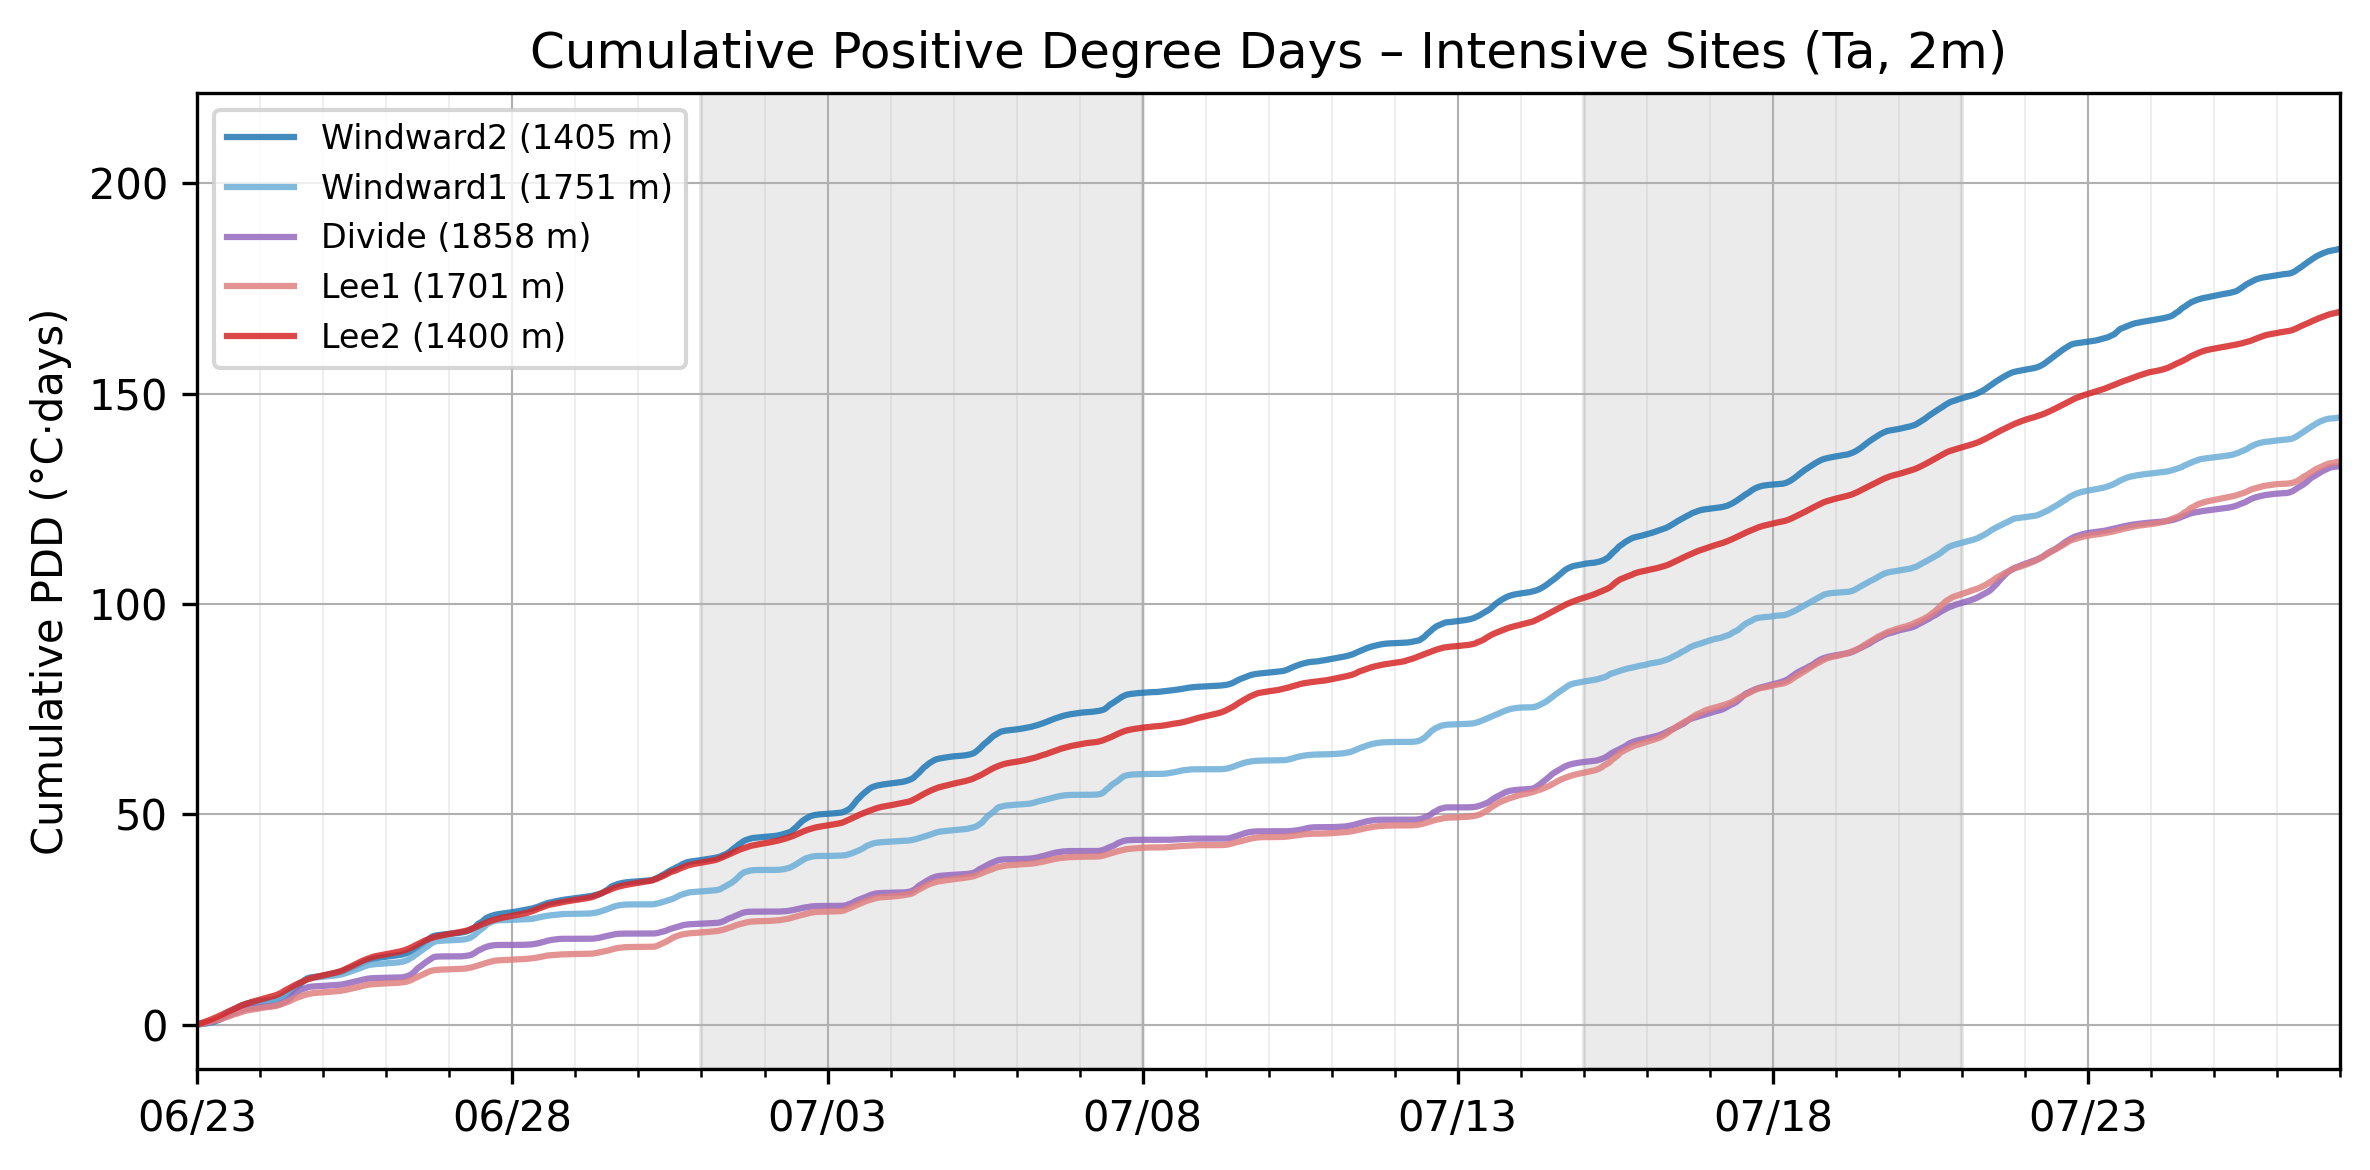

In [184]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide": "#9467bd",
    "Lee1": "#e08080",
    "Lee2": "#d62728",
}

site_labels = {
    "Windward2": "Windward2 (1405 m)",
    "Windward1": "Windward1 (1751 m)",
    "Divide": "Divide (1858 m)",
    "Lee1": "Lee1 (1701 m)",
    "Lee2": "Lee2 (1400 m)",
}

start_date = "2025-06-23"
da_temp = ds["temp_c"].sel(
    height="2m",
    shielding="unshielded",
    sensor_type="pace",
    datetime=slice(start_date, None),
)

samples_per_day = 288  # 5-minute data

fig, ax = plt.subplots(dpi=300, figsize=(8, 4))

for site_id in site_ids:
    print(site_id)
    try:
        temp = da_temp.sel(site_id=site_id).values
    except KeyError:
        continue
    pdd_cumsum = np.nancumsum(np.maximum(temp, 0) / samples_per_day)
    ax.plot(
        da_temp.datetime,
        pdd_cumsum,
        lw=1.5,
        alpha=0.85,
        color=site_colors[site_id],
        label=site_labels[site_id],
    )

ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.1)
ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.1)

ax.legend(fontsize=8, loc="upper left")
ax.set_ylabel("Cumulative PDD (°C·days)")
ax.set_xlabel("")
ax.set_title("Cumulative Positive Degree Days – Intensive Sites (Ta, 2m)")
ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%m/%d"))
ax.set_xlim(pd.Timestamp("2025-06-23"), pd.Timestamp("2025-07-27"))
ax.grid(which="minor", lw=0.1)
ax.grid(which="major", lw=0.5)
plt.tight_layout()
plt.show()

Windward2: θv threshold = 566.14 K
Windward1: θv threshold = 572.71 K
Divide: θv threshold = 575.58 K
Lee1: θv threshold = 571.95 K
Lee2: θv threshold = 565.23 K


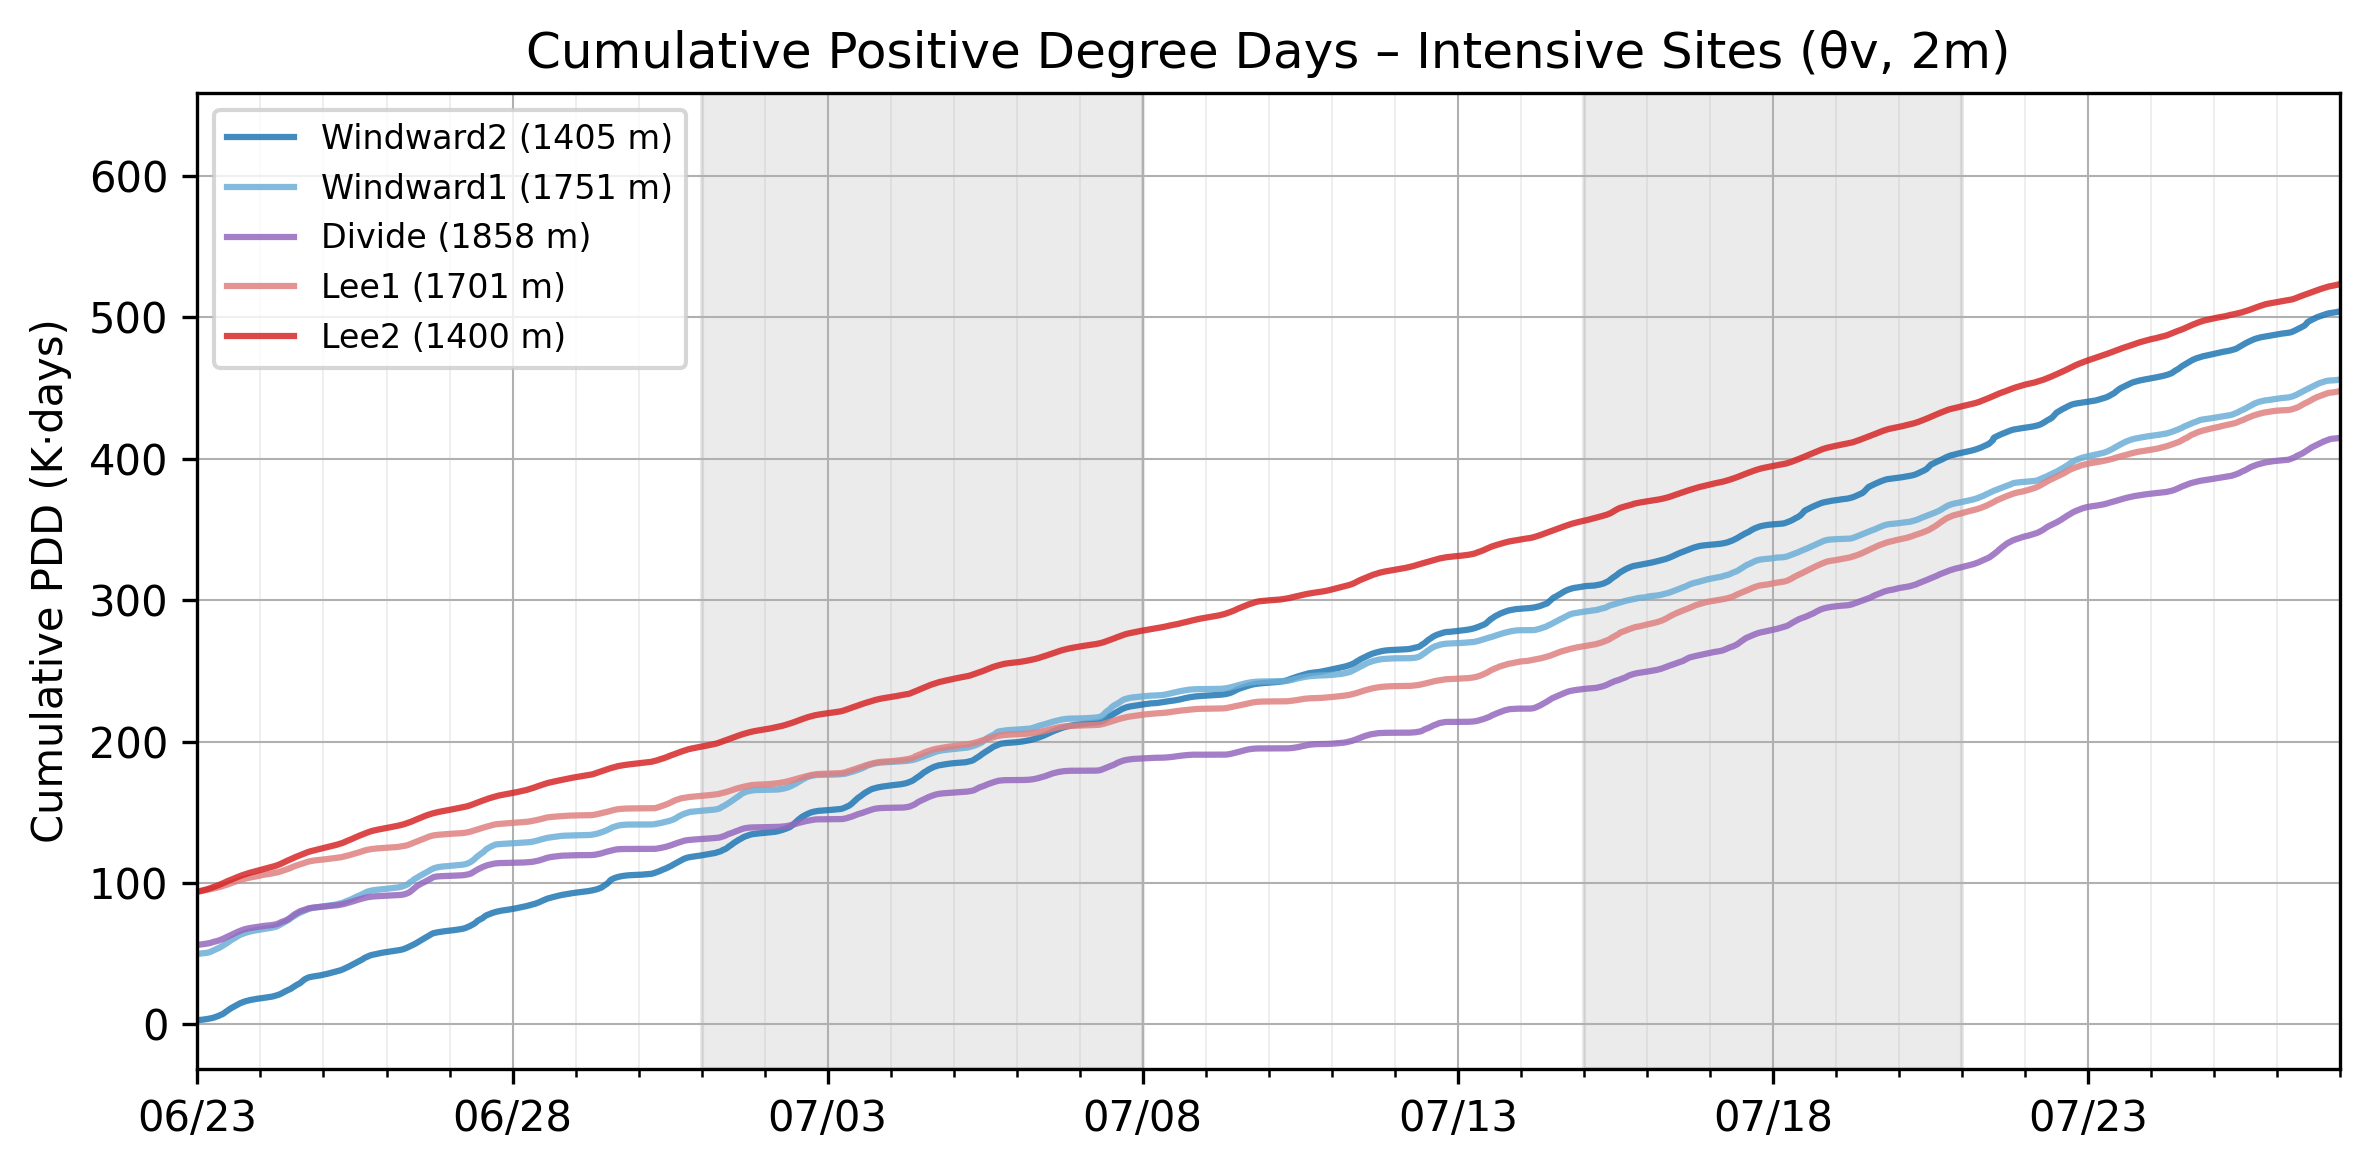

In [176]:
mixing_ratio = mpcalc.mixing_ratio_from_relative_humidity(pressure_1m, temp_2m, rh_2m)
theta_v = mpcalc.virtual_potential_temperature(pressure_1m, temp_2m, mixing_ratio)  # stays in Kelvin

# Site-specific θv threshold: saturated parcel at 0°C, in Kelvin
thresholds = {}
for site_id in site_ids:
    p_mean = pressure_1m.sel(site_id=site_id).mean().values * units.hPa
    t_freeze = 0.0 * units.degC
    rh_sat = 100.0 * units.percent
    r_sat = mpcalc.mixing_ratio_from_relative_humidity(p_mean, t_freeze, rh_sat)
    tv_thresh = mpcalc.virtual_potential_temperature(p_mean, t_freeze, r_sat).to("kelvin").magnitude
    thresholds[site_id] = tv_thresh
    print(f"{site_id}: θv threshold = {tv_thresh:.2f} K")

fig, ax = plt.subplots(dpi=300, figsize=(8, 4))

for site_id in site_ids:
    try:
        tv = theta_v.sel(site_id=site_id).values
    except KeyError:
        continue
    thresh = thresholds[site_id]
    pdd_cumsum = np.nancumsum(np.maximum(tv - thresh, 0) / samples_per_day)
    ax.plot(
        theta_v.datetime,
        pdd_cumsum,
        lw=1.5,
        alpha=0.85,
        color=site_colors[site_id],
        label=site_labels[site_id],
    )

ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.1)
ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.1)

ax.legend(fontsize=8, loc="upper left")
ax.set_ylabel("Cumulative PDD (K·days)")
ax.set_xlabel("")
ax.set_title("Cumulative Positive Degree Days – Intensive Sites (θv, 2m)")
ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%m/%d"))
ax.set_xlim(pd.Timestamp("2025-06-23"), pd.Timestamp("2025-07-27"))
ax.grid(which="minor", lw=0.1)
ax.grid(which="major", lw=0.5)
plt.tight_layout()
plt.show()

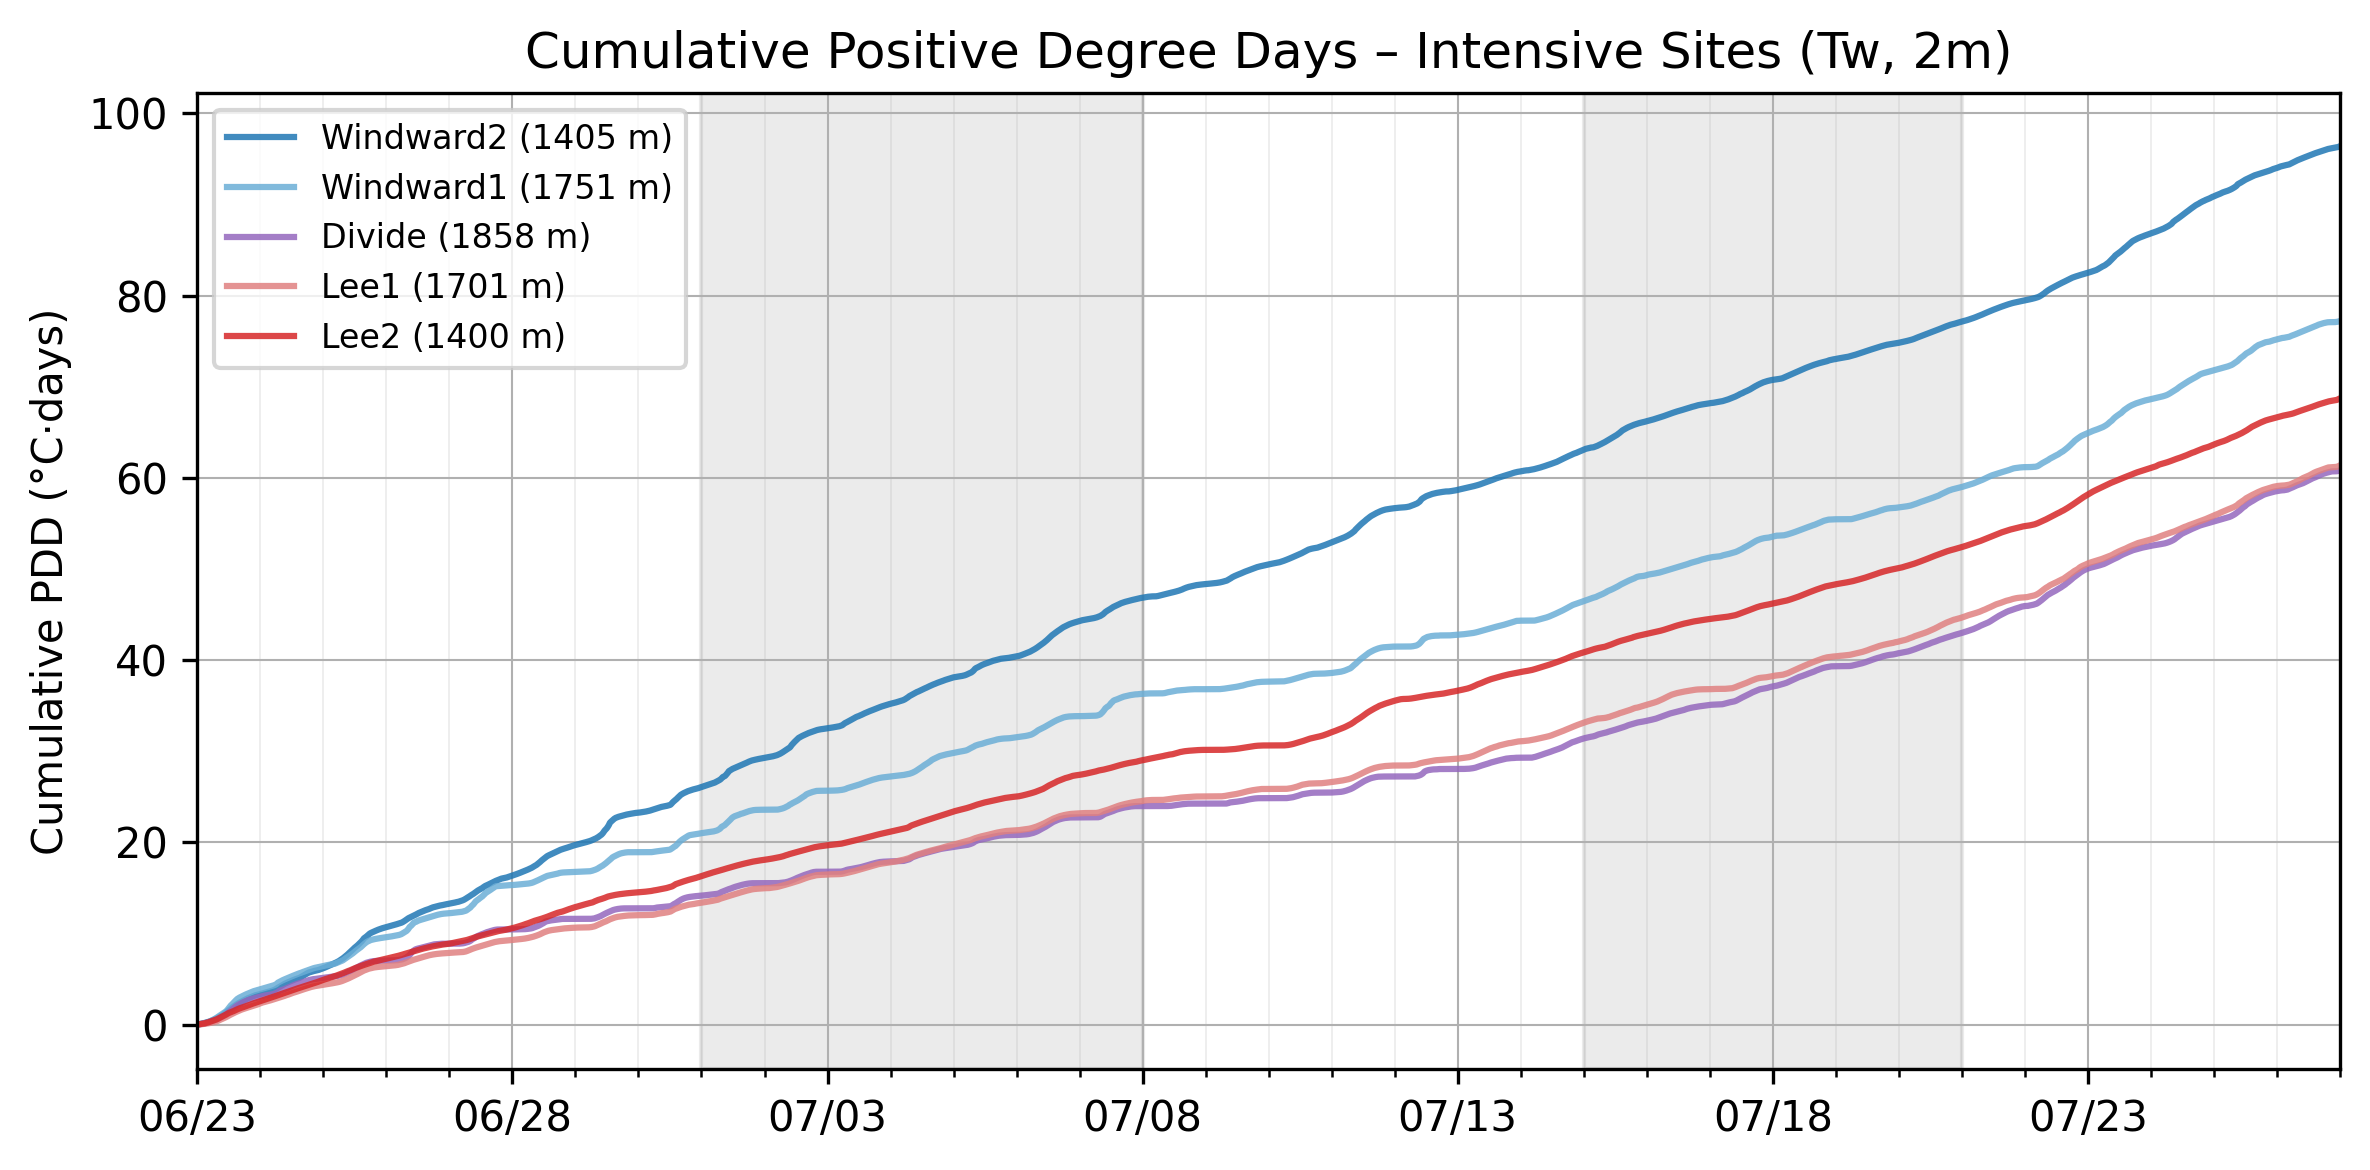

In [177]:
start_date = "2025-06-23"

temp_2m     = sel_with_units(ds["temp_c"],            "degC",    height="2m", shielding="unshielded", sensor_type="pace", datetime=slice(start_date, None))
rh_2m       = sel_with_units(ds["relative_humidity"], "percent", height="2m", shielding="unshielded", sensor_type="pace", datetime=slice(start_date, None))
pressure_1m = sel_with_units(ds["pressure"],          "hPa",     height="1m", shielding="unshielded", sensor_type="pace", datetime=slice(start_date, None))

dewpoint = mpcalc.dewpoint_from_relative_humidity(temp_2m, rh_2m)
tw = mpcalc.wet_bulb_temperature(pressure_1m, temp_2m, dewpoint).metpy.convert_units("degC")

samples_per_day = 288  # 5-minute data

fig, ax = plt.subplots(dpi=300, figsize=(8, 4))

for site_id in site_ids:
    try:
        tw_site = tw.sel(site_id=site_id).values
    except KeyError:
        continue
    pdd_cumsum = np.nancumsum(np.maximum(tw_site, 0) / samples_per_day)
    ax.plot(
        tw.datetime,
        pdd_cumsum,
        lw=1.5,
        alpha=0.85,
        color=site_colors[site_id],
        label=site_labels[site_id],
    )

ax.axvspan(pd.Timestamp(period_slices["standard"].start), pd.Timestamp(period_slices["standard"].stop), color="#444444", alpha=0.1)
ax.axvspan(pd.Timestamp(period_slices["inverted"].start), pd.Timestamp(period_slices["inverted"].stop), color="#444444", alpha=0.1)

ax.legend(fontsize=8, loc="upper left")
ax.set_ylabel("Cumulative PDD (°C·days)")
ax.set_xlabel("")
ax.set_title("Cumulative Positive Degree Days – Intensive Sites (Tw, 2m)")
ax.xaxis.set_major_locator(mpl.dates.DayLocator(interval=5))
ax.xaxis.set_minor_locator(mpl.dates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%m/%d"))
ax.set_xlim(pd.Timestamp("2025-06-23"), pd.Timestamp("2025-07-27"))
ax.grid(which="minor", lw=0.1)
ax.grid(which="major", lw=0.5)
plt.tight_layout()
plt.show()

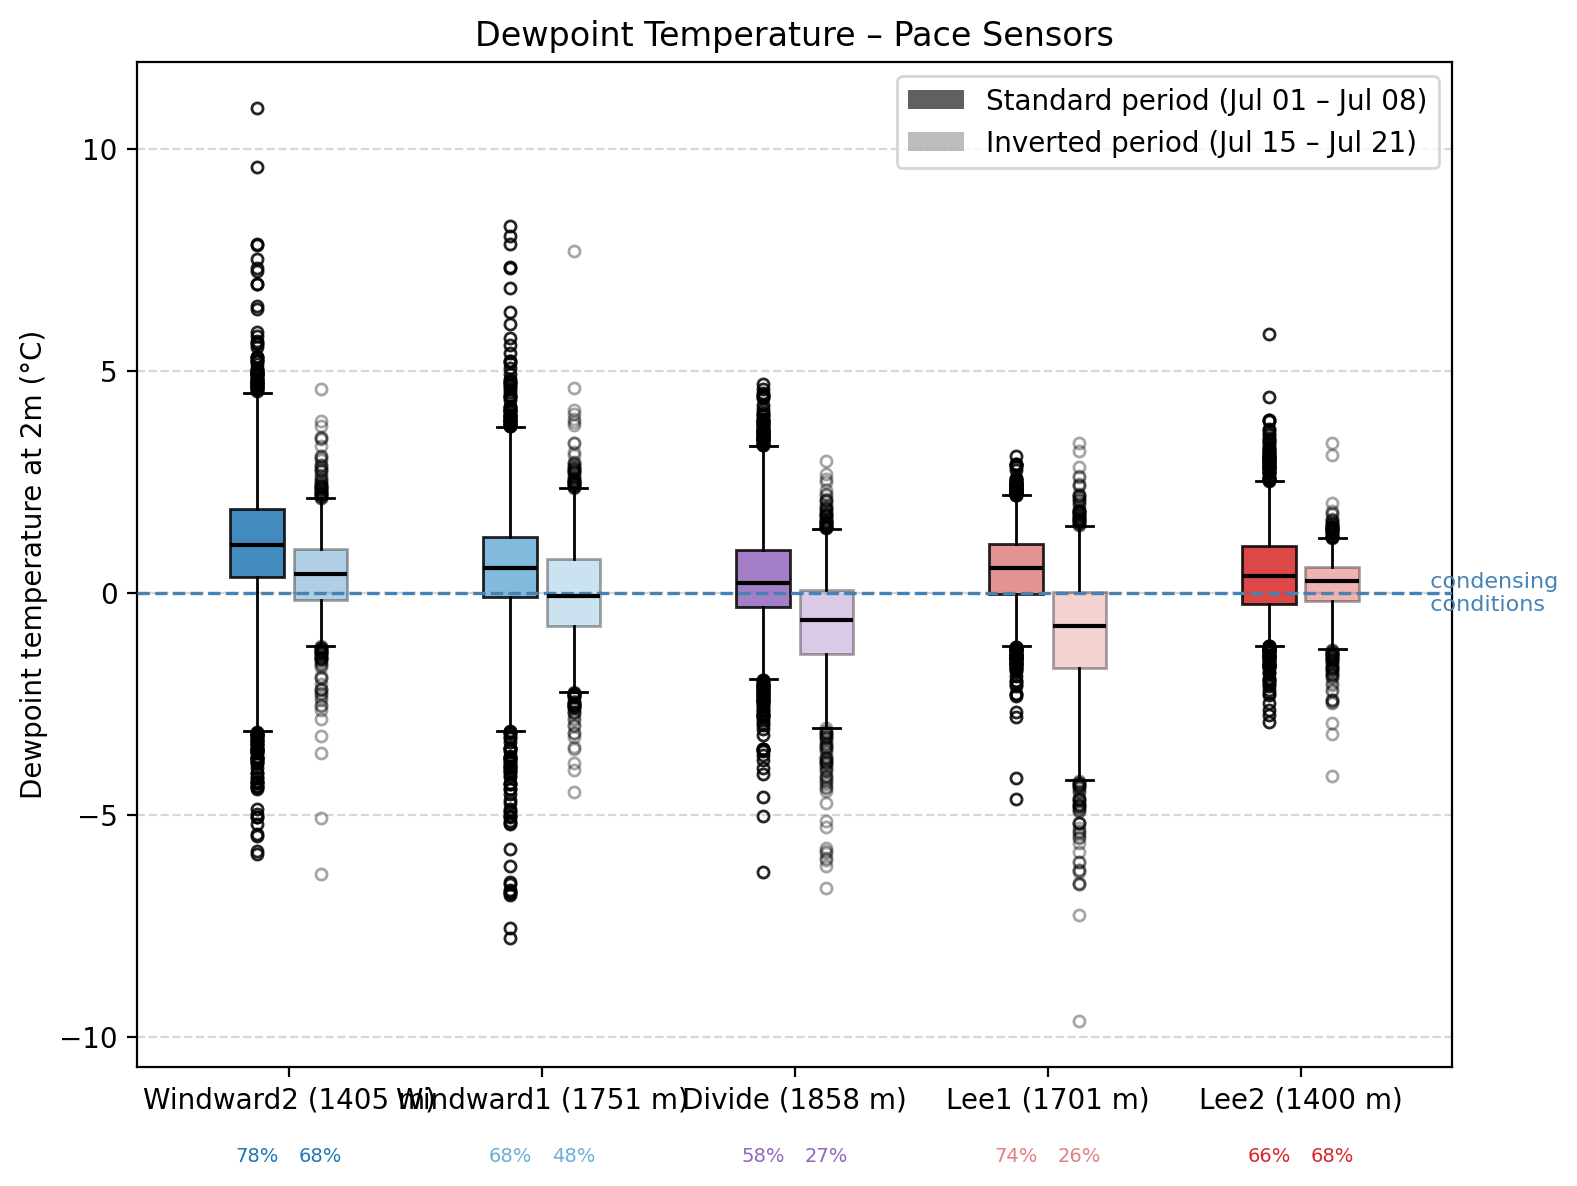

In [178]:
temp_2m = sel_with_units(ds["temp_c"],            "degC",    height="0.5m", shielding="unshielded", sensor_type="pace")
rh_2m   = sel_with_units(ds["relative_humidity"], "percent", height="2m", shielding="unshielded", sensor_type="pace")

dewpoint_2m = mpcalc.dewpoint_from_relative_humidity(temp_2m, rh_2m)

from matplotlib.transforms import blended_transform_factory

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

width = 0.25
group_spacing = 1.0

for i, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    center = i * group_spacing

    stab_vals = dewpoint_2m.sel(site_id=site_id, datetime=period_slices["standard"]).values
    inv_vals  = dewpoint_2m.sel(site_id=site_id, datetime=period_slices["inverted"]).values
    stab_vals = stab_vals[~np.isnan(stab_vals)]
    inv_vals  = inv_vals[~np.isnan(inv_vals)]

    for vals, offset, alpha, period_key in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        [period_alphas["standard"], period_alphas["inverted"]],
        ["standard", "inverted"],
    ):
        ax.boxplot(
            [vals],
            positions=[center + offset],
            widths=width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(2.5, 97.5),
            boxprops=dict(facecolor=color, alpha=alpha),
            medianprops=dict(color="black", linewidth=1.5, zorder=5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color=color, markersize=4, alpha=alpha),
        )

    # % of time condensing (Td > 0°C) for each period, shown below x-axis
    for vals, offset, period_key in zip(
        [stab_vals, inv_vals],
        [-width / 2, width / 2],
        ["standard", "inverted"],
    ):
        pct = 100 * np.mean(vals > 0)
        ax.text(
            center + offset, -0.08,
            f"{pct:.0f}%",
            transform=blended_transform_factory(ax.transData, ax.transAxes),
            ha="center", va="top",
            fontsize=7,
            color=site_colors[site_id],
        )

# Horizontal line at Td = 0°C
ax.axhline(0, color="steelblue", linewidth=1.2, linestyle="--", zorder=3)
ax.text(
    ax.get_xlim()[1], 0,
    "  condensing\n  conditions",
    va="center", ha="left", fontsize=8, color="steelblue",
)

ax.set_xticks([i * group_spacing for i in range(len(site_ids))])
ax.set_xticklabels([site_labels[s] for s in site_ids], fontsize=10)
ax.set_xlim(-0.6, (len(site_ids) - 1) * group_spacing + 0.6)

legend_patches = [
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["standard"], label=period_labels["standard"]),
    mpatches.Patch(facecolor="#444444", alpha=period_alphas["inverted"], label=period_labels["inverted"]),
]
ax.legend(handles=legend_patches)
ax.set_ylabel("Dewpoint temperature at 2m (°C)")
ax.set_title("Dewpoint Temperature – Pace Sensors")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

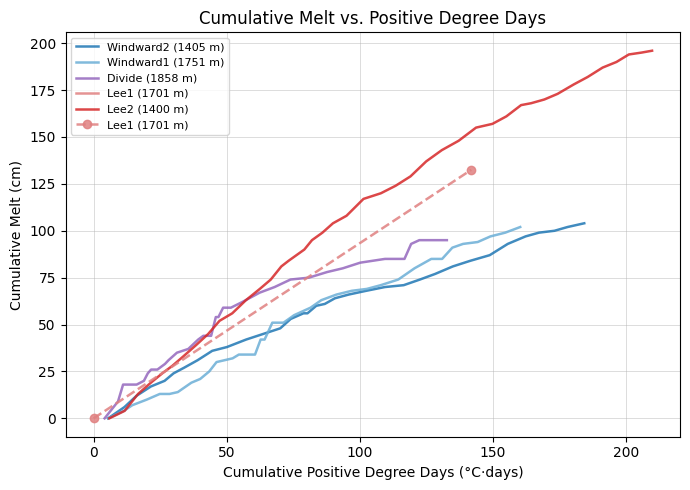

In [220]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee1":      "#e08080",
    "Lee2":      "#d62728",
}

site_labels = {
    "Windward2": "Windward2 (1405 m)",
    "Windward1": "Windward1 (1751 m)",
    "Divide":    "Divide (1858 m)",
    "Lee1":      "Lee1 (1701 m)",
    "Lee2":      "Lee2 (1400 m)",
}

start_date = "2025-06-23"

# ── Temperature → cumulative PDD (one value per 5-min timestep) ───────────────
da_temp = ds["temp_c"].sel(
    height="2m",
    shielding="unshielded",
    sensor_type="pace",
    datetime=slice(start_date, None),
)

# Resample to daily mean, then accumulate positive values
samples_per_day = 288  # 5-min data
da_temp_daily = da_temp.where(da_temp > 0).resample(datetime="1D").sum(min_count=1) / samples_per_day

fig, ax = plt.subplots(dpi=100, figsize=(7, 5))

for site_id in site_ids:
    color = site_colors[site_id]
    label = site_labels[site_id]

    # ── PDD series (daily) ────────────────────────────────────────────────────
    temp_daily = da_temp_daily.sel(site_id=site_id).values
    pdd_times  = pd.to_datetime(da_temp_daily.datetime.values)
    pdd_cumsum = np.nancumsum(np.maximum(temp_daily, 0))

    # ── Melt series (daily) ───────────────────────────────────────────────────
    grp = df[(df["site_id"] == site_id.lower()) & (pd.to_datetime(df["datetime"]) >= pd.Timestamp(start_date))].copy()
    grp = grp[pd.to_datetime(grp["datetime"]).dt.hour == 21]
    grp = grp.sort_values("datetime").dropna(subset=["melt_cm"])
    grp = grp.sort_values("datetime")
    melt_times  = pd.to_datetime(grp["datetime"].values).normalize()
    melt_cumsum = grp["melt_cm"].values

    # ── Align on shared daily time axis ───────────────────────────────────────
    melt_series = pd.Series(melt_cumsum, index=melt_times.normalize())
    melt_series = melt_series[~melt_series.index.duplicated(keep="last")]
    combined = pd.DataFrame({"pdd": pdd_cumsum}, index=pdd_times.normalize())
    combined["melt"] = melt_series
    combined = combined.dropna()

    ax.plot(
        combined["pdd"],
        combined["melt"],
        color=color,
        lw=1.8,
        alpha=0.85,
        label=label,
    )

# ── Lee1: single point (total PDD vs single melt measurement) ────────────────
lee1_temp = da_temp.where(da_temp > 0).sel(site_id="Lee1").resample(datetime="1D").sum(min_count=1) / samples_per_day
lee1_pdd = float(lee1_temp.sum())
lee1_melt = 140 - 7.5  # from original synthetic line endpoint
ax.plot([0, lee1_pdd], [0, lee1_melt], color=site_colors["Lee1"], lw=1.8, alpha=0.85, label=site_labels["Lee1"], ls="--", marker="o")

ax.set_xlabel("Cumulative Positive Degree Days (°C·days)")
ax.set_ylabel("Cumulative Melt (cm)")
ax.set_title("Cumulative Melt vs. Positive Degree Days")
ax.legend(fontsize=8, loc="upper left")
ax.grid(which="major", lw=0.5, alpha=0.6)
ax.grid(which="minor", lw=0.15, alpha=0.3)
plt.tight_layout()
plt.show()

Skipping Lee1 — no overlapping data


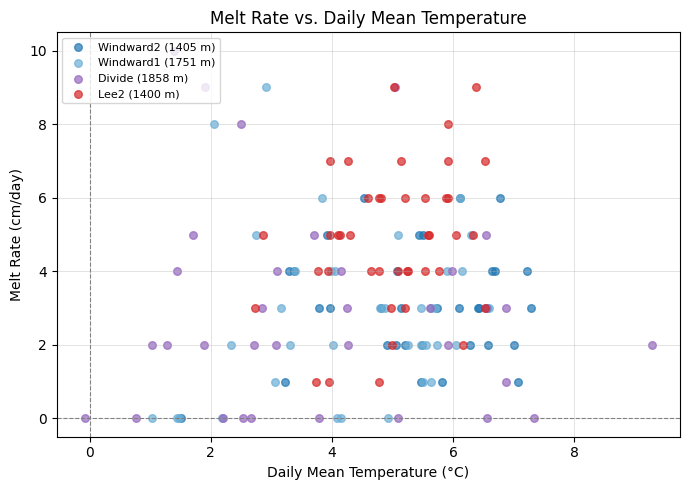

In [251]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee1":      "#e08080",
    "Lee2":      "#d62728",
}

site_labels = {
    "Windward2": "Windward2 (1405 m)",
    "Windward1": "Windward1 (1751 m)",
    "Divide":    "Divide (1858 m)",
    "Lee1":      "Lee1 (1701 m)",
    "Lee2":      "Lee2 (1400 m)",
}

start_date = "2025-06-23"

da_temp = ds["temp_c"].sel(
    height="2m",
    shielding="unshielded",
    sensor_type="pace",
    datetime=slice(start_date, None),
)

da_temp_daily_mean = da_temp.resample(datetime="1D").mean()

fig, ax = plt.subplots(dpi=100, figsize=(7, 5))

for site_id in site_ids:
    color = site_colors[site_id]
    label = site_labels[site_id]

    # ── Daily mean temperature ────────────────────────────────────────────────
    temp_daily = da_temp_daily_mean.sel(site_id=site_id).values
    temp_times = pd.to_datetime(da_temp_daily_mean.datetime.values).normalize()
    temp_series = pd.Series(temp_daily, index=temp_times)

    # ── Daily melt rate (diff_cm) at 21:00 ───────────────────────────────────
    grp = df[(df["site_id"] == site_id.lower()) & (pd.to_datetime(df["datetime"]) >= pd.Timestamp(start_date))].copy()
    grp = grp[pd.to_datetime(grp["datetime"]).dt.hour == 21]
    grp = grp.sort_values("datetime").dropna(subset=["diff_cm"])
    melt_times = pd.to_datetime(grp["datetime"].values).normalize()
    melt_series = pd.Series(grp["diff_cm"].values, index=melt_times)
    melt_series = melt_series[~melt_series.index.duplicated(keep="last")]

    # ── Align ─────────────────────────────────────────────────────────────────
    combined = pd.DataFrame({"temp": temp_series, "melt": melt_series}).dropna()
    if combined.empty:
        print(f"Skipping {site_id} — no overlapping data")
        continue

    ax.scatter(
        combined["temp"],
        combined["melt"],
        color=color,
        label=label,
        s=30,
        alpha=0.7,
    )

ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Daily Mean Temperature (°C)")
ax.set_ylabel("Melt Rate (cm/day)")
ax.set_title("Melt Rate vs. Daily Mean Temperature")
ax.legend(fontsize=8, loc="upper left")
ax.grid(lw=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

In [242]:
print(combined)

                 pdd      melt
2025-06-22  0.000000  0.000000
2025-06-23  0.028701  0.020408
2025-06-24  0.056735  0.066327
2025-06-25  0.081152  0.096939
2025-06-26  0.104498  0.122449
2025-06-27  0.125409  0.142857
2025-06-28  0.143755  0.168367
2025-06-29  0.163648  0.198980
2025-06-30  0.186859  0.229592
2025-07-01  0.209207  0.265306
2025-07-02  0.229907  0.285714
2025-07-03  0.253100  0.321429
2025-07-04  0.278036  0.352041
2025-07-05  0.303334  0.377551
2025-07-06  0.323385  0.413265
2025-07-07  0.342635  0.428571
2025-07-08  0.355875  0.459184
2025-07-09  0.384629  0.484694
2025-07-10  0.398561  0.505102
2025-07-11  0.417632  0.530612
2025-07-12  0.436879  0.551020
2025-07-13  0.461592  0.596939
2025-07-14  0.492580  0.612245
2025-07-15  0.524275  0.632653
2025-07-16  0.551188  0.658163
2025-07-17  0.578326  0.698980
2025-07-18  0.607027  0.729592
2025-07-19  0.635564  0.755102
2025-07-20  0.666274  0.790816
2025-07-21  0.697963  0.801020
2025-07-22  0.727896  0.821429
2025-07-

Skipping Lee1 — no overlapping data


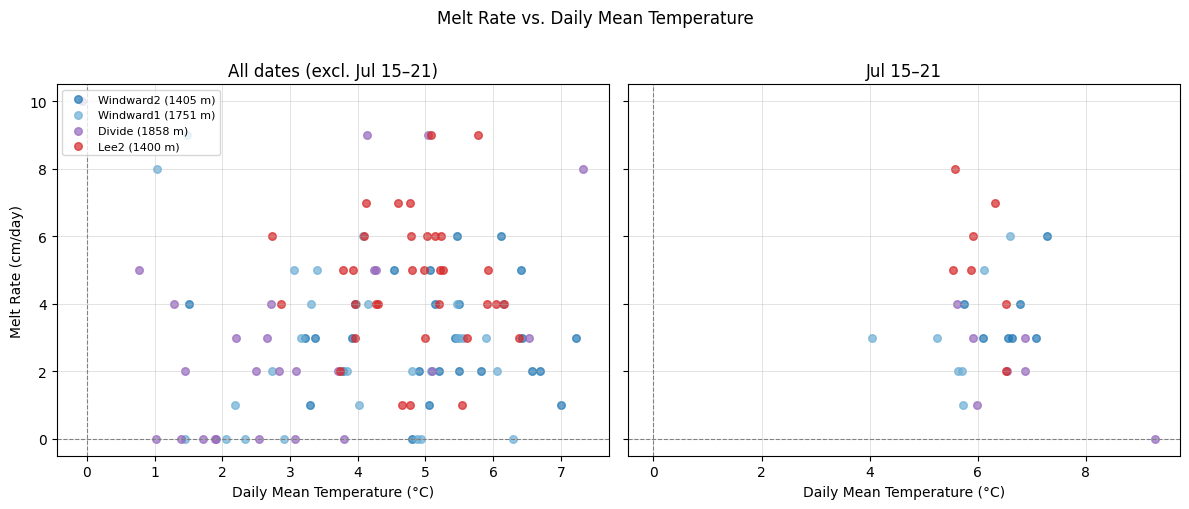

In [252]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee1":      "#e08080",
    "Lee2":      "#d62728",
}

site_labels = {
    "Windward2": "Windward2 (1405 m)",
    "Windward1": "Windward1 (1751 m)",
    "Divide":    "Divide (1858 m)",
    "Lee1":      "Lee1 (1701 m)",
    "Lee2":      "Lee2 (1400 m)",
}

start_date  = "2025-06-23"
inv_start   = pd.Timestamp("2025-07-15")
inv_end     = pd.Timestamp("2025-07-21")

da_temp = ds["temp_c"].sel(
    height="2m",
    shielding="unshielded",
    sensor_type="pace",
    datetime=slice(start_date, None),
)
da_temp_daily_mean = da_temp.resample(datetime="1D").mean()

fig, axes = plt.subplots(1, 2, dpi=100, figsize=(12, 5), sharey=True)
titles = ["All dates (excl. Jul 15–21)", "Jul 15–21"]

for site_id in site_ids:
    color = site_colors[site_id]
    label = site_labels[site_id]

    # ── Daily mean temperature ────────────────────────────────────────────────
    temp_daily = da_temp_daily_mean.sel(site_id=site_id).values
    temp_times = pd.to_datetime(da_temp_daily_mean.datetime.values).normalize()
    temp_series = pd.Series(temp_daily, index=temp_times)

    # ── Daily melt rate at 21:00 ──────────────────────────────────────────────
    grp = df[(df["site_id"] == site_id.lower()) & (pd.to_datetime(df["datetime"]) >= pd.Timestamp(start_date))].copy()
    grp = grp[pd.to_datetime(grp["datetime"]).dt.hour == 21]
    grp = grp.sort_values("datetime").dropna(subset=["diff_cm"])
    melt_times = pd.to_datetime(grp["datetime"].values).normalize() - pd.Timedelta("1D")
    melt_series = pd.Series(grp["diff_cm"].values, index=melt_times)
    melt_series = melt_series[~melt_series.index.duplicated(keep="last")]

    # ── Align ─────────────────────────────────────────────────────────────────
    combined = pd.DataFrame({"temp": temp_series, "melt": melt_series}).dropna()
    if combined.empty:
        print(f"Skipping {site_id} — no overlapping data")
        continue

    mask_inv     = (combined.index >= inv_start) & (combined.index <= inv_end)
    combined_inv = combined[mask_inv]
    combined_std = combined[~mask_inv]

    for ax, subset in zip(axes, [combined_std, combined_inv]):
        if subset.empty:
            continue
        ax.scatter(
            subset["temp"],
            subset["melt"],
            color=color,
            label=label,
            s=30,
            alpha=0.7,
        )

for ax, title in zip(axes, titles):
    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Daily Mean Temperature (°C)")
    ax.set_title(title)
    ax.grid(lw=0.5, alpha=0.5)

axes[0].set_ylabel("Melt Rate (cm/day)")
axes[0].legend(fontsize=8, loc="upper left")

fig.suptitle("Melt Rate vs. Daily Mean Temperature", y=1.01)
plt.tight_layout()
plt.show()

Skipping Lee1 — no overlapping data


/Users/drotto/src/jiflr/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drotto/src/jiflr/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drotto/src/jiflr/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drotto/src/jiflr/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drotto/src/jiflr/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanv

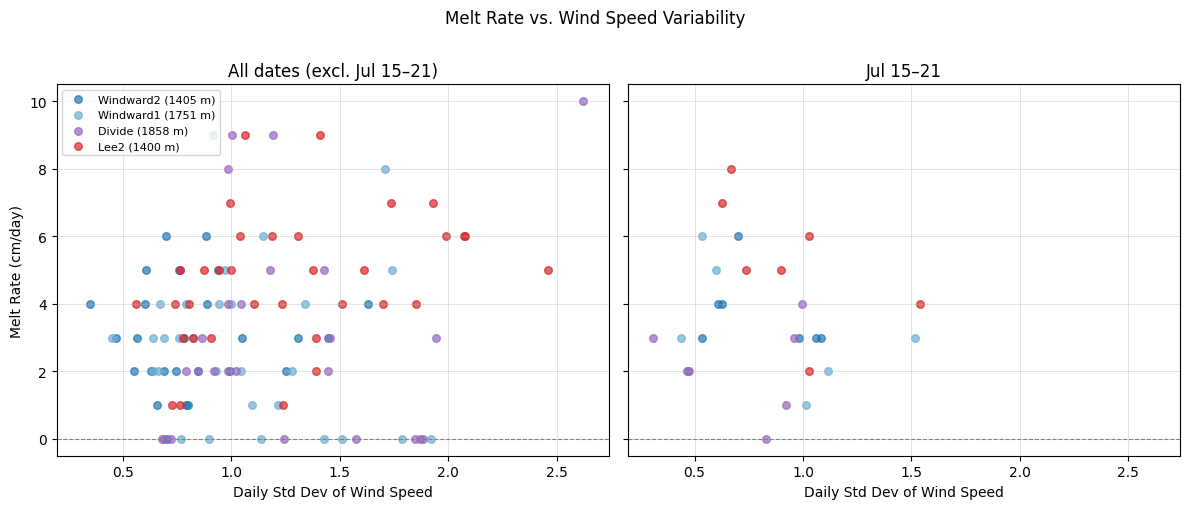

In [255]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee1":      "#e08080",
    "Lee2":      "#d62728",
}

site_labels = {
    "Windward2": "Windward2 (1405 m)",
    "Windward1": "Windward1 (1751 m)",
    "Divide":    "Divide (1858 m)",
    "Lee1":      "Lee1 (1701 m)",
    "Lee2":      "Lee2 (1400 m)",
}

start_date = "2025-06-23"
inv_start  = pd.Timestamp("2025-07-15")
inv_end    = pd.Timestamp("2025-07-21")

da_wind = ds["wind_speed_avg"].sel(
    height="2m",
    shielding="unshielded",
    sensor_type="pace",
    datetime=slice(start_date, None),
)
da_wind_daily_std = da_wind.resample(datetime="1D").std()

fig, axes = plt.subplots(1, 2, dpi=100, figsize=(12, 5), sharey=True, sharex=True)
titles = ["All dates (excl. Jul 15–21)", "Jul 15–21"]

for site_id in site_ids:
    color = site_colors[site_id]
    label = site_labels[site_id]

    # ── Daily wind speed std ──────────────────────────────────────────────────
    wind_std = da_wind_daily_std.sel(site_id=site_id).values
    wind_times = pd.to_datetime(da_wind_daily_std.datetime.values).normalize()
    wind_series = pd.Series(wind_std, index=wind_times)

    # ── Daily melt rate at 21:00 ──────────────────────────────────────────────
    grp = df[(df["site_id"] == site_id.lower()) & (pd.to_datetime(df["datetime"]) >= pd.Timestamp(start_date))].copy()
    grp = grp[pd.to_datetime(grp["datetime"]).dt.hour == 21]
    grp = grp.sort_values("datetime").dropna(subset=["diff_cm"])
    melt_times = pd.to_datetime(grp["datetime"].values).normalize() - pd.Timedelta("1D")
    melt_series = pd.Series(grp["diff_cm"].values, index=melt_times)
    melt_series = melt_series[~melt_series.index.duplicated(keep="last")]

    # ── Align ─────────────────────────────────────────────────────────────────
    combined = pd.DataFrame({"wind_std": wind_series, "melt": melt_series}).dropna()
    if combined.empty:
        print(f"Skipping {site_id} — no overlapping data")
        continue

    mask_inv     = (combined.index >= inv_start) & (combined.index <= inv_end)
    combined_inv = combined[mask_inv]
    combined_std = combined[~mask_inv]

    for ax, subset in zip(axes, [combined_std, combined_inv]):
        if subset.empty:
            continue
        ax.scatter(
            subset["wind_std"],
            subset["melt"],
            color=color,
            label=label,
            s=30,
            alpha=0.7,
        )

for ax, title in zip(axes, titles):
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Daily Std Dev of Wind Speed")
    ax.set_title(title)
    ax.grid(lw=0.5, alpha=0.5)

axes[0].set_ylabel("Melt Rate (cm/day)")
axes[0].legend(fontsize=8, loc="upper left")

fig.suptitle("Melt Rate vs. Wind Speed Variability", y=1.01)
plt.tight_layout()
plt.show()

Skipping Lee1 — no overlapping data


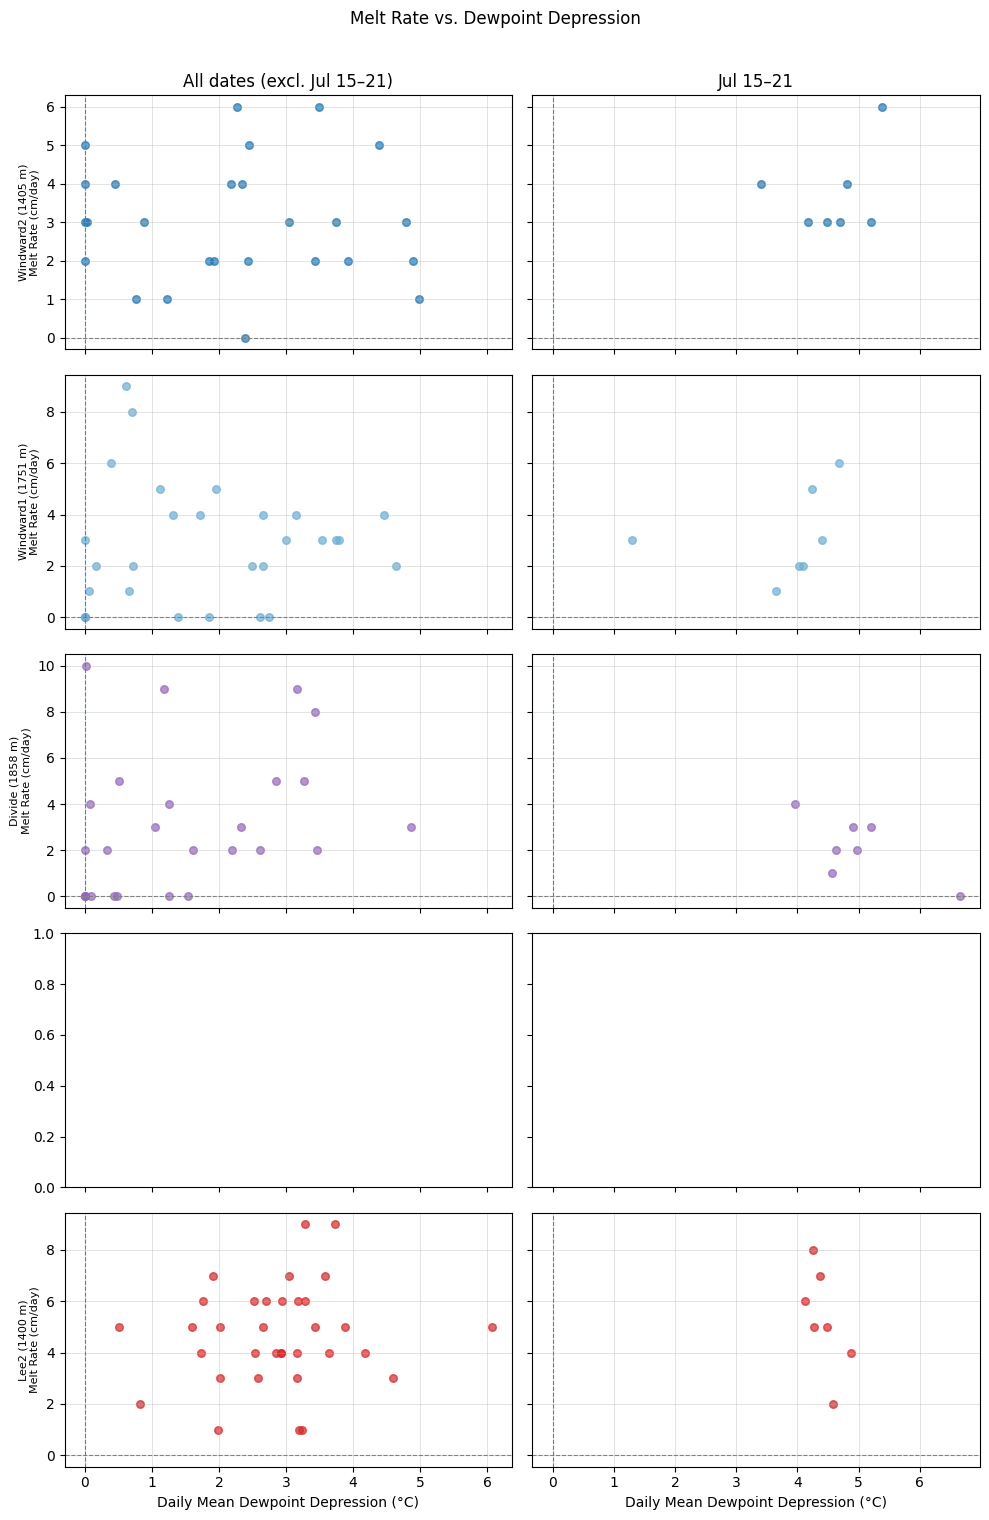

In [259]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import metpy.calc as mpcalc

# ── Dewpoint depression ───────────────────────────────────────────────────────
temp_2m = sel_with_units(ds["temp_c"],            "degC",    height="0.5m", shielding="unshielded", sensor_type="pace")
rh_2m   = sel_with_units(ds["relative_humidity"], "percent", height="2m", shielding="unshielded", sensor_type="pace")

dewpoint_2m = mpcalc.dewpoint_from_relative_humidity(temp_2m, rh_2m)

# Depression = temp - dewpoint (positive = drier air)
depression = temp_2m - dewpoint_2m
depression = depression.sel(datetime=slice(start_date, None))

da_depression_daily = depression.resample(datetime="1D").mean()

# ── Plot ──────────────────────────────────────────────────────────────────────
titles = ["All dates (excl. Jul 15–21)", "Jul 15–21"]

fig, axes = plt.subplots(len(site_ids), 2, dpi=100, figsize=(10, 3 * len(site_ids)), sharey="row", sharex="col")

for row, site_id in enumerate(site_ids):
    color = site_colors[site_id]
    label = site_labels[site_id]

    # ── Daily mean dewpoint depression ───────────────────────────────────────
    dep_vals   = da_depression_daily.sel(site_id=site_id).values
    dep_times  = pd.to_datetime(da_depression_daily.datetime.values).normalize()
    dep_series = pd.Series(dep_vals, index=dep_times)

    # ── Daily melt rate at 21:00 ──────────────────────────────────────────────
    grp = df[(df["site_id"] == site_id.lower()) & (pd.to_datetime(df["datetime"]) >= pd.Timestamp(start_date))].copy()
    grp = grp[pd.to_datetime(grp["datetime"]).dt.hour == 21]
    grp = grp.sort_values("datetime").dropna(subset=["diff_cm"])
    melt_times = pd.to_datetime(grp["datetime"].values).normalize() - pd.Timedelta("1D")
    melt_series = pd.Series(grp["diff_cm"].values, index=melt_times)
    melt_series = melt_series[~melt_series.index.duplicated(keep="last")]

    # ── Align ─────────────────────────────────────────────────────────────────
    combined = pd.DataFrame({"dep": dep_series, "melt": melt_series}).dropna()
    if combined.empty:
        print(f"Skipping {site_id} — no overlapping data")
        continue

    mask_inv     = (combined.index >= inv_start) & (combined.index <= inv_end)
    combined_inv = combined[mask_inv]
    combined_std = combined[~mask_inv]

    for col, subset in enumerate([combined_std, combined_inv]):
        ax = axes[row, col]
        if not subset.empty:
            ax.scatter(subset["dep"], subset["melt"], color=color, s=30, alpha=0.7)
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.axvline(0, color="steelblue", lw=0.8, ls="--")
        ax.grid(lw=0.5, alpha=0.5)
        if row == 0:
            ax.set_title(titles[col])
        if col == 0:
            ax.set_ylabel(f"{label}\nMelt Rate (cm/day)", fontsize=8)

for col in range(2):
    axes[-1, col].set_xlabel("Daily Mean Dewpoint Depression (°C)")

fig.suptitle("Melt Rate vs. Dewpoint Depression", y=1.01)
plt.tight_layout()
plt.show()

Skipping Lee1 — no overlapping data


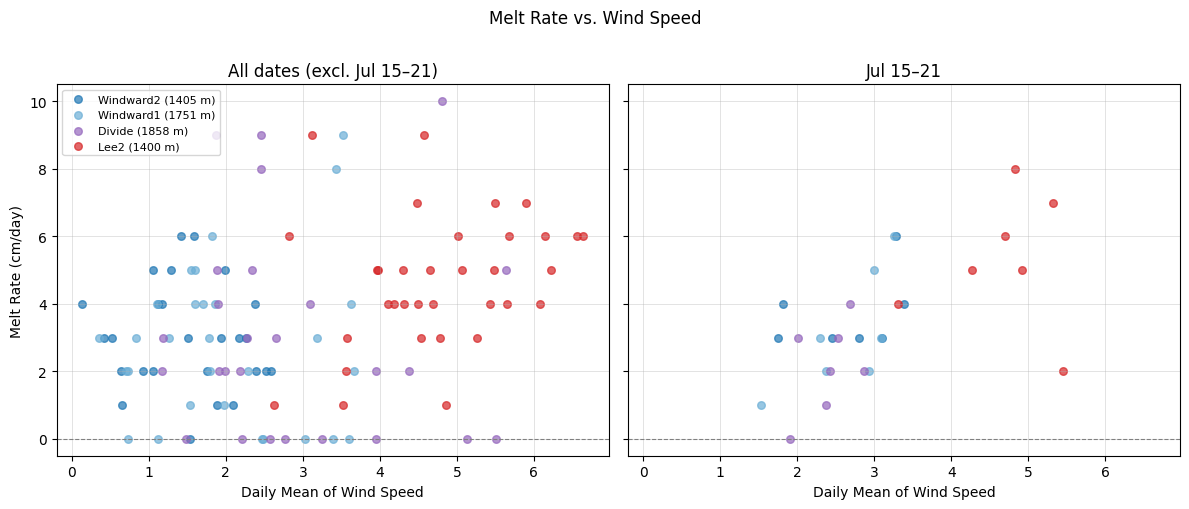

In [262]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
site_ids = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]

site_colors = {
    "Windward2": "#1f77b4",
    "Windward1": "#6baed6",
    "Divide":    "#9467bd",
    "Lee1":      "#e08080",
    "Lee2":      "#d62728",
}

site_labels = {
    "Windward2": "Windward2 (1405 m)",
    "Windward1": "Windward1 (1751 m)",
    "Divide":    "Divide (1858 m)",
    "Lee1":      "Lee1 (1701 m)",
    "Lee2":      "Lee2 (1400 m)",
}

start_date = "2025-06-23"
inv_start  = pd.Timestamp("2025-07-15")
inv_end    = pd.Timestamp("2025-07-21")

da_wind = ds["wind_speed_avg"].sel(
    height="2m",
    shielding="unshielded",
    sensor_type="pace",
    datetime=slice(start_date, None),
)
da_wind_daily_std = da_wind.resample(datetime="1D").mean()

fig, axes = plt.subplots(1, 2, dpi=100, figsize=(12, 5), sharey=True, sharex=True)
titles = ["All dates (excl. Jul 15–21)", "Jul 15–21"]

for site_id in site_ids:
    color = site_colors[site_id]
    label = site_labels[site_id]

    # ── Daily wind speed std ──────────────────────────────────────────────────
    wind_std = da_wind_daily_std.sel(site_id=site_id).values
    wind_times = pd.to_datetime(da_wind_daily_std.datetime.values).normalize()
    wind_series = pd.Series(wind_std, index=wind_times)

    # ── Daily melt rate at 21:00 ──────────────────────────────────────────────
    grp = df[(df["site_id"] == site_id.lower()) & (pd.to_datetime(df["datetime"]) >= pd.Timestamp(start_date))].copy()
    grp = grp[pd.to_datetime(grp["datetime"]).dt.hour == 21]
    grp = grp.sort_values("datetime").dropna(subset=["diff_cm"])
    melt_times = pd.to_datetime(grp["datetime"].values).normalize() - pd.Timedelta("1D")
    melt_series = pd.Series(grp["diff_cm"].values, index=melt_times)
    melt_series = melt_series[~melt_series.index.duplicated(keep="last")]

    # ── Align ─────────────────────────────────────────────────────────────────
    combined = pd.DataFrame({"wind_std": wind_series, "melt": melt_series}).dropna()
    if combined.empty:
        print(f"Skipping {site_id} — no overlapping data")
        continue

    mask_inv     = (combined.index >= inv_start) & (combined.index <= inv_end)
    combined_inv = combined[mask_inv]
    combined_std = combined[~mask_inv]

    for ax, subset in zip(axes, [combined_std, combined_inv]):
        if subset.empty:
            continue
        ax.scatter(
            subset["wind_std"],
            subset["melt"],
            color=color,
            label=label,
            s=30,
            alpha=0.7,
        )

for ax, title in zip(axes, titles):
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Daily Mean of Wind Speed")
    ax.set_title(title)
    ax.grid(lw=0.5, alpha=0.5)

axes[0].set_ylabel("Melt Rate (cm/day)")
axes[0].legend(fontsize=8, loc="upper left")

fig.suptitle("Melt Rate vs. Wind Speed", y=1.01)
plt.tight_layout()
plt.show()